`[БРД051.2] Предсказание вероятности отказа насоса`

Для решения задачи прогнозирования времени работы насосов по их характеристикам можно использовать не только классические методы машинного обучения, но и аппарат анализа выживаемости произвольных объектов, реализованный в библиотеках `lifelines` и `scikit-survival` для языка программирования `Python`.

Данные модели и алгоритмы строят вероятностные модели, позволяющие получать распределение вероятностей выхода технологического оборудования (с заданными технологическими параметрами) из строя в определенный день.

Данную задачу можно решать несколькими подходами:
1. использовать полупараметрические модели (модели, которые на основании второстепенных признаков строят прогнозы, в том числе с учетом образа вида распределения целевого признака);
2. использовать параметрические модели (модели, которые полностью берут за основу вид распределения параметра, отвечающего за продолжительность работы устройства, и на его основе строят прогноз);
3. использовать модели, основанные на алгоритмах машинного обучения.

При этом эмпирические модели (Каплан-Мейер, Нельсон-Аален и модель кумулятивной опасности) не являются прогнозными, поскольку они исключительно позволяют визуализировать текущие исторические наблюдения и строить по ним аналитику.

Для того, чтобы решить поставленную задачу, необходимо обработать данные, а после с их помощью построить соответствующие модели и оценить каждую из них, чтобы отобрать наилучшую -- ту, которая строит вероятностный прогноз наиболее правдоподобно.

`Содержание ноутбука`

**Table of contents**<a id='toc0_'></a>    
- 1. [Раздел 1. Обработка входных данных и датасета](#toc1_)    
  - 1.1. [Research](#toc1_1_)    
    - 1.1.1. [Загрузка исходных данных](#toc1_1_1_)    
    - 1.1.2. [Анализ типов данных и значений признаков](#toc1_1_2_)    
      - 1.1.2.1. [Выделение фрагментов исходного датасета](#toc1_1_2_1_)    
      - 1.1.2.2. [Анализ выделенных фрагментов](#toc1_1_2_2_)    
      - 1.1.2.3. [Удаление строк с большой концентрацией пропусков](#toc1_1_2_3_)    
    - 1.1.3. [Формирование обучающей и тестирующей выборок](#toc1_1_3_)    
    - 1.1.4. [Обработка категориальных признаков](#toc1_1_4_)    
      - 1.1.4.1. [Выделение фрагментов категориальных данных](#toc1_1_4_1_)    
      - 1.1.4.2. [Кодирование категориальных данных](#toc1_1_4_2_)    
    - 1.1.5. [Обработка вещественных признаков](#toc1_1_5_)    
      - 1.1.5.1. [Выделение вещественного датасета](#toc1_1_5_1_)    
      - 1.1.5.2. [Заполнение пропущенных значений в датасете](#toc1_1_5_2_)    
        - 1.1.5.2.1. [Первичный анализ пропущенных значений](#toc1_1_5_2_1_)    
        - 1.1.5.2.2. [Заполнение пропущенных значений методом MICE](#toc1_1_5_2_2_)    
        - 1.1.5.2.3. [Заполнение пропущенных значений методом анализа распределений](#toc1_1_5_2_3_)    
    - 1.1.6. [Формирование предобработанного датасета](#toc1_1_6_)    
  - 1.2. [Production](#toc1_2_)    
  - 1.3. [`Выводы по разделу`](#toc1_3_)    
- 2. [Раздел 2. Генерация признаков](#toc2_)    
  - 2.1. [Research](#toc2_1_)    
    - 2.1.1. [Генерация сводной статистической таблицы численного датасета](#toc2_1_1_)    
    - 2.1.2. [Применение скалирования к вещественным признакам](#toc2_1_2_)    
      - 2.1.2.1. [Применение стандартизации к вещественным признакам](#toc2_1_2_1_)    
      - 2.1.2.2. [Применение MinMax-преобразования к вещественным признакам](#toc2_1_2_2_)    
    - 2.1.3. [Проверка наличия мультиколлинеарности в данных](#toc2_1_3_)    
    - 2.1.4. [Генерация нового признакового пространства](#toc2_1_4_)    
      - 2.1.4.1. [Понижение пространства для исходных данных](#toc2_1_4_1_)    
      - 2.1.4.2. [Понижение пространства для стандартизированных данных](#toc2_1_4_2_)    
      - 2.1.4.3. [Понижение пространства для данных после MinMax-преобразования](#toc2_1_4_3_)    
    - 2.1.5. [Отбор признаков при помощи устранения мультиколлинеарности](#toc2_1_5_)    
  - 2.2. [Production](#toc2_2_)    
  - 2.3. [`Выводы по разделу`](#toc2_3_)    
- 3. [Раздел 3. Обучение ML-моделей](#toc3_)    
  - 3.1. [Research](#toc3_1_)    
    - 3.1.1. [Построение параметрических моделей](#toc3_1_1_)    
      - 3.1.1.1. [Формирование вариационного ряда](#toc3_1_1_1_)    
      - 3.1.1.2. [Проверка ряда на экспоненциальное распределение](#toc3_1_1_2_)    
      - 3.1.1.3. [Проверка ряда на распределение Вейбулла](#toc3_1_1_3_)    
  - 3.2. [Production](#toc3_2_)    
    - 3.2.1. [Модель пропорциональной опасности Кокса](#toc3_2_1_)    
    - 3.2.2. [Аддитивная модель Аалена](#toc3_2_2_)    
    - 3.2.3. [Модели ML для решения задачи анализа выживаемости](#toc3_2_3_)    
  - 3.3. [`Выводы по разделу`](#toc3_3_)    
- 4. [Раздел 4. Кросс-валидация и подбор гиперпараметров](#toc4_)    
  - 4.1. [Production](#toc4_1_)    
    - 4.1.1. [Обучение статистических моделей на данных после PCA](#toc4_1_1_)    
      - 4.1.1.1. [Обучение модели Кокса](#toc4_1_1_1_)    
        - 4.1.1.1.1. [Обучение на классическом датасете](#toc4_1_1_1_1_)    
        - 4.1.1.1.2. [Обучение на стандартизированном датасете](#toc4_1_1_1_2_)    
        - 4.1.1.1.3. [Обучение на датасете с MinMax-преобразованием](#toc4_1_1_1_3_)    
      - 4.1.1.2. [Обучение аддитивной модели Аалена](#toc4_1_1_2_)    
        - 4.1.1.2.1. [Обучение на классическом датасете](#toc4_1_1_2_1_)    
        - 4.1.1.2.2. [Обучение на стандартизированном датасете](#toc4_1_1_2_2_)    
        - 4.1.1.2.3. [Обучение на датасете с MinMax-преобразованием](#toc4_1_1_2_3_)    
    - 4.1.2. [Обучение статистических моделей на данных после ручного отбора признаков](#toc4_1_2_)    
      - 4.1.2.1. [Обучение модели Кокса](#toc4_1_2_1_)    
        - 4.1.2.1.1. [Обучение на классическом датасете](#toc4_1_2_1_1_)    
        - 4.1.2.1.2. [Обучение на стандартизированном датасете](#toc4_1_2_1_2_)    
        - 4.1.2.1.3. [Обучение на датасете с MinMax-преобразованием](#toc4_1_2_1_3_)    
      - 4.1.2.2. [Обучение аддитивной модели Аалена](#toc4_1_2_2_)    
        - 4.1.2.2.1. [Обучение на классическом датасете](#toc4_1_2_2_1_)    
        - 4.1.2.2.2. [Обучение на стандартизированном датасете](#toc4_1_2_2_2_)    
        - 4.1.2.2.3. [Обучение на датасете с MinMax-преобразованием](#toc4_1_2_2_3_)    
    - 4.1.3. [Исследование лучшей статистической модели](#toc4_1_3_)    
      - 4.1.3.1. [Исследование модели, обученной на данных PCA](#toc4_1_3_1_)    
      - 4.1.3.2. [Исследование моделей, обученных на исходных даннах](#toc4_1_3_2_)    
        - 4.1.3.2.1. [Метод отбрасывания нарушающих условие признаков](#toc4_1_3_2_1_)    
        - 4.1.3.2.2. [Метод генерации сплайн-признаков для столбцов, нарушающих предположение](#toc4_1_3_2_2_)    
        - 4.1.3.2.3. [Метод отбрасывания категориальных признаков](#toc4_1_3_2_3_)    
    - 4.1.4. [Обучение ML-моделей выживаемости](#toc4_1_4_)    
      - 4.1.4.1. [Обучение на данных после PCA](#toc4_1_4_1_)    
        - 4.1.4.1.1. [Обучение на классическом датасете](#toc4_1_4_1_1_)    
        - 4.1.4.1.2. [Обучение на стандартизированном датасете](#toc4_1_4_1_2_)    
        - 4.1.4.1.3. [Обучение на датасете с MinMax-преобразованием](#toc4_1_4_1_3_)    
      - 4.1.4.2. [Обучение на данных после ручного отбора признаков и кодирования категориальных](#toc4_1_4_2_)    
        - 4.1.4.2.1. [Обучение на классическом датасете](#toc4_1_4_2_1_)    
        - 4.1.4.2.2. [Обучение на стандартизированном датасете](#toc4_1_4_2_2_)    
        - 4.1.4.2.3. [Обучение на датасете с MinMax-преобразованием](#toc4_1_4_2_3_)    
  - 4.2. [`Выводы по разделу`](#toc4_2_)    
- 5. [Раздел 5. Предсказание на новых данных](#toc5_)    
  - 5.1. [Production](#toc5_1_)    
    - 5.1.1. [Вычисление метрики IBS](#toc5_1_1_)    
    - 5.1.2. [Вычисление метрики AUC(t)](#toc5_1_2_)    
  - 5.2. [`Выводы по разделу`](#toc5_2_)    
- 6. [`Выводы по исследованию`](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

`Структура ноутбука`

Каждый раздел состоит из двух частей:
 - `research (необязательная)` — включает в себя вспомогательные исследования, тесты, визуализации, диаграммы и аналитические выкладки, используемые в процессе работы;
 - `production (обязательная)` — содержит финальный, чистый и воспроизводимый код, который используется для запуска и проверки.

При этом:
1. research-часть не обязательна и может отсутствовать в некоторых разделах;
2. production-часть не содержит закомментированный код и ветки решений, которые не используются в ходе решения;
3. код в Production-части должен быть оформлен с принципами воспроизводимости и чистоты, избежания лишних промежуточных вычислений и отладочных выводов, и **он будет использоваться для переноса в PY-файлы в будущем**.


`Работа в рамках устранения замечаний по валидации`

Данная работа проходит повторную валидацию. В отчете были выявлены следующие проблемы:

| TODO                                                                                                                                   | Приоритет        | Комментарий                                                                                                                                                                                                                                                                                                                                             |
| -------------------------------------------------------------------------------------------------------------------------------------- | ---------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| В столбце "Мероприятия остановок" потенциально можно объеденить разные названия                                                        | Важность низкая  | Для примера в списке уникальных мероприятий 32 с типом содержащем "Исследования"                                                                                                                                                                                                                                                                        |
| Лучше для test отобрать чуть больше значений (хотя бы 5% от выборки)                                                                   | Важность низкая  |                                                                                                                                                                                                                                                                                                                                                         |
| По описанию "Признак отказа - Булевый признак, указывающий, был ли насос выведен из работы из-за поломки"                              | Важность высокая | Точно ли living_id имеет Признак отказа = 1, а death_id имеет Признак отказа = 0, а не наоборот?                                                                                                                                                                                                                                                        |
| При использовании медианы качество будет лучше                                                                                         | Важность средняя | Лучше выводить графики (до того как заполнять и смотреть распределения) и смотреть глазами                                                                                                                                                                                                                                                              |
| При использовании скользящего окна (усредненее 2 значений до, 2 значений после искомого) может быть еще лучше                          | Важность средняя |                                                                                                                                                                                                                                                                                                                                                         |
| (Для оптимизации) для заполнения пропусков можно использовать MICE, он позволяет перебирать модели для заполнения                      | Важность низкая  |                                                                                                                                                                                                                                                                                                                                                         |
| Надо сделать финальную проверку модели Кокса                                                                                           | Важность высокая | Проверка пропорциональности рисков + Анализа остатков модели                                                                                                                                                                                                                                                                                            |
| Из отчета ниже видно, что модель имеет нарушения предположения пропорциональности рисков для нескольких переменных                     | Важность высокая | Влияние этих переменных на риск изменяется со временем, что требует корректировки модели<br>Например, для категориальных переменных (Группа по кол-ву циклов ПКВ, year) можно использовать strata в fit()<br>Для непрерывных переменных (Pзаб, Минуты вращения насоса) можно использовать логарифмические преобразования (необходимо подробнее изучить) |
| Также из отчета ниже proportional_hazard_test можное увидеть несоблюдение пропорциональности рисков (по тем же переменным, что и выше) | Важность высокая |                                                                                                                                                                                                                                                                                                                                                         |
| Также необходимо провести анализа остатков модели                                                                                      | Важность высокая |                                                                                                                                                                                                                                                                                                                                                         |

В результате мероприятий по устранению замечаний были выполнены следующие действия:
1. с заказчиком был проработан вопрос семантики признаков для того, чтобы установить, требуется ли кодировать "Мероприятия остановок";
2. был собран новый датасет, который включает как объекты, вышедшие из строя, так и те, что еще работают по сей день, с целью увеличения обучающей выборки и формирования тестовой для проверки метрик качества;
3. была исправлена ошибка, в результате которой значения "Признака отказа" были перепутаны;
4. при заполнении пропусков была исследована медиана при помощи анализа распределений и KL-дивергенции;
5. приведена аргументация, почему применение методов скользящего окна и алгоритма MICE для заполнения пропусков не подходит для данной задачи;
6. была выполнена итоговая проверка модели Кокса, в результате которой было принято решение использовать методы машинного обучения для построения моделей выживаемости, поскольку важные статистические свойства, такие как пропорциональность рисков, не выполняются на исходном датасете, а метрики качества на преобразованных данных сильно хуже (соответственно, был добавлен новый раздел с построением ML-моделей выживаемости и вычисления метрик качества).

`Формирование окружения для работы`

Первоначально необходимо подготовить окружение для работы с данными и их моделирования. Чтобы не возникало конфликтов виртуальной среды Python, зафиксируем используемые в ходе исследования версии основных библиотек и фреймворков, которые будут использоваться далее. А также пропишем последовательность команд для формирования среды.

Работа справедлива для версии `Python3.9+` (выполнялась на платформе N1).

Первоначально установим необходимые библиотеки при помощи пакетного менеджера `pip` в виртуальное окружение.

Также зафиксируем версии библиотек далее.

Данные библиотеки можно установить, поместив их вместе с версиями в файл `requirements.txt`. И выполнимв команду ниже.

In [1]:
!pip install --upgrade --force-reinstall -r requirements.txt

  Using cached category_encoders-2.6.4-py2.py3-none-any.whl (82 kB)
  Using cached ipykernel-6.29.5-py3-none-any.whl (117 kB)
  Using cached lifelines-0.30.0-py3-none-any.whl (349 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl (7.8 MB)
  Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
  Using cached numpy-1.26.3-cp39-cp39-win_amd64.whl (15.8 MB)
  Using cached pandas-2.2.0-cp39-cp39-win_amd64.whl (11.6 MB)
  Using cached scikit_learn-1.4.0-1-cp39-cp39-win_amd64.whl (10.6 MB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl (46.2 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)
  Using cached statsmodels-0.14.5-cp39-cp39-win_amd64.whl (9.7 MB)
  Using cached comm-0.2.3-py3-none-any.whl (7.3 kB)
  Using cached debugpy-1.8.16-cp39-cp39-win_amd64.whl (5.3 MB)
  Using cached pyzmq-27.1.0-cp39-cp

ERROR: Could not install packages due to an OSError: [WinError 5] Отказано в доступе: 'C:\\Users\\bugae\\Desktop\\code\\gpn\\BRD 51.2\\venv\\Lib\\site-packages\\~%rnado\\speedups.pyd'
Check the permissions.

You should consider upgrading via the 'C:\Users\bugae\Desktop\code\gpn\BRD 51.2\venv\Scripts\python.exe -m pip install --upgrade pip' command.


Средствами Python импортируем необходимые для работы библиотеки. В силу традиции, присвоим некоторым модулям псевдонимы (например, pd для pandas и т.д.). Роль импортируемых библиотек и фреймворков представлена в таблице. 

| Наименование библиотеки | Описание                                                                             |
| ----------------------- | ------------------------------------------------------------------------------------ |
| matplotlib              | Библиотека для визуализации данных                                                   |
| pandas                  | Библиотека для работы таблицами и плоскими данными                                   |
| numpy                   | Библиотека для работы с массивами и матрицами                                        |
| scikit-learn            | Библиотека для построения классических моделей машинного обучения и работы с данными |
| scipy                   | Библиотека для работы со статистическими объектами                                   |
| missingno               | Библиотека для визуализации пропусков в данных                                       |
| seaborn                 | Библиотека для визуализации данных                                                   |
| lifelines               | Библиотека для обучения и построения статистических моделей выживаемости             |
| category_encoders       | Библиотека для кодирования категориальных признаков в вещественные значения          |
| typing                  | Библиотека для типизации парамеров функций и переменных                              |
| warnings                | Библиотека для корректировки выводов предупреждений                                  |
| scikit-survival         | Библиотека для построения моделей выживаемости, основанных на методах ML             |


In [1]:
import pandas as pd
import numpy as np
import typing as t

C:\Users\bugae\AppData\Local\Temp\ipykernel_2700\2264238624.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings('ignore')

Для воспроизводимости результатов исследования зафиксируем основание генератора случайных чисел, который используется для деления выборки на обучение и тест, а также при обучении моделей.

In [4]:
seed = 5
np.random.seed(seed)

# 1. <a id='toc1_'></a>[Раздел 1. Обработка входных данных и датасета](#toc0_)

Исходный набор данных представляет из себя набор технологических параметров добывающего оборудования, полученный путем агрегации исторических наблюдений, в котором необходимо предсказать  распределение вероятностей выхода из строя по дням для данного объекта.

| **№** | **Признак** | **Описание** | **Тип данных признака** |
|---|---|---|---|
| **1** | Скважина | Уникальный номер скважины | Категориальный |
| **2** | Сборка | Наименование технологической сборки | Категориальный |
| **3** | Эра.Дата монтажа | Дата (ДД.ММ.ГГГГ), когда был произведен монтаж насоса | Агрегат данных (дата) |
| **4** | Дней в работе | Количествово дней, сколько насос проработал до демонтажа | Целочисленный |
| **5** | Кол-во циклов ПКВ | Количество циклов ПКВ, которые были осущетслены за время работы оборудования | Целочисленный |
| **6** | Кол-во циклов ПКВ/Дней в работе | Среднее количество циклов ПКВ в 1 день | Вещественный |
| **7** | sborka_id | Уникальный номер технологической сборки | Категориальный |
| **8** | well_id | Сцепка идентификатора скважины и даты | Категориальный |
| **9** | Причины остановок новые | Мероприятие остановки по УСОИ за время работы насоса | Категориальный |
| **10** | Bн [м3/м3] ТР | Удельный расход электроэнергии на одну тонну добытой жидкости | Вещественный |
| **11** | Признак отказа | Булевый признак, указывающий, был ли насос выведен из работы из-за поломки | Логический (0 или 1) |
| **12** | Режим гр-ка | Режимы работы скважины за время работы насоса | Категориальный |
| **13** | Группа | Наиболее частый режим работы скважины за время работы насоса | Категориальный |
| **14** | Группа ПКВ | Наиболее частый режим работы скважины ПКВ | Категориальный |
| **15** | УРЭ [кВтч/т] | Удельный расход электроэнергии на одну тонну добытой жидкости | Вещественный |
| **16** | УРЭ К [кВтч/т] | Удельный расход электроэнергии на одну тонну добытой жидкости с контроллера станции управления | Вещественный |
| **17** | Э/э (Wакт) [кВт*ч] | Электроэнергия расчетная от максимальной за сутки активной мощности | Вещественный |
| **18** | Э/э реакт. (ТМ) | Реактивная электроэнергия со счетчика станции управления | Вещественный |
| **19** | Э/э счет. (ТМ) [Вт] | Активная электроэнергия со счетчика станции управления | Вещественный |
| **21** | Номинальный дебит сборки [м3/сут] | Номинальный дебит сборки за время работы | Вещественный |
| **22** | Номинальный напор сборки [м] | Номинальный напор сборки за время работы | Вещественный |
| **23** | Номинальная мощность сборки [кВт] | Номинальная мощность сборки за время работы | Вещественный |
| **24** | Тип ствола | Код типа ствола (справочник OIS) | Категориальный |
| **25** | Qж OIS протяжка медиана [м3/сут] | Медианный дебит жидкости, подтвержденный в ОИС и протянутый на каждый день в работе | Вещественный |
| **26** | Qж OIS протяжка среднее [м3/сут] | Средний дебит жидкости, подтвержденный в ОИС и протянутый на каждый день в работе | Вещественный |
| **27** | Qж OIS протяжка ст. откл-е [м3/сут] | Среднеквадратическое отклонение дебита жидкости, подтвержденное в ОИС и протянутое на каждый день в работе | Вещественный |
| **28** | Qн OIS протяжка медиана [тн/сут] | Медианный дебит жидкости, подтвержденный в ОИС и протянутый на каждый день в работе | Вещественный |
| **29** | Qн OIS протяжка среднее [тн/сут] | Средний дебит жидкости, подтвержденный в ОИС и протянутый на каждый день в работе | Вещественный |
| **30** | Qн OIS протяжка ст. откл-е [тн/сут] | Среднеквадратическое отклонение дебита жидкости, подтвержденное в ОИС и протянутое на каждый день в работе | Вещественный |
| **31** | Обв-ть V OIS протяжка медиана [%] | Медианная обводненность, подтвержденная в ОИС и протянутая на каждый день в работе | Вещественный |
| **32** | Обв-ть V OIS протяжка среднее [%] | Средняя обводненность, подтвержденная в ОИС и протянутая на каждый день в работе | Вещественный |
| **33** | Обв-ть V OIS протяжка ст. откл-е [%] | Среднеквадратическое отклонение обводненности, подтвержденное в ОИС и протянутое на каждый день в работе | Вещественный |
| **34** | Pзаб медиана [ат] | Медианное забойное давление | Вещественный |
| **35** | Pзаб среднее [ат] | Среднее забойное давление | Вещественный |
| **36** | Pзаб ст. откл-е [ат] | Среднеквадратическое отклонение забойного давления | Вещественный |
| **37** | Pпл медиана [ат] | Медианное значение пластового давления | Вещественный |
| **38** | Pпласт среднее [ат] | Среднее значение пластового давления | Вещественный |
| **39** | Pпласт ст. откл-е [ат] | Среднеквадратическое отклонение пластового давления | Вещественный |
| **40** | Глубина насоса [м] | Глубина насоса в матрах | Вещественный |
| **41** | Дата начала экспл-ии | Дата (ДД.ММ.ГГГГ) начала эксплуатации насоса | Агрегат данных (дата) |
| **42** | Кол-во пластов | Количество эксплуатируемых пластов | Целочисленный |
| **43** | Hдин медиана [м] | Динамический уровень жидкости в скважине медиана | Вещественный |
| **44** | Hдин среднее [м] | Динамический уровень жидкости в скважине среднее | Вещественный |
| **45** | Hдин ст. откл-е [м] | Динамический уровень жидкости в скважине ст. откл-е | Вещественный |
| **46** | Mн [сПз] ТР | ? | Вещественный |
| **47** | Pбуф медиана [атм] | Буферное давление медиана | Вещественный |
| **48** | Pбуф среднее [атм] | Буферное давление среднее | Вещественный |
| **49** | Pбуф ст. откл-е [атм] | Буферное давление ст. откл-е | Вещественный |
| **50** | Pлин медиана [атм] | Давление после штуцера медиана | Вещественный |
| **51** | Pлин среднее [атм] | Давление после штуцера среднее  | Вещественный |
| **52** | Pлин ст. откл-е [атм] | Давление после штуцера ст. откл-е | Вещественный  |
| **53** | Pнас-я [ат] ТР | Давление насыщения | Вещественный |
| **54** | Tпл [град Ц] ТР |Пластовая температура | Вещественный |
| **55** | pв [г/см3] ТР | Давление вытеснения | Вещественный |
| **56** | Каталог ЭЦН. Производитель | Уникальный номер производителя по перчню ЭЦН | Категориальный |
| **57** | Диаметр ЭЦН [мм] | Значение диаметра ЭЦН | Вещественный |
| **58** | Fитог среднее [Гц] | Итоговая частота вращения среднее | Вещественный |
| **59** | Fитог ст. откл-е [Гц] | Итоговая частота вращения ст. откл-е | Вещественный |
| **60** | Fитог медиана [Гц] | Итоговая частота вращения медиана | Вещественный |
| **61** | pн [г/см3] ТР | Кислотность | Вещественный |
| **62** | Гф [м3/тн] МЭР |Газовый фактор | Вещественный |
| **63** | Минуты вращения насоса | Число минут вращения настса | Целочисленный |
| **64** | Сутки вращения насоса | Число суток вращения насоса | Целочисленный |
| **65** | Типоразмер ЭЦН | Габариты электроприводного центробежного насоса | Категориальный |
| **66** | Энергоэффективность ЭЦН |Энергоэффективность электроприводного центробежного насоса | Категориальный |
| **67** | dL динамика [м] ТР | Значение удлинения ствола динамика в метрах | Вещественный |
| **68** | L насос [м] ТР | Значение длины нососа в матрах | Вещественный |
| **69** | dL насос [м] ТР | Значение удлинения ствола насоса в метрах | Вещественный |
| **70** | H насос [м] ТР | Значение напора насоса | Вещественный |
| **71** | L вдп [м] ТР | Значение длина системы волоподачи в метрах | Вещественный |
| **72** | dL вдп [м] ТР | Значение удлинения ствола системы водоподачи в метрах | Вещественный |
| **73** | H вдп [м] ТР | Значение напора системы водоподачи | Вещественный |
| **74** | dH вдп-насос [м] ТР | Значение расширения напора насоса системы водоподачи | Вещественный |
| **75** | dL вдп-насос ТР | Значение удлинения ствола насоса системы водоподачи | Вещественный |
| **76** | D колонны внутренний [мм] ТР | Диаметр внутренней колонны в милиметрах | Вещественный |
| **77** | D нкт внутренний [мм] ТР | Диаметр внутренней насосно-компрессорной трубы в милиметрах | Вещественный |
| **78** | L нкт [м] НКТ | Длина насосно-компрессорной трубы в милиметрах | Вещественный |
| **79** | D нкт внешний min [мм] НКТ | Минимальный диаметр внешней насосно-компрессорной трубы в милиметрах | Вещественный |
| **80** | D нкт внутренний min [мм] НКТ | Минимальный диаметр внутренней насосно-компрессорной трубы в милиметрах | Вещественный |
| **81** | Qж мгн медиана [м3/сут] | Мгновенный медианный дебит нефти | Вещественный |
| **82** | Qж мгн среднее [м3/сут] | Мгновенный средний дебит нефти | Вещественный |
| **83** | Qж мгн ст. откл-е [м3/сут] | Мгновенное среднеквадратическое отклонение дебита нефти | Вещественный |
| **84** | К подачи на устье по среднему | Среднее количество вещества, подаваемого на устье установки | Вещественный |
| **85** | Эра.Дата демонтажа | Дата (ДД.ММ.ГГГГ), когда был произведен демонтаж насоса | Агрегат данных (дата) |
| **86** | Дата первой работы сборки | Дата (ДД.ММ.ГГГГ), когда было начало работы сборки | Агрегат данных (дата) |
| **87** | Дней между монтажом и демонтажем | Сколько дней прошло между датой монтажа и демонтажа  | Целочисленный |   
| **88** | Загрузка ПЭД медиана [%] | отношение рабочего тока к номинальному медиана | Вещественный |
| **89** | Загрузка ПЭД среднее [%] | отношение рабочего тока к номинальному среднее | Вещественный |
| **90** | Загрузка ПЭД ст. откл-е [%] | отношение рабочего тока к номинальному ст. откл-е| Вещественный |
| **91** | Ток фазы A медиана [%] | процент тока в фазе А(?) медиана| Вещественный |
| **92** | Ток фазы A среднее [%] | процент тока в фазе А(?) среднее| Вещественный |
| **93** | Ток фазы A ст. откл-е [%] | процент тока в фазе А(?) ст. откл-е | Вещественный |
| **94** | key_well_id | Сцепка идентификатора скважины и даты | Категориальный |

Целевым значением выступают 2 признака:
1. "Дней в работе" (число дней, которое оборудование с данными параметрами проработало до выхода из исследования);
2. "Признак отказа" (бинарная метка выхода из исследования: если значение равняется 1, значит, оборудование с данными характеристиками действительно вышло из строя в момент времени "Дней в работе", иначе -- оборудование к указанному дню либо продолжило работать, либо наблюдение за ним прекратилось по тем или иным причинам).

## 1.1. <a id='toc1_1_'></a>[Research](#toc0_)

### 1.1.1. <a id='toc1_1_1_'></a>[Загрузка исходных данных](#toc0_)

Благодаря сформированному виртуальному окружению можно приступить к загрузке данных.

Данные представлены в формате .csv: это значит, что нам необходимо воспользоваться средствами библиотеки pandas, чтобы прочитать, распарсить и проанализировать полученный объект.
Воспользуемся методом ```pd.read_csv()``` для того, чтобы прочитать файл с данными и представить его в памяти.

Данный метод принимает на вход:
1. путь до файла, который необходимо прочитать;
2. разделитель (символ, который отделяет разные записи друг от друга);
3. кодировка (кодировка символов в файле);
4. и т.д.
Прочитаем файл при помощи метода и результат положим в переменную df, с которой будем в дальнейшем работать.

В данном случае параметры разделителя и кодировки передавать нет необходимости, так как для данного файла они совпадают с параметрами по умолчанию: запятая и UTF-8 соответственно.
Метод вернет объект датафрейма (абстракция над табличными данными и табличными представлениями, предоставляющая возможность реализовывать логику по работе с плоскими данными), который необходимо отобразить после прочтения файла.
Также в качестве параметров укажем наименования признаков, которые необходимо представить в формате даты. Для этого в параметр parse_dates передадим список наименований колонок с датами, а также поставим флаг ```dayfirst=True``` для корректного представления.
Сам датасет представляет из себя набор объектов, каждый из которых является комбинацией технологических параметров работы добывающего насосного оборудования, а также параметров работы данного оборудования. Данные параметры составляют матрицу объект-признак.

В переменную `df_dead` поместим информацию об объектах, которые были демонтированы. Если у объекта из данного датасета признак отказа равен 0, значит, этот объект был демонтирован по причине, отличающейся от выхода из строя (такие объекты нас не интересуют, потому они помечаются нулем).

В переменную `df_live` поместим информацию об объектах, которые продолжают работу (не были демонтированы). Если у объекта из данного датасета признак отказа равен 1, значит, этот объект вышел из строя, однако не был демонтирован (такие объекты нас интересуют, потому они помечаются единицей).

In [5]:
df_dead = pd.read_excel('./output_ds_3_dead.xlsx', parse_dates=[
    'ЭРА.Дата монтажа', 'ЭРА.Дата демонтажа', 'Дата первой работы сборки', 'Дата начала экспл-ии'])
df_live = pd.read_excel('./output_ds_3_live.xlsx', parse_dates=[
    'ЭРА.Дата монтажа', 'ЭРА.Дата демонтажа', 'Дата первой работы сборки', 'Дата начала экспл-ии'])

Поскольку в датасетах данные однородны, их можно объединить, чтобы работать с данными как с одним целым.

In [7]:
df = pd.concat((df_dead, df_live), ignore_index=True)
df

,key_well_sborka,well_id,sborka_id,Скважина,Сборка,Причины остановок новые,Признак отказа,ЭРА.Дата монтажа,ЭРА.Дата демонтажа,Дней между монтажом и демонтажем,...,dL насос [м] ТР,H насос [м] ТР,dH вдп-насос [м] ТР,dL вдп-насос ТР,D колонны внутренний [мм] ТР,D нкт внешний min [мм] НКТ,D нкт внутренний min [мм] НКТ,Lнкт [м] НКТ,Тип ствола,Дата начала экспл-ии
0,2380001100_2855633938001,2380001100,2855633938001,11,ВНН2А-80Э-2850,Падение сопротивления изоляции установки элект...,1,2023-11-24,2024-05-10,168.0,...,177.73,2366.50,62.68,99.55,130.6,60.0,50.0,2520.00,Вертикальный,2007-02-24
1,2380003708_1917763873901,2380003708,1917763873901,37Р,ВНН5-60Э-2350,Падение сопротивления изоляции установки элект...,1,2020-01-08,2022-03-11,793.0,...,1.03,2489.26,109.97,110.00,132.0,60.0,50.0,2449.71,Вертикальный,2010-01-31
2,2380004008_2275884987101,2380004008,2275884987101,40Р,ВНН5-80-2800,Комплексная обработка призабойной зоны_2021-09-16,0,2020-08-06,2021-09-16,406.0,...,0.00,2547.96,52.00,52.00,130.6,73.0,62.0,2504.48,Вертикальный,2009-04-21
3,2380004008_2610164510401,2380004008,2610164510401,40Р,ВНН5-80-2800,Смена установки электроцентробежного насоса_20...,0,2021-09-23,2023-06-16,631.0,...,0.00,2518.51,63.49,63.49,130.6,73.0,62.0,2501.21,Вертикальный,2009-04-21
4,2380004008_2839514836601,2380004008,2839514836601,40Р,МТ5А-80-2850,Отсутствие подачи_2023-08-05,1,2023-06-17,2023-08-10,54.0,...,0.00,2518.34,63.66,63.66,130.6,73.0,62.0,2497.92,Вертикальный,2009-04-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,2388500400_2843620690001,2388500400,2843620690001,85004,ЭЦНД5А-100М-2700,Исследования на скважине (без обнуления МРП)_2...,0,2023-07-24,2099-01-01,NaN,...,758.26,2499.66,121.57,125.65,146.8,73.0,62.0,3237.51,Наклонно-направленный,2023-02-03
7078,2388500721_2926519442101,2388500721,2926519442101,85007ГС,МТ-125-2650,_,0,2024-10-24,2099-01-01,NaN,...,556.20,2581.78,31.55,231.69,159.6,73.0,62.0,3116.63,Горизонтальный,2024-10-25
7079,2388500821_2916531637301,2388500821,2916531637301,85008ГС,МТ-125-2650,_,0,2024-09-23,2099-01-01,NaN,...,349.63,2580.80,28.02,215.33,159.6,73.0,62.0,2909.19,Горизонтальный,2024-09-25
7080,2388502521_2945491869901,2388502521,2945491869901,85025ГС,384 МТ5А-125 DP,_,0,2024-12-08,2099-01-01,NaN,...,495.90,2684.54,31.79,175.21,159.6,60.0,50.0,3158.58,Горизонтальный,2024-12-12


### 1.1.2. <a id='toc1_1_2_'></a>[Анализ типов данных и значений признаков](#toc0_)

Первоначально необходимо проанализировать типы данных колонок датафрейма, чтобы правильно представить исходные данные.

Поскольку для дальнейшего моделирования необходимо, чтобы все значения признаков являлись вещественными числами (либо специальным значением NaN, обозначающим нечисловое значение), воспользуемся методом датафрейма ```.info()```, который выводит сводную информацию о колонках объекта. После этого выполним преобразование категориальных данных и данных с пропусками, чтобы получить готовый набор данных для работы.

#### 1.1.2.1. <a id='toc1_1_2_1_'></a>[Выделение фрагментов исходного датасета](#toc0_)

Исходный датасет имеет большое количество признаков: метод ```DataFrame.info()``` не сможет корректно отобразить сводную информацию о типах данных признаков. Поэтому выделим $n = 8$ участков, которые будут содержать участки признакового пространства, представленные в корректном виде для дальнейшего анализа.

In [8]:
import math


N = len(df.columns)
n = 8
h = math.ceil(N / n)
intervals = [(i * h, (i + 1) * h) for i in range(n)]
intervals

[(0, 12), (12, 24), (24, 36), (36, 48), (48, 60), (60, 72), (72, 84), (84, 96)]

В переменную `df_parts` поместим данные фрагменты датасета в соответствии с интервалами разбиения.

In [9]:
columns = df.columns
df_parts = [
    df[columns[interval[0]: interval[1]]] for interval in intervals
]

#### 1.1.2.2. <a id='toc1_1_2_2_'></a>[Анализ выделенных фрагментов](#toc0_)

Рассмотрим первый фрагмент датасета. Первоначально выведем его на экран.

In [10]:
df_parts[0].head()

,key_well_sborka,well_id,sborka_id,Скважина,Сборка,Причины остановок новые,Признак отказа,ЭРА.Дата монтажа,ЭРА.Дата демонтажа,Дней между монтажом и демонтажем,Дата первой работы сборки,Дней в работе
0,2380001100_2855633938001,2380001100,2855633938001,11,ВНН2А-80Э-2850,Падение сопротивления изоляции установки элект...,1,2023-11-24,2024-05-10,168.0,2023-11-26,71
1,2380003708_1917763873901,2380003708,1917763873901,37Р,ВНН5-60Э-2350,Падение сопротивления изоляции установки элект...,1,2020-01-08,2022-03-11,793.0,2020-01-09,779
2,2380004008_2275884987101,2380004008,2275884987101,40Р,ВНН5-80-2800,Комплексная обработка призабойной зоны_2021-09-16,0,2020-08-06,2021-09-16,406.0,2020-08-07,406
3,2380004008_2610164510401,2380004008,2610164510401,40Р,ВНН5-80-2800,Смена установки электроцентробежного насоса_20...,0,2021-09-23,2023-06-16,631.0,2021-09-25,559
4,2380004008_2839514836601,2380004008,2839514836601,40Р,МТ5А-80-2850,Отсутствие подачи_2023-08-05,1,2023-06-17,2023-08-10,54.0,2023-06-18,49


In [11]:
df_parts[0].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   key_well_sborka                   7082 non-null   object        
 1   well_id                           7082 non-null   int64         
 2   sborka_id                         7082 non-null   int64         
 3   Скважина                          7082 non-null   object        
 4   Сборка                            7081 non-null   object        
 5   Причины остановок новые           7082 non-null   object        
 6   Признак отказа                    7082 non-null   int64         
 7   ЭРА.Дата монтажа                  7082 non-null   datetime64[ns]
 8   ЭРА.Дата демонтажа                7082 non-null   datetime64[ns]
 9   Дней между монтажом и демонтажем  4352 non-null   float64       
 10  Дата первой работы сборки         7082 non-null 

Рассмотрим некоторый набор признаков на содержание уникальных значений (отобранный по результатам изучения выведенного на экран фрагмента), чтобы принять решение: удалять данные признаки или же включать в набор категориальных.

In [12]:
df_parts[0].nunique()

key_well_sborka                     7082
well_id                             3193
sborka_id                           7082
Скважина                            3193
Сборка                               734
Причины остановок новые             3703
Признак отказа                         2
ЭРА.Дата монтажа                    1858
ЭРА.Дата демонтажа                  1609
Дней между монтажом и демонтажем    1294
Дата первой работы сборки           1879
Дней в работе                       1488
dtype: int64

Видим, что признаки 'key_well_sborka', 'well_id', 'sborka_id', 'Скважина', 'Сборка' и 'Причины остановок новые' имеют большую концентрацию уникальных значений, значит, их нельзя считать категориальными признаками: они подлежат удалению из исходного набора данных, поскольку это идентификаторы записей в базе данных.

`Исправление после валидации` Также признак 'Причины остановок новые' является текстовым: оператор при остановке оборудования пишет служебные сообщения, они становятся известными только на момент выхода объекта из строя, потому его необходимо исключить.

Также признак 'ЭРА.Дата демонтажа' известен только на тот момент, когда оборудование вышло из строя. Получаем, что его нельзя использовать при построении моделей, так как это вызовет утечку данных. Аналогичная ситуация с признаком 'Дней между монтажом и демонтажем'.

In [13]:
df.drop(columns=['key_well_sborka', 'well_id', 'sborka_id', 'Скважина',
        'Сборка', 'Причины остановок новые', 'ЭРА.Дата демонтажа', 'Дней между монтажом и демонтажем'], inplace=True)

Также заменим агрегат данных 'ЭРА.Дата монтажа' на три производных признака: день даты монтажа, а также ее месяц и год. Исходный признак удалим. Аналогичную работу проделаем с агрегатом 'Дата первой работы сборки'.

In [15]:
col = 'ЭРА.Дата монтажа'

df[f'{col}_day'] = df[col].dt.day
df[f'{col}_month'] = df[col].dt.month
df[f'{col}_year'] = df[col].dt.year
df.drop(columns=[col], inplace=True)

In [16]:
col = 'Дата первой работы сборки'

df[f'{col}_day'] = df[col].dt.day
df[f'{col}_month'] = df[col].dt.month
df[f'{col}_year'] = df[col].dt.year
df.drop(columns=[col], inplace=True)

-----------------

Анализ и очистку данного фрагмента проведем аналогично первому фрагменту.

In [17]:
df_parts[1].head()

,Минуты вращения насоса,Сутки вращения насоса,Кол-во циклов ПКВ,Кол-во циклов ПКВ/Дней в работе,Режим гр-ка,Группа,Группа ПКВ,УРЭ [кВтч/т],УРЭ К [кВтч/т],Э/э (Wакт) [кВт*ч],Э/э реакт. (ТМ),Э/э счет. (ТМ) [Вт]
0,21738.166667,15.095949,3282.033333,46.225822,ПКВ;ПДФ,Группа ПКВ,Без группы,36.656200,49.558431,14607.71,512.80,11170.25
1,236529.565125,164.256642,29963.013022,38.463431,ПКВ,Группа ПКВ,Без группы,11.898764,18.740613,244907.43,12394.10,143371.00
2,132915.327468,92.302311,17749.767058,43.718638,ПКВ,Группа ПКВ,Без группы,23.321943,45.376261,178904.12,2482.95,111509.00
3,236332.612842,164.119870,20089.937705,35.939066,ПКВ,Группа ПКВ,Без группы,35.664170,50.903045,236347.77,27874.10,173259.80
4,36379.833333,25.263773,2291.866667,46.772789,ПКВ,Группа ПКВ,Без группы,35.876429,34.911111,32320.29,11845.10,31223.10


In [18]:
df_parts[1].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Минуты вращения насоса           7082 non-null   float64
 1   Сутки вращения насоса            7082 non-null   float64
 2   Кол-во циклов ПКВ                7082 non-null   float64
 3   Кол-во циклов ПКВ/Дней в работе  7082 non-null   float64
 4   Режим гр-ка                      7082 non-null   object 
 5   Группа                           7082 non-null   object 
 6   Группа ПКВ                       7082 non-null   object 
 7   УРЭ [кВтч/т]                     6939 non-null   float64
 8   УРЭ К [кВтч/т]                   6945 non-null   float64
 9   Э/э (Wакт) [кВт*ч]               7082 non-null   float64
 10  Э/э реакт. (ТМ)                  7082 non-null   float64
 11  Э/э счет. (ТМ) [Вт]              7082 non-null   float64
dtypes: float64(9), objec

In [19]:
df_parts[1].nunique()

Минуты вращения насоса             7079
Сутки вращения насоса              7079
Кол-во циклов ПКВ                  6763
Кол-во циклов ПКВ/Дней в работе    6810
Режим гр-ка                          20
Группа                                4
Группа ПКВ                            4
УРЭ [кВтч/т]                       6939
УРЭ К [кВтч/т]                     6944
Э/э (Wакт) [кВт*ч]                 6946
Э/э реакт. (ТМ)                    6117
Э/э счет. (ТМ) [Вт]                6936
dtype: int64

Удалим признаки, которые вычисляются на основании других, чтобы предотвратить утечку данных.

In [20]:
df[['Минуты вращения насоса', 'Сутки вращения насоса']].corr()

,Минуты вращения насоса,Сутки вращения насоса
Минуты вращения насоса,1.0,1.0
Сутки вращения насоса,1.0,1.0


In [21]:
df.drop(columns=['Минуты вращения насоса', 'Кол-во циклов ПКВ/Дней в работе'], inplace=True)

----------------------------------

Анализ и очистку данного фрагмента проведем аналогично первому фрагменту.

In [22]:
df_parts[2].head()

,Qж OIS протяжка среднее [м3/сут],Qж OIS протяжка медиана [м3/сут],Qж OIS протяжка ст. откл-е [м3/сут],Qж мгн среднее [м3/сут],Qж мгн медиана [м3/сут],Qж мгн ст. откл-е [м3/сут],Qн OIS протяжка среднее [тн/сут],Qн OIS протяжка медиана [тн/сут],Qн OIS протяжка ст. откл-е [тн/сут],Обв-ть V OIS протяжка среднее [%],Обв-ть V OIS протяжка медиана [%],Обв-ть V OIS протяжка ст. откл-е [%]
0,34.522169,5.72,38.646095,157.721612,30.000000,190.388674,13.211704,4.444,12.114999,31.256761,11.0,24.520977
1,18.929017,21.00,5.739884,90.668158,87.000000,30.679531,6.145198,6.505,1.737518,62.258062,64.7,6.929794
2,14.543448,12.32,5.993092,63.991990,62.025000,16.584993,9.015281,7.946,4.654288,26.893103,20.0,20.936224
3,11.693127,10.05,5.006883,41.594575,40.114286,15.159384,6.473474,6.828,1.677151,29.272791,20.0,23.516740
4,38.600959,48.00,17.679348,71.974597,83.333333,23.213173,10.839673,12.236,2.768067,58.663265,71.0,20.996054


In [23]:
df_parts[2].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Qж OIS протяжка среднее [м3/сут]      7062 non-null   float64
 1   Qж OIS протяжка медиана [м3/сут]      7062 non-null   float64
 2   Qж OIS протяжка ст. откл-е [м3/сут]   7058 non-null   float64
 3   Qж мгн среднее [м3/сут]               7062 non-null   float64
 4   Qж мгн медиана [м3/сут]               7062 non-null   float64
 5   Qж мгн ст. откл-е [м3/сут]            7058 non-null   float64
 6   Qн OIS протяжка среднее [тн/сут]      7062 non-null   float64
 7   Qн OIS протяжка медиана [тн/сут]      7062 non-null   float64
 8   Qн OIS протяжка ст. откл-е [тн/сут]   7058 non-null   float64
 9   Обв-ть V OIS протяжка среднее [%]     7062 non-null   float64
 10  Обв-ть V OIS протяжка медиана [%]     7062 non-null   float64
 11  Обв-ть V OIS прот

-----------------

Анализ и очистку данного фрагмента проведем аналогично первому фрагменту.

In [24]:
df_parts[3].head()

,Pзаб среднее [ат],Pзаб медиана [ат],Pзаб ст. откл-е [ат],Pпласт среднее [ат],Pпл медиана [ат],Pпласт ст. откл-е [ат],Кол-во пластов,Глубина насоса [м],Fитог среднее [Гц],Fитог медиана [Гц],Fитог ст. откл-е [Гц],Pбуф среднее [атм]
0,96.774419,63.2,64.293050,325.298214,332.8,14.214067,2,2544.23,48.970563,48.5,1.939413,28.333803
1,39.442929,38.9,3.673911,174.417150,175.0,2.896617,1,2471.11,93.565469,100.0,16.124681,18.575418
2,34.733663,30.9,16.585840,136.846437,147.2,16.378486,2,2522.00,50.670690,50.0,3.695897,15.392822
3,34.360771,33.3,6.527352,125.879873,125.2,3.468052,2,2522.00,101.818247,104.0,11.969442,14.222980
4,50.490741,49.4,9.685396,123.440741,121.6,2.403576,2,2518.51,58.244898,50.0,20.435397,14.029167


In [25]:
df_parts[3].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Pзаб среднее [ат]       7070 non-null   float64
 1   Pзаб медиана [ат]       7070 non-null   float64
 2   Pзаб ст. откл-е [ат]    7067 non-null   float64
 3   Pпласт среднее [ат]     6833 non-null   float64
 4   Pпл медиана [ат]        6833 non-null   float64
 5   Pпласт ст. откл-е [ат]  6833 non-null   float64
 6   Кол-во пластов          7082 non-null   int64  
 7   Глубина насоса [м]      7082 non-null   float64
 8   Fитог среднее [Гц]      7082 non-null   float64
 9   Fитог медиана [Гц]      7082 non-null   float64
 10  Fитог ст. откл-е [Гц]   7073 non-null   float64
 11  Pбуф среднее [атм]      7056 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 664.1 KB


-----------------------------

Анализ и очистку данного фрагмента проведем аналогично первому фрагменту.

In [26]:
df_parts[4].head()

,Pбуф медиана [атм],Pбуф ст. откл-е [атм],Pлин среднее [атм],Pлин медиана [атм],Pлин ст. откл-е [атм],Hдин среднее [м],Hдин медиана [м],Hдин ст. откл-е [м],Загрузка ПЭД среднее [%],Загрузка ПЭД медиана [%],Загрузка ПЭД ст. откл-е [%],Ток фазы A среднее [А]
0,28.3,0.704870,29.197531,29.25,2.133959,1083.563380,1079.0,270.109699,23.981481,23.5,8.043492,9.725909
1,18.3,1.366678,14.000972,16.70,6.771844,2352.835650,2351.0,40.397807,52.293883,56.0,9.681344,9.000277
2,15.4,0.659779,14.370403,14.40,0.645894,2369.826733,2401.0,154.580485,70.222222,69.0,11.220006,18.473596
3,14.2,0.384983,13.223622,13.20,0.498076,2355.052424,2368.0,93.347478,62.996169,61.0,7.875226,14.267363
4,13.9,0.301033,13.000000,13.00,0.202312,2093.937500,2045.0,96.092023,69.512821,70.0,21.263846,13.649474


In [27]:
df_parts[4].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Pбуф медиана [атм]           7056 non-null   float64
 1   Pбуф ст. откл-е [атм]        7055 non-null   float64
 2   Pлин среднее [атм]           6962 non-null   float64
 3   Pлин медиана [атм]           6962 non-null   float64
 4   Pлин ст. откл-е [атм]        6955 non-null   float64
 5   Hдин среднее [м]             7056 non-null   float64
 6   Hдин медиана [м]             7056 non-null   float64
 7   Hдин ст. откл-е [м]          7055 non-null   float64
 8   Загрузка ПЭД среднее [%]     6966 non-null   float64
 9   Загрузка ПЭД медиана [%]     6966 non-null   float64
 10  Загрузка ПЭД ст. откл-е [%]  6963 non-null   float64
 11  Ток фазы A среднее [А]       6967 non-null   float64
dtypes: float64(12)
memory usage: 664.1 KB


------------

Анализ и очистку данного фрагмента проведем аналогично первому фрагменту.

In [28]:
df_parts[5].head()

,Ток фазы A медиана [А],Ток фазы A ст. откл-е [А],Гф [м3/тн] МЭР,Pнас-я [ат] ТР,Bн [м3/м3] ТР,Tпл [град Ц] ТР,Mн [сПз] ТР,pн [г/см3] ТР,pв [г/см3] ТР,К подачи на устье по среднему,Диаметр ЭЦН [мм],Каталог ЭЦН. Производитель
0,10.650,5.545923,118.386882,97.0,1.15000,92.0,1.73,0.873,1.007,1.971520,69.0,Новомет
1,9.210,2.355463,132.341424,82.6,1.11900,90.0,1.77,0.879,1.003,1.511136,92.0,Новомет
2,18.610,2.906696,130.373301,82.6,1.12945,90.0,1.77,0.879,1.003,0.799900,92.0,Новомет
3,13.885,2.215568,138.697610,92.0,1.12945,90.0,1.77,0.879,1.003,0.519932,92.0,Новомет
4,13.990,3.495175,129.226537,92.0,1.10700,90.0,1.70,0.879,1.003,0.899682,103.0,Schlumberger


In [29]:
df_parts[5].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Ток фазы A медиана [А]         6967 non-null   float64
 1   Ток фазы A ст. откл-е [А]      6965 non-null   float64
 2   Гф [м3/тн] МЭР                 7070 non-null   float64
 3   Pнас-я [ат] ТР                 7082 non-null   float64
 4   Bн [м3/м3] ТР                  7082 non-null   float64
 5   Tпл [град Ц] ТР                7082 non-null   float64
 6   Mн [сПз] ТР                    7082 non-null   float64
 7   pн [г/см3] ТР                  7082 non-null   float64
 8   pв [г/см3] ТР                  7082 non-null   float64
 9   К подачи на устье по среднему  6995 non-null   float64
 10  Диаметр ЭЦН [мм]               7080 non-null   float64
 11  Каталог ЭЦН. Производитель     7080 non-null   object 
dtypes: float64(11), object(1)
memory usage: 664.1+ K

In [30]:
df['Каталог ЭЦН. Производитель'].nunique()

12

In [31]:
df['Каталог ЭЦН. Производитель'].unique()

array(['Новомет', 'Schlumberger', 'Борец', 'Новые технологии', 'Лемаз',
       'Алнас', 'СЦ ЭПУ', 'Reda', 'EZLine', 'Алмаз',
       'Borets International', 'Ижнефтепласт', nan], dtype=object)

---------

Анализ и очистку данного фрагмента проведем аналогично первому фрагменту.

In [32]:
df_parts[6].head()

,Номинальный дебит сборки [м3/сут],Номинальный напор сборки [м],Номинальная мощность сборки [кВт],Типоразмер ЭЦН,Энергоэффективность ЭЦН,L вдп [м] ТР,dL вдп [м] ТР,H вдп [м] ТР,L насос [м] ТР,dL насос [м] ТР,H насос [м] ТР,dH вдп-насос [м] ТР
0,80.0,2828.0,80.0,2А,e3,2643.78,214.60,2429.18,2544.23,177.73,2366.50,62.68
1,60.0,2534.0,50.0,5,e3,2580.00,1.06,2578.94,2490.29,1.03,2489.26,109.97
2,80.0,2830.0,63.0,5,e2,2582.00,0.00,2582.00,2547.96,0.00,2547.96,52.00
3,80.0,2839.0,63.0,5,e2,2582.00,0.00,2582.00,2518.51,0.00,2518.51,63.49
4,80.0,2857.0,56.0,5А,e2,2582.00,0.00,2582.00,2518.34,0.00,2518.34,63.66


In [33]:
df_parts[6].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Номинальный дебит сборки [м3/сут]  7069 non-null   float64
 1   Номинальный напор сборки [м]       6989 non-null   float64
 2   Номинальная мощность сборки [кВт]  7068 non-null   float64
 3   Типоразмер ЭЦН                     7018 non-null   object 
 4   Энергоэффективность ЭЦН            7080 non-null   object 
 5   L вдп [м] ТР                       7082 non-null   float64
 6   dL вдп [м] ТР                      7075 non-null   float64
 7   H вдп [м] ТР                       7075 non-null   float64
 8   L насос [м] ТР                     7082 non-null   float64
 9   dL насос [м] ТР                    7075 non-null   float64
 10  H насос [м] ТР                     7075 non-null   float64
 11  dH вдп-насос [м] ТР                7074 non-null   float

In [34]:
df[['Типоразмер ЭЦН', 'Энергоэффективность ЭЦН']].nunique()

Типоразмер ЭЦН             5
Энергоэффективность ЭЦН    4
dtype: int64

----------

Анализ и очистку данного фрагмента проведем аналогично первому фрагменту.

In [35]:
df_parts[7].head()

,dL вдп-насос ТР,D колонны внутренний [мм] ТР,D нкт внешний min [мм] НКТ,D нкт внутренний min [мм] НКТ,Lнкт [м] НКТ,Тип ствола,Дата начала экспл-ии
0,99.55,130.6,60.0,50.0,2520.00,Вертикальный,2007-02-24
1,110.00,132.0,60.0,50.0,2449.71,Вертикальный,2010-01-31
2,52.00,130.6,73.0,62.0,2504.48,Вертикальный,2009-04-21
3,63.49,130.6,73.0,62.0,2501.21,Вертикальный,2009-04-21
4,63.66,130.6,73.0,62.0,2497.92,Вертикальный,2009-04-21


In [36]:
df_parts[7].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   dL вдп-насос ТР                7082 non-null   float64       
 1   D колонны внутренний [мм] ТР   7072 non-null   float64       
 2   D нкт внешний min [мм] НКТ     7076 non-null   float64       
 3   D нкт внутренний min [мм] НКТ  7076 non-null   float64       
 4   Lнкт [м] НКТ                   7076 non-null   float64       
 5   Тип ствола                     7082 non-null   object        
 6   Дата начала экспл-ии           7082 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 387.4+ KB


In [37]:
df['Тип ствола'].nunique()

3

In [38]:
col = 'Дата начала экспл-ии'

df[f'{col}_day'] = df[col].dt.day
df[f'{col}_month'] = df[col].dt.month
df[f'{col}_year'] = df[col].dt.year
df.drop(columns=[col], inplace=True)

------------

Также выполним приведение типов: категориальным признакам назначим тип 'str', чтобы корректно выполнялись операции в библиотеке lifelines (параметр strata).

In [39]:
object_columns = df.select_dtypes('object').columns
df[object_columns] = df[object_columns].astype(str)

И подсчитаем количество вещественных признаков.

In [40]:
_, n_numeric_features = df.select_dtypes('number').shape
n_numeric_features

80

#### 1.1.2.3. <a id='toc1_1_2_3_'></a>[Удаление строк с большой концентрацией пропусков](#toc0_)

В датасете могут присутствовать строки, которые содержат большое количество пропущенных значений. Это может стать проблемой, так как при заполнении пропусков внутри колонок такие строки рискуют стать аномалиями, поскольку они почти полностью состоят из информации, которая не наблюдалась.

Поэтому необходимо найти такие строки и удалить те, которые содержат высокую концентрацию пропущенных значений.

Первоначально получим названия столбцов, которые содержат пропуски.

In [ ]:
temp = df.isna().sum()
df_nan_pivot = temp[temp != 0]
df_nan_columns = df_nan_pivot.index
df_nan_pivot

УРЭ [кВтч/т]                            143
УРЭ К [кВтч/т]                          137
Qж OIS протяжка среднее [м3/сут]         20
Qж OIS протяжка медиана [м3/сут]         20
Qж OIS протяжка ст. откл-е [м3/сут]      24
Qж мгн среднее [м3/сут]                  20
Qж мгн медиана [м3/сут]                  20
Qж мгн ст. откл-е [м3/сут]               24
Qн OIS протяжка среднее [тн/сут]         20
Qн OIS протяжка медиана [тн/сут]         20
Qн OIS протяжка ст. откл-е [тн/сут]      24
Обв-ть V OIS протяжка среднее [%]        20
Обв-ть V OIS протяжка медиана [%]        20
Обв-ть V OIS протяжка ст. откл-е [%]     24
Pзаб среднее [ат]                        12
Pзаб медиана [ат]                        12
Pзаб ст. откл-е [ат]                     15
Pпласт среднее [ат]                     249
Pпл медиана [ат]                        249
Pпласт ст. откл-е [ат]                  249
Fитог ст. откл-е [Гц]                     9
Pбуф среднее [атм]                       26
Pбуф медиана [атм]              

Визуализируем пропуски в датасете средствами библиотеки missingno.

<Axes: >

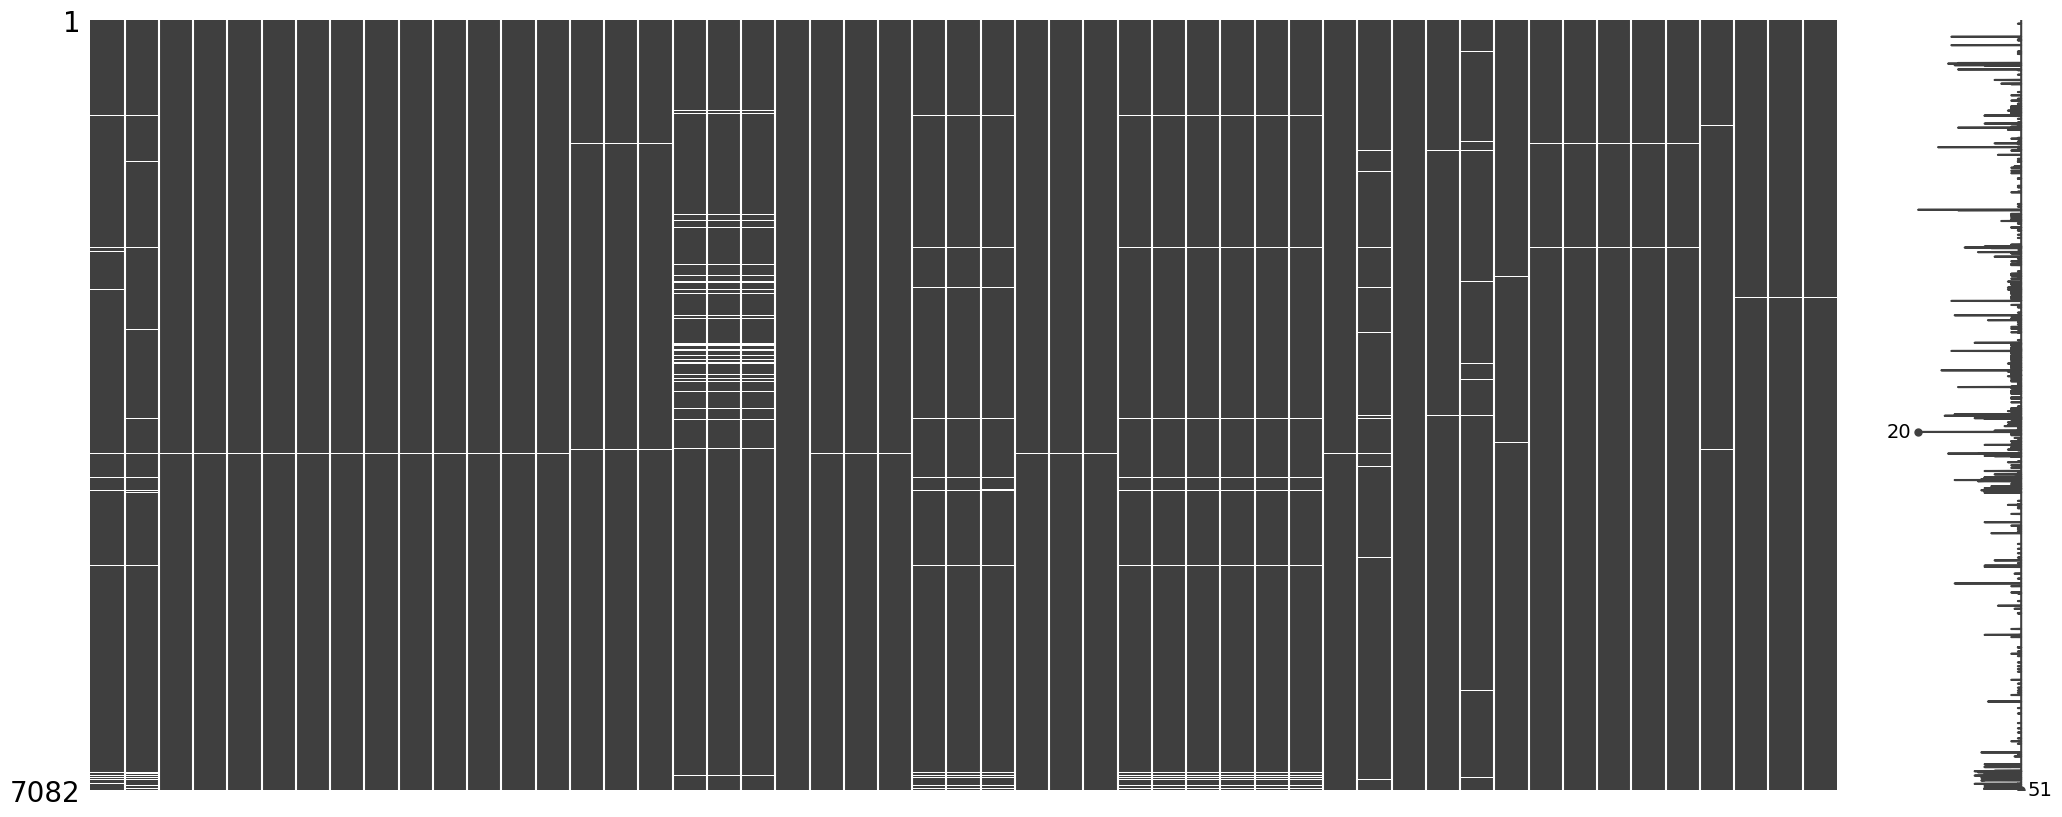

In [ ]:
import missingno as msgn


msgn.matrix(df[df_nan_columns])

Получаем, что действительно существуют строки, в которых находится большое количество пропусков. Вычислим эти строки следующим образом: 
1. рассмотрим все строки, которые содержат пропуски; 
2. подсчитаем для них долю пропущенных значений;
3. вычислим 75-ый процентиль по долям пропусков;
4. строки, доля пропусков в которых превышает 75-ый процентиль, отбросим.

In [45]:
nan_distribution = df[df.isna().values.any(axis=1)][df_nan_columns].isna().sum(axis=1) / n_numeric_features
nan_distribution 

34      0.0125
153     0.1125
154     0.2625
178     0.0125
184     0.0125
         ...  
7075    0.0375
7076    0.1375
7078    0.1375
7079    0.1375
7080    0.1375
Length: 613, dtype: float64

In [46]:
nan_distribution.describe()

count    613.000000
mean       0.057892
std        0.059672
min        0.012500
25%        0.012500
50%        0.037500
75%        0.050000
max        0.387500
dtype: float64

Получаем, что 75-ый процентиль составляет 5% пропусков.

Отберем номера строк, в которых доля пропусков превышает этот процентиль.

In [47]:
nan_row_ids = nan_distribution[nan_distribution > 0.05].index
nan_row_ids

Index([ 153,  154,  231,  395,  401,  415,  417,  454,  551,  552,
       ...
       7054, 7060, 7065, 7067, 7068, 7069, 7076, 7078, 7079, 7080],
      dtype='int64', length=149)

И отбросим их.

In [ ]:
df.drop(nan_row_ids, inplace=True)

### 1.1.3. <a id='toc1_1_3_'></a>[Формирование обучающей и тестирующей выборок](#toc0_)

Для построения статистических моделей, а также их проверки, необходимо сформировать обучающий и тестовый наборы данных.

При помощи метода `train_test_split` сформируем обучающую и тестовую выборки. Поскольку в исходном датасете около 7000 записей, на тест оставим 15% данных. При этом обязательно выполним стратификацию, чтобы и в train-, и в test-выборках сохранялась пропорция цензурированных данных.

Дополнительно, перемешаем данные, чтобы в них не было временных и порядковых зависимостей, которые могли возникнуть при сборе датаета и порядке хранения записей в БД.

Необходимо выделить обучающий и тестовый датасеты именно на данном этапе, чтобы не допустить утечки данных.

In [51]:
from sklearn.model_selection import train_test_split

`Исправление после валидации` На тест было отправлено не по одному экземпляру каждых данных (с разным признаком отказа), а была сформирована целая выборка + устранена проблема с неправильной интерпретацией признака отказа (когда 0 и 1 были поменяны местами). 

In [52]:
y_columns = ['Дней в работе', 'Признак отказа']

train_df, test_df = train_test_split(df, shuffle=True, stratify=df['Признак отказа'], random_state=seed, test_size=0.15)

X_train, X_test = train_df.drop(columns=y_columns), test_df.drop(columns=y_columns)
y_train, y_test = train_df[y_columns], test_df[y_columns]

### 1.1.4. <a id='toc1_1_4_'></a>[Обработка категориальных признаков](#toc0_)

Помимо вещественных признаков, датасет содержит категориальные признаки. Некоторые модели не могут автоматически их преобразовывать, потому необходима ручная кодировка данных значений в численный формат.

#### 1.1.4.1. <a id='toc1_1_4_1_'></a>[Выделение фрагментов категориальных данных](#toc0_)

Первоначально необходимо отобрать категориальные признаки. Поскольку по результатам первоначальной обработки все численные признаки стали иметь корректный тип данных, отберем категориальные данные при помощи метода `DataFrame.select_dtypes()`, который отбирает те столбцы датафрейма, которые соответствуют необходимому типу, в данном случае -- `object`.

In [53]:
object_columns = X_train.select_dtypes('object').columns
object_columns

Index(['Режим гр-ка', 'Группа', 'Группа ПКВ', 'Каталог ЭЦН. Производитель',
       'Типоразмер ЭЦН', 'Энергоэффективность ЭЦН', 'Тип ствола'],
      dtype='object')

Далее отобразим полученные фрагменты, сводную информацию о них, а также проверим, что обучающая выборка содержит представителей каждой уникальной категории относительно каждого признака.

In [54]:
df[object_columns].head()

,Режим гр-ка,Группа,Группа ПКВ,Каталог ЭЦН. Производитель,Типоразмер ЭЦН,Энергоэффективность ЭЦН,Тип ствола
0,ПКВ;ПДФ,Группа ПКВ,Без группы,Новомет,2А,e3,Вертикальный
1,ПКВ,Группа ПКВ,Без группы,Новомет,5,e3,Вертикальный
2,ПКВ,Группа ПКВ,Без группы,Новомет,5,e2,Вертикальный
3,ПКВ,Группа ПКВ,Без группы,Новомет,5,e2,Вертикальный
4,ПКВ,Группа ПКВ,Без группы,Schlumberger,5А,e2,Вертикальный


In [55]:
df[object_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6933 entries, 0 to 7081
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Режим гр-ка                 6933 non-null   object
 1   Группа                      6933 non-null   object
 2   Группа ПКВ                  6933 non-null   object
 3   Каталог ЭЦН. Производитель  6933 non-null   object
 4   Типоразмер ЭЦН              6933 non-null   object
 5   Энергоэффективность ЭЦН     6933 non-null   object
 6   Тип ствола                  6933 non-null   object
dtypes: object(7)
memory usage: 433.3+ KB


In [56]:
df[object_columns].nunique() - X_train[object_columns].nunique()

Режим гр-ка                   0
Группа                        0
Группа ПКВ                    0
Каталог ЭЦН. Производитель    0
Типоразмер ЭЦН                0
Энергоэффективность ЭЦН       0
Тип ствола                    0
dtype: int64

Сформируем категориальную обучающую выборку.

In [57]:
object_train = X_train.select_dtypes('object')
object_train

,Режим гр-ка,Группа,Группа ПКВ,Каталог ЭЦН. Производитель,Типоразмер ЭЦН,Энергоэффективность ЭЦН,Тип ствола
955,ПКВ;ПДФ,Группа ПКВ,ПКВ 24,Schlumberger,5А,e2,Горизонтальный
3841,ПДФ;ПКВ,Группа ПДФ,Группа ПДФ,Новомет,3,e1,Наклонно-направленный
3731,ПКВ,Группа ПКВ,Без группы,Борец,5,e2,Наклонно-направленный
3417,ПДФ;ПКВ,Группа ПКВ,ПКВ 48,Schlumberger,5А,e2,Горизонтальный
2533,ПКВ,Группа ПКВ,ПКВ 48,Новые технологии,5,e1,Горизонтальный
...,...,...,...,...,...,...,...
4056,ПКВ,Группа ПКВ,ПКВ 24,Борец,5А,e2,Горизонтальный
5942,ПДФ;ПКВ,Группа ПКВ,Без группы,Schlumberger,5А,e2,Наклонно-направленный
670,ПКВ;ПДФ,Группа ПКВ,Без группы,Schlumberger,5А,e2,Наклонно-направленный
3012,ПКВ,Группа ПКВ,ПКВ 48,Борец,5А,e2,Горизонтальный


Аналогичные действия выполним для тестовой выборки.

In [58]:
object_test = X_test.select_dtypes('object')
object_test

,Режим гр-ка,Группа,Группа ПКВ,Каталог ЭЦН. Производитель,Типоразмер ЭЦН,Энергоэффективность ЭЦН,Тип ствола
6068,ПДФ;ПКВ,Без группы,Без группы,Schlumberger,5А,e2,Горизонтальный
3156,ПКВ,Группа ПКВ,ПКВ 48,Schlumberger,5А,e2,Горизонтальный
5160,ПКВ,Группа ПКВ,Без группы,Новые технологии,5,e2,Наклонно-направленный
3890,ПКВ,Группа ПКВ,Без группы,Новомет,3,e1,Наклонно-направленный
2141,ПКВ,Группа ПКВ,ПКВ 48,Борец,5,e2,Наклонно-направленный
...,...,...,...,...,...,...,...
2087,ПДФ;ПКВ,Без группы,Без группы,Лемаз,5,e2,Горизонтальный
6562,ПКВ,Группа ПКВ,Без группы,Борец,5А,e2,Горизонтальный
1179,ПКВ,Группа ПКВ,ПКВ 48,Новые технологии,5,e3,Наклонно-направленный
4913,ПКВ,Группа ПКВ,ПКВ 48,Борец,5А,e2,Горизонтальный


#### 1.1.4.2. <a id='toc1_1_4_2_'></a>[Кодирование категориальных данных](#toc0_)

В данном пункте осуществим кодирование категориальных данных при помощи метода One-Hot Encoding.

One-Hot Encoding — метод преобразования равнозначных категориальных признаков в числовые. Для каждой категории создаётся отдельный бинарный столбец: 1, если объект принадлежит категории, и 0 — иначе.

Чтобы избежать мультиколлинеарности, возникающей при данном виде кодирования, можно удалить один из one-hot столбцов. Это не приведёт к потере информации, так как его значение можно восстановить по остальным.



Поскольку относительно категориальных признаков не наблюдается отношения порядка, данный метод хорошо применим.

Класс `OneHotEncoder` реализован в библиотеке `sklearn`.

In [59]:
from sklearn.preprocessing import OneHotEncoder

Преобразуем равноценные категориальные данные и сохраним их в переменные `one_hot_train` и `one_hot_test`. 

Для удаления одного из столбцов воспользуемся параметром `drop='first'`. Также для сохранения наименования столбцов сформируем датафрейм из сырых данных, выдаваемых методами `OneHotEncoder.fit_transform()` и `OneHotEncoder.transform()`, при помощи матрицы one-hot данных `encoded_data`, а также наименования one-hot столбцов, получаемых из метода `OneHotEncoder.get_feature_names_out()`.

In [60]:
one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')

In [61]:
encoded_data = one_hot_encoder.fit_transform(object_train)

one_hot_train = pd.DataFrame(
    encoded_data,
    columns=one_hot_encoder.get_feature_names_out(object_columns)
)
one_hot_train

,Режим гр-ка_АПВ;ПКВ;ПДФ,Режим гр-ка_ПДФ,Режим гр-ка_ПДФ;АПВ,Режим гр-ка_ПДФ;АПВ;ПКВ,Режим гр-ка_ПДФ;ПКВ,Режим гр-ка_ПДФ;ПКВ;АПВ,Режим гр-ка_ПДФ;ПКВ;ЧЧ,Режим гр-ка_ПДФ;ПКВ;ЧЧ;АПВ,Режим гр-ка_ПДФ;ЧЧ;ПКВ,Режим гр-ка_ПКВ,...,Типоразмер ЭЦН_4,Типоразмер ЭЦН_5,Типоразмер ЭЦН_5А,Типоразмер ЭЦН_nan,Энергоэффективность ЭЦН_e1,Энергоэффективность ЭЦН_e2,Энергоэффективность ЭЦН_e3,Энергоэффективность ЭЦН_nan,Тип ствола_Горизонтальный,Тип ствола_Наклонно-направленный
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5889,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [62]:
encoded_data = one_hot_encoder.transform(object_test)

one_hot_test = pd.DataFrame(
    encoded_data,
    columns=one_hot_encoder.get_feature_names_out(object_columns)
)
one_hot_test

,Режим гр-ка_АПВ;ПКВ;ПДФ,Режим гр-ка_ПДФ,Режим гр-ка_ПДФ;АПВ,Режим гр-ка_ПДФ;АПВ;ПКВ,Режим гр-ка_ПДФ;ПКВ,Режим гр-ка_ПДФ;ПКВ;АПВ,Режим гр-ка_ПДФ;ПКВ;ЧЧ,Режим гр-ка_ПДФ;ПКВ;ЧЧ;АПВ,Режим гр-ка_ПДФ;ЧЧ;ПКВ,Режим гр-ка_ПКВ,...,Типоразмер ЭЦН_4,Типоразмер ЭЦН_5,Типоразмер ЭЦН_5А,Типоразмер ЭЦН_nan,Энергоэффективность ЭЦН_e1,Энергоэффективность ЭЦН_e2,Энергоэффективность ЭЦН_e3,Энергоэффективность ЭЦН_nan,Тип ствола_Горизонтальный,Тип ствола_Наклонно-направленный
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1036,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


### 1.1.5. <a id='toc1_1_5_'></a>[Обработка вещественных признаков](#toc0_)

Для построения моделей выживаемости необходимо, чтобы вещественные признаки не имели пропусков, поскольку данные модели не умеют их обрабатывать автоматически. Этому посвящен данный раздел.

Поскольку строится модель, основанная на исторических наблюдениях, опасно удалять аномалии и выбросы, так как они отражают реальный цикл работы оборудования. По этой причине в обработку вещественных признаков включается исключительно обработка пропущенных значений, без которой модели невозможно построить в программном виде.

#### 1.1.5.1. <a id='toc1_1_5_1_'></a>[Выделение вещественного датасета](#toc0_)

Первоначально необходимо сформировать вещественный участок исходного набора данных. Поскольку по результатам первичной обработки типов данных были выделены численные (целочисленные и вещественные) и категориальные признаки (тип данных `object`), отберем численный фрагмент, исключив из исходного набора данных категориальные признаки (чтобы не формировать отдельно целочисленный и вещественный фрагмент, а затем объединять его).

Сделаем это при помощи метода `DataFrame.select_dtypes()` и параметра `exclude='object'`, который служит фильтром типов данных (в данном случае, не попадут в итоговой фрагмент только категориальные данные).

In [63]:
numeric_train = X_train.select_dtypes(exclude='object')
numeric_train

,Сутки вращения насоса,Кол-во циклов ПКВ,УРЭ [кВтч/т],УРЭ К [кВтч/т],Э/э (Wакт) [кВт*ч],Э/э реакт. (ТМ),Э/э счет. (ТМ) [Вт],Qж OIS протяжка среднее [м3/сут],Qж OIS протяжка медиана [м3/сут],Qж OIS протяжка ст. откл-е [м3/сут],...,Lнкт [м] НКТ,ЭРА.Дата монтажа_day,ЭРА.Дата монтажа_month,ЭРА.Дата монтажа_year,Дата первой работы сборки_day,Дата первой работы сборки_month,Дата первой работы сборки_year,Дата начала экспл-ии_day,Дата начала экспл-ии_month,Дата начала экспл-ии_year
955,450.297712,26075.578249,34.653278,52.948092,954814.29,157105.99,633718.80,21.631619,22.830,5.920656,...,3282.09,28,5,2020,29,5,2020,30,9,2019
3841,386.191898,97.066667,28.575251,31.485219,515777.79,686.27,456393.40,48.617424,48.090,7.643591,...,3125.94,2,6,2021,3,6,2021,10,4,2020
3731,147.952820,45277.024731,21.799052,27.153896,213986.18,137097.60,169233.60,8.503688,7.760,2.180921,...,2810.03,9,2,2022,10,2,2022,29,1,2021
3417,204.273773,37714.033333,20.936685,26.216107,338070.42,254447.87,267250.10,19.544727,17.470,3.672767,...,3063.19,27,11,2021,29,11,2021,27,1,2020
2533,118.588889,10675.733333,36.482304,40.574882,160737.56,18609.50,151153.00,21.500347,20.700,7.470491,...,2920.00,19,3,2020,20,3,2020,25,5,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4056,163.577338,11285.250000,19.205000,21.983098,366740.52,210098.09,327722.60,46.220574,38.000,25.026783,...,2644.84,13,7,2022,14,7,2022,2,5,2022
5942,62.121435,39325.600000,21.001846,34.429198,90272.70,4336.00,52327.84,3.252371,3.238,0.259234,...,2581.99,3,5,2022,4,5,2022,10,8,2010
670,151.076898,52260.200000,37.930687,41.530553,226427.50,89230.64,149397.80,4.270435,3.720,1.442905,...,2869.26,27,6,2020,30,6,2020,10,3,2016
3012,198.945995,33260.900000,21.047806,23.221295,878295.51,168.06,353694.30,29.720994,27.300,9.956742,...,3238.00,3,9,2020,4,9,2020,20,4,2019


In [64]:
numeric_test = X_test.select_dtypes(exclude='object')
numeric_test

,Сутки вращения насоса,Кол-во циклов ПКВ,УРЭ [кВтч/т],УРЭ К [кВтч/т],Э/э (Wакт) [кВт*ч],Э/э реакт. (ТМ),Э/э счет. (ТМ) [Вт],Qж OIS протяжка среднее [м3/сут],Qж OIS протяжка медиана [м3/сут],Qж OIS протяжка ст. откл-е [м3/сут],...,Lнкт [м] НКТ,ЭРА.Дата монтажа_day,ЭРА.Дата монтажа_month,ЭРА.Дата монтажа_year,Дата первой работы сборки_day,Дата первой работы сборки_month,Дата первой работы сборки_year,Дата начала экспл-ии_day,Дата начала экспл-ии_month,Дата начала экспл-ии_year
6068,48.840972,1104.000000,18.113333,20.325373,115979.91,2.600440e+04,1.029801e+05,83.066060,80.556,13.484367,...,3180.00,24,10,2024,26,10,2024,31,12,2023
3156,138.712101,48657.086207,21.361247,25.374031,266267.94,3.201130e+07,2.527117e+05,13.845808,13.550,6.069720,...,2862.71,27,6,2021,30,6,2021,4,4,2020
5160,316.096007,19596.416667,6.290030,18.070890,420582.40,4.494211e+04,1.410077e+05,33.532795,33.000,2.843804,...,2459.60,2,1,2023,5,1,2023,16,2,2007
3890,52.588378,6090.877586,32.653043,39.298373,76725.21,0.000000e+00,6.287640e+04,10.149667,9.950,1.632666,...,2746.81,28,7,2021,30,7,2021,3,7,2020
2141,37.629825,6927.604762,30.394103,167.702414,194322.21,6.847770e+03,2.968955e+04,8.186959,8.000,0.926358,...,2629.84,3,1,2023,4,1,2023,19,11,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2087,540.508009,8463.833333,13.131593,15.052395,645337.61,2.227210e+05,6.086089e+05,104.248386,114.416,27.165313,...,3030.00,23,8,2023,25,8,2023,25,8,2023
6562,158.350143,70637.947275,18.455427,25.684067,368300.44,1.990092e+05,2.480077e+05,11.729843,11.810,5.120099,...,2847.77,21,10,2020,22,10,2020,28,5,2020
1179,39.041019,16569.904301,22.023314,25.764490,82284.29,6.000000e-01,7.583880e+04,12.093412,10.300,6.816270,...,2940.00,9,12,2021,10,12,2021,28,5,2010
4913,42.270833,19922.000000,27.618517,45.362675,74404.15,4.295004e+08,4.295413e+08,4.347938,4.400,0.509624,...,2940.42,17,10,2023,18,10,2023,26,8,2019


#### 1.1.5.2. <a id='toc1_1_5_2_'></a>[Заполнение пропущенных значений в датасете](#toc0_)

Ввиду специфики данных (каждая строка представляет собой уникальный объект, и для данного объекта отсутствуют строки, по которым можно выполнить агрегацию этих объектов, например, по времени), основным методом заполнения является вычисление значения на всем признаке.

`Исправление после валидации` Потому такие методы, как скользящее окно и т.д., не подойдут, поскольку нельзя отсортировать значения признаков, чтобы окно прошло по ним.

##### 1.1.5.2.1. <a id='toc1_1_5_2_1_'></a>[Первичный анализ пропущенных значений](#toc0_)

Сперва при помощи комбинации методов `isna().sum()` подсчитаем, какое количество пропусков есть в каждом столбце. После этого благодаря условию temp != 0 отберем только те столбцы, к которых есть хотя бы 1 пропуск.

Сделаем это для обучающей и тестовой выборок по-отдельности. 

In [65]:
temp = numeric_train.isna().sum()
nan_pivot_train = temp[temp != 0]
nan_pivot_train

УРЭ [кВтч/т]                          35
УРЭ К [кВтч/т]                        17
Pзаб среднее [ат]                      4
Pзаб медиана [ат]                      4
Pзаб ст. откл-е [ат]                   4
Pпласт среднее [ат]                  201
Pпл медиана [ат]                     201
Pпласт ст. откл-е [ат]               201
Pлин среднее [атм]                    21
Pлин медиана [атм]                    21
Pлин ст. откл-е [атм]                 26
Загрузка ПЭД среднее [%]               1
Загрузка ПЭД медиана [%]               1
Загрузка ПЭД ст. откл-е [%]            2
Ток фазы A среднее [А]                 1
Ток фазы A медиана [А]                 1
Ток фазы A ст. откл-е [А]              2
К подачи на устье по среднему         36
Диаметр ЭЦН [мм]                       1
Номинальный дебит сборки [м3/сут]     10
Номинальный напор сборки [м]          74
Номинальная мощность сборки [кВт]     12
dL вдп [м] ТР                          1
H вдп [м] ТР                           1
dH вдп-насос [м]

In [66]:
temp = numeric_test.isna().sum()
nan_pivot_test = temp[temp != 0]
nan_pivot_test

УРЭ [кВтч/т]                          3
УРЭ К [кВтч/т]                        1
Pпласт среднее [ат]                  38
Pпл медиана [ат]                     38
Pпласт ст. откл-е [ат]               38
Pлин среднее [атм]                    7
Pлин медиана [атм]                    7
Pлин ст. откл-е [атм]                 7
К подачи на устье по среднему         8
Номинальный дебит сборки [м3/сут]     2
Номинальный напор сборки [м]         13
Номинальная мощность сборки [кВт]     1
dL насос [м] ТР                       1
H насос [м] ТР                        1
dH вдп-насос [м] ТР                   1
dtype: int64

Проверим, что признаки с пропусками из тестовой выборки содержатся в признаках с пропусками из обучающей выборки (при помощи операторов из теории множеств).

In [67]:
np.in1d(nan_pivot_test.index, nan_pivot_train.index)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False,  True])

Видим, что 2 признака, которые содержат пропуски, не содержатся в обучающей выборке, значит, необходимо рассчитать значение для заполнения на основе обучающей выборки.

Сохраним названия вещественных столбцов с пропусками в специальную переменную `nan_columns`.

In [68]:
nan_columns = np.union1d(nan_pivot_test.index, nan_pivot_train.index)
nan_columns

array(['D колонны внутренний [мм] ТР', 'D нкт внешний min [мм] НКТ',
       'D нкт внутренний min [мм] НКТ', 'H вдп [м] ТР', 'H насос [м] ТР',
       'Lнкт [м] НКТ', 'Pзаб медиана [ат]', 'Pзаб среднее [ат]',
       'Pзаб ст. откл-е [ат]', 'Pлин медиана [атм]', 'Pлин среднее [атм]',
       'Pлин ст. откл-е [атм]', 'Pпл медиана [ат]', 'Pпласт среднее [ат]',
       'Pпласт ст. откл-е [ат]', 'dH вдп-насос [м] ТР', 'dL вдп [м] ТР',
       'dL насос [м] ТР', 'Диаметр ЭЦН [мм]', 'Загрузка ПЭД медиана [%]',
       'Загрузка ПЭД среднее [%]', 'Загрузка ПЭД ст. откл-е [%]',
       'К подачи на устье по среднему',
       'Номинальная мощность сборки [кВт]',
       'Номинальный дебит сборки [м3/сут]',
       'Номинальный напор сборки [м]', 'Ток фазы A медиана [А]',
       'Ток фазы A среднее [А]', 'Ток фазы A ст. откл-е [А]',
       'УРЭ [кВтч/т]', 'УРЭ К [кВтч/т]'], dtype=object)

Также проанализируем типы данных столбцов с пропусками. Это необходимо для стратегии заполнения этих самых пропусков.

In [69]:
numeric_train[nan_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 5893 entries, 955 to 189
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   D колонны внутренний [мм] ТР       5886 non-null   float64
 1   D нкт внешний min [мм] НКТ         5887 non-null   float64
 2   D нкт внутренний min [мм] НКТ      5887 non-null   float64
 3   H вдп [м] ТР                       5892 non-null   float64
 4   H насос [м] ТР                     5893 non-null   float64
 5   Lнкт [м] НКТ                       5887 non-null   float64
 6   Pзаб медиана [ат]                  5889 non-null   float64
 7   Pзаб среднее [ат]                  5889 non-null   float64
 8   Pзаб ст. откл-е [ат]               5889 non-null   float64
 9   Pлин медиана [атм]                 5872 non-null   float64
 10  Pлин среднее [атм]                 5872 non-null   float64
 11  Pлин ст. откл-е [атм]              5867 non-null   float64
 

Видим, что все признаки, содержащие пропуски, являются вещественными.

##### 1.1.5.2.2. <a id='toc1_1_5_2_2_'></a>[Заполнение пропущенных значений методом MICE](#toc0_)

`Исправление после валидации` Добавлено в рассмотрение заполнение пропусков при помощи MICE.

Метод MICE (Multiple Imputation by Chained Equations) используется для заполнения пропусков в данных. Он работает следующим образом: сначала пропуски заполняются простым способом, например средними значениями. Затем для каждого признака с пропусками строится модель, в которой остальные признаки выступают предикторами, и недостающие значения заменяются на предсказанные. Этот процесс повторяется для всех признаков несколько раз, постепенно уточняя результаты. 

Дополнительно процедура выполняется несколько раз с добавлением случайности, что позволяет учесть неопределённость и получить несколько возможных наборов данных. Благодаря этому MICE восстанавливает пропуски более реалистично, чем простое заполнение средним или медианой, так как учитывает взаимосвязи между признаками.

Для того, чтобы проверить обобщающую способность модели, необходимо сгенерировать выборку с пропусками и по ней посчитать метрику NRMSE:

$$
\text{NRMSE} = \frac{\sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}}{\sigma_y}
$$

Обычно применяется следующая интерпретация метрики для каждого признака:
- NRMSE < 0.1: очень хорошее восстановление (практически без ошибок);
- 0.1 ≤ NRMSE < 0.2: хорошее качество, модель адекватна;
- 0.2 ≤ NRMSE < 0.3: среднее качество, есть заметные отклонения;
- NRMSE ≥ 0.3: восстановление слабое, метод работает плохо.

Создадим выборку, в которой искусственно сгенерируем 20% пропусков.

In [70]:
data_true = numeric_train.dropna().copy()
mask = np.random.rand(*data_true.shape) < 0.2  # 20% пропусков
data_masked = data_true.copy()
data_masked[mask] = np.nan

Обучим модель MICE, реализованную в библиотеке `scikit-learn` при помощи класса `IterativeImputer`.

In [71]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


imputer_test = IterativeImputer(max_iter=100, random_state=seed)
data_filled = pd.DataFrame(imputer_test.fit_transform(data_masked), columns=data_masked.columns)

Вычислим метрики для каждого признака, который содержит пропуски в исходной обучающей выборке.

In [72]:
from sklearn.metrics import mean_squared_error


nrmse = {}
for col in nan_columns:
    col_mask = mask[:, data_true.columns.get_loc(col)]
    mse = mean_squared_error(data_true.loc[col_mask, col], data_filled.loc[col_mask, col])
    nrmse[col] = np.sqrt(mse) / data_true[col].std()

print("NRMSE по колонкам:")
for col, val in nrmse.items():
    print(f"{col}: {val:.3f}")

NRMSE по колонкам:
D колонны внутренний [мм] ТР: 0.904
D нкт внешний min [мм] НКТ: 0.459
D нкт внутренний min [мм] НКТ: 0.468
H вдп [м] ТР: 0.285
H насос [м] ТР: 0.340
Lнкт [м] НКТ: 0.175
Pзаб медиана [ат]: 0.752
Pзаб среднее [ат]: 0.326
Pзаб ст. откл-е [ат]: 0.504
Pлин медиана [атм]: 0.752
Pлин среднее [атм]: 0.006
Pлин ст. откл-е [атм]: 0.007
Pпл медиана [ат]: 0.381
Pпласт среднее [ат]: 0.371
Pпласт ст. откл-е [ат]: 1.175
dH вдп-насос [м] ТР: 1.139
dL вдп [м] ТР: 0.173
dL насос [м] ТР: 0.128
Диаметр ЭЦН [мм]: 0.778
Загрузка ПЭД медиана [%]: 30.031
Загрузка ПЭД среднее [%]: 0.007
Загрузка ПЭД ст. откл-е [%]: 0.008
К подачи на устье по среднему: 0.482
Номинальная мощность сборки [кВт]: 0.463
Номинальный дебит сборки [м3/сут]: 0.365
Номинальный напор сборки [м]: 0.908
Ток фазы A медиана [А]: 0.878
Ток фазы A среднее [А]: 30.316
Ток фазы A ст. откл-е [А]: 0.838
УРЭ [кВтч/т]: 1.044
УРЭ К [кВтч/т]: 25.885


Исходя из значения метрики, получаем, что для многих признаков данный метод неприменим, поскольку он генерирует значения, которые не соответствуют данным.

##### 1.1.5.2.3. <a id='toc1_1_5_2_3_'></a>[Заполнение пропущенных значений методом анализа распределений](#toc0_)

Для того, чтобы решить проблему наличия пропусков в данных, попробуем заполнить пропуски такими значениями, которые гарантируют, что распределение не изменило свою структуру при заполнении. Для этого будем исследовать специальную метрику анализа, а также общий вид эмпирической функции плотности распределения. Это особенно важно, так как результирующие модели должны восстанавливать зависимости в данных.

Идея исследования будет заключаться в следующем. Первоначально данные с пропусками имеют свое распределение (для фиксированного признака), так как каждый признак был порожден некоторой случайной величиной. Функцию распределения этой случайно величины мы смоделируем при помощи эмпирической функции плотности распределения и гистограммы. Значения определенного признака тем самым формируют вариационный ряд. 

Будем заполнять пропуски некоторым значением (например, статистикой: средним, модой или медианой, а может, случайными значениями из интервала). Тогда у нас сформируется распределение признака до заполнения и после заполнения, и мы будем исследовать эти объекты на сходство.

Заполнение значением будет считаться успешным (то есть будет нам подходить), если:
1. структура эмпирической функции плотности не поменяется;
2. будут отсутствовать новые резкие выбросы в столбцах гистограммы (локальные максимумы функции плотности);
3. значение метрики вложенности двух распределений (дивергенция Кульбака-Лейблера) будет сравнительно небольшим (идеально, когда она равна нулю, значит, распределения совпали). Используется именно эта метрика, так как она покажет, насколько распределение после заполнения расхоже с распределением до заполнения.

Для того, чтобы построить гистограмму, нам нужно зафиксировать количество интервалов разбиения $N_i$ (для $i$-го признака) вариационного ряда относительно исходного распределения без заполнения пропусков. Для этого будем пользоваться эмпирической формулой Стерджеса:

$$N_i = \frac{r_i}{1 + 3.222 \cdot \lg(n_i)},$$

где $r_i$ -- размах, а $n_i$ -- размерность вариационного ряда.

Данная формула вычисляет оптимальное число интервалов непрерывного вариационного ряда.

In [73]:
def calc_bins(x: t.Iterable[float]) -> int:
    """Вычисление числа интервалов разбиения гистограммы при помощи формулы Стерджеса

    Args:
        x (t.Iterable[float]): Непрерывный вариационный ряд

    Returns:
        int: Число интервалов разбиения гистограммы
    """
    return int(
        np.ceil(
            (np.max(x) - np.min(x)) / int(1 + 3.222 * np.log10(len(x)))
        )
    )

Также напишем функцию, которая будет вычислять дивергенцию Кульбака-Лейблера при помощи функции `entropy()` из библиотеки `scipy`. Для этого сформируем полигоны частот при помощи модуля `numpy` и передадим их в `entropy()`.

In [74]:
from scipy.stats import entropy


def calc_kl_divergence(x: t.Iterable[float], new_x: t.Iterable[float]) -> float:
    """Вычисление КЛ-дивергенции для двух непрерывных вариационных рядов

    Args:
        x (t.Iterable[float]): Исходный непрерывных вариационный ряд
        new_x (t.Iterable[float]): Модифицированный непрерывных вариационный ряд

    Returns:
        float: Значение КЛ-дивергенции
    """
    bins = calc_bins(x)
    p, _ = np.histogram(x, bins=bins)
    q, _ = np.histogram(new_x, bins=bins)
    return entropy(p / np.sum(p), q / np.sum(q))

Реализуем функцию, которая будет строить гистограмму до заполнения и после заполнения, а также выводить дивергенцию и эмпирические функции плотности.

Для удобства отображения гистограммы будем использовать логарифмическую шкалу значений вариационного ряда, поскольку данные имеют произвольный масштаб, и гистограммы получаются растянутыми и нечитаемыми.

In [75]:
def draw_hist(x: np.ndarray, new_x: np.ndarray) -> None:
    """Вывод сводной информации до заполнения и после

    Args:
        x (np.ndarray): Изначальное распределение
        new_x (np.ndarray): Распределение после заполнения
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(
        f"Дивергенция Кульбака-Лейблера: {calc_kl_divergence(x, new_x):.6f}")
    sns.histplot(np.log(x), kde=True, stat='density',
                 label='Исходные данные', ax=ax[0], color='green')
    sns.histplot(np.log(new_x), kde=True, stat='density',
                 label='Данные после заполнения', ax=ax[1], color='red')
    fig.legend()

Заполнение пропусков в `pandas` реализовано при помощи словарей, имеющих следующую структуру: ключом является индекс позиции пропуска, а значением -- заполнение для конкретной позиции. Так как заполнять пропуски можно не только константным значением, но и случайным, напишем функцию, которая будет принимать колонку с пропуском и правило для заполнения, а возвращать словарь заполнения.

Обобщим правила заполнения для константных и случайных значений: будем принимать лямбда-функцию, которая и вернет число для заполнения при ее вызове. Если это константное число, то оно всегда и будет возвращаться, если случайное, то при вызове сгенерируется новое.

In [76]:
def get_fill_rule(col: pd.Series, variant: t.Callable[[], float]) -> t.Dict[int, float]:
    """Генерация словаря заполнения столбца

    Args:
        col (pd.Series): Столбец для заполнения
        variant (t.Callable[[], float]): Правило для заполнения

    Returns:
        t.Dict[int, float]: Словарь заполнения
    """
    return {
        key: variant() for key in col[col.isna()].keys()
    }

Также напишем результирующую функцию, которая реализует исследование заполнения пропусков.

In [77]:
def test_density_fillna(nan_col: pd.Series, variants: t.List[t.Callable[[], float]]) -> None:
    """Оператор алгоритма проверки релевантности пропусков

    Args:
        nan_col (pd.Series): Столбец с пропусками
        variants (t.List[t.Callable[[], float]]): Правила для заполнения пропусков
    """
    for variant in variants:
        x = nan_col.dropna()

        fill_rule = get_fill_rule(nan_col, variant)

        new_x = nan_col.fillna(fill_rule)

        draw_hist(x, new_x)

Проанализируем каждый столбец при помощи алгоритма, описанного выше.

Рассмотрим первый признак. Сохраним его в отдельную переменную для удобства работы, а также выведем гистограмму до изменения пропусков.

Будем проверять заполнение пропусков следующими величинами:
1. константный нуль;
2. среднее значение столбца (можно использовать среднее, так как все столбцы являются вещественными, а не целочисленными);
3. медиана столбца.

Для каждого признака из списка nan_columns будем анализировать различные значения и наилучшие помещать в словарь fillna_rule, в котором ключом будет являться название признака, а значением -- величина, которой заполнять пропуски в столбцах.

In [78]:
fillna_rule = {}

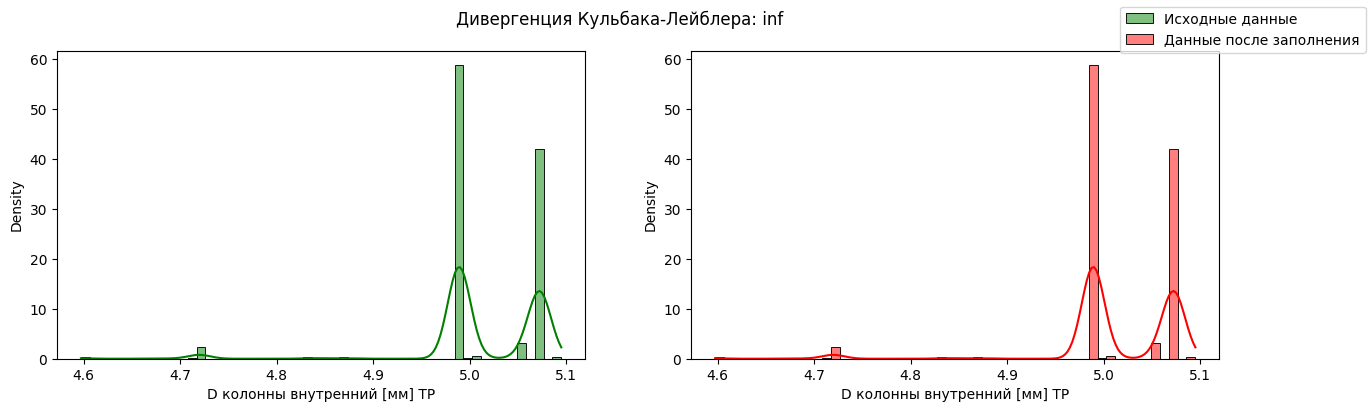

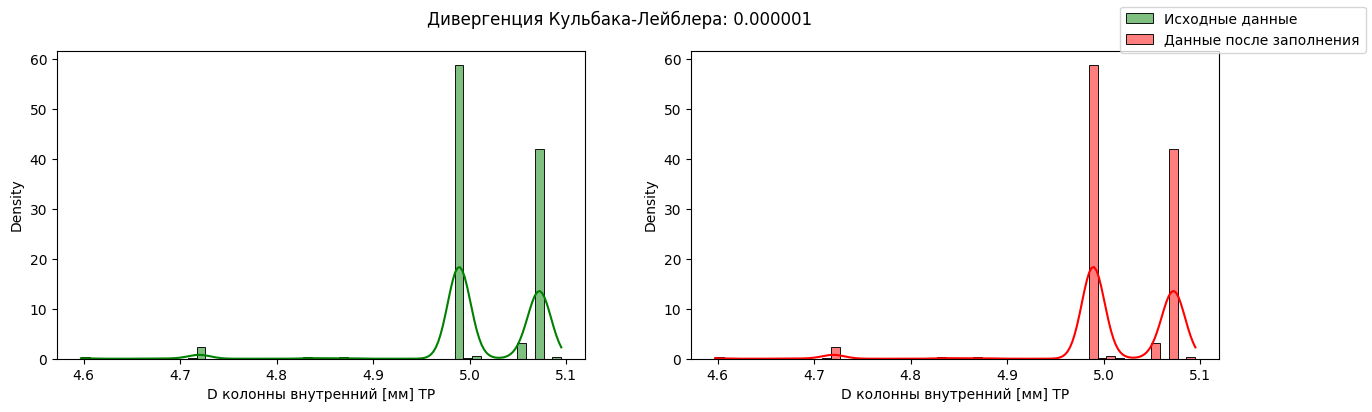

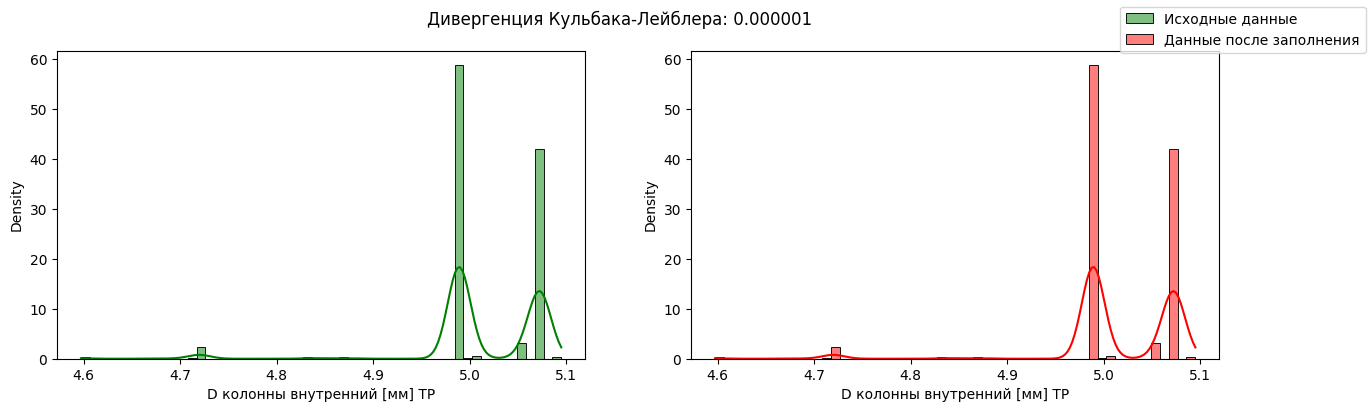

In [ ]:
x_t = numeric_train[nan_columns[0]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

При анализе графиков и значения дивергенции получаем, что наиболее оптимальным вариантом является заполнение пропусков при помощи среднего значения столбца, поскольку при таком подходе:
1. гистограмма существенно не преобразовывается;
2. достигается минимум К-Л дивергенции. 

При помощи метода `DataFrame.fillna()` реализуем заполнение пропусков.

In [82]:
fillna_rule[nan_columns[0]] = x_t.mean()

Воспользуемся аналогичными рассуждениями и методами для анализа новых признаков, содержащих пропущенные значения.

-----------

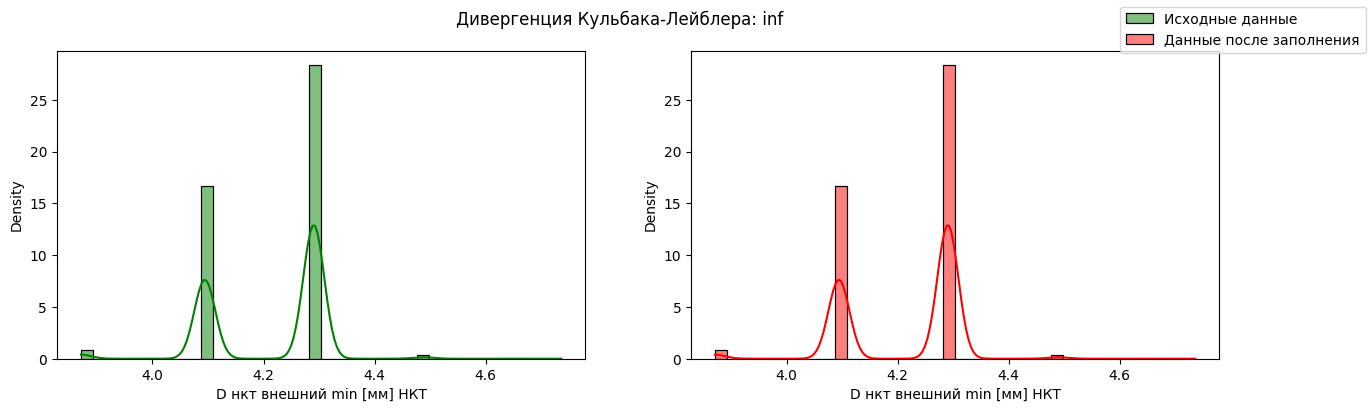

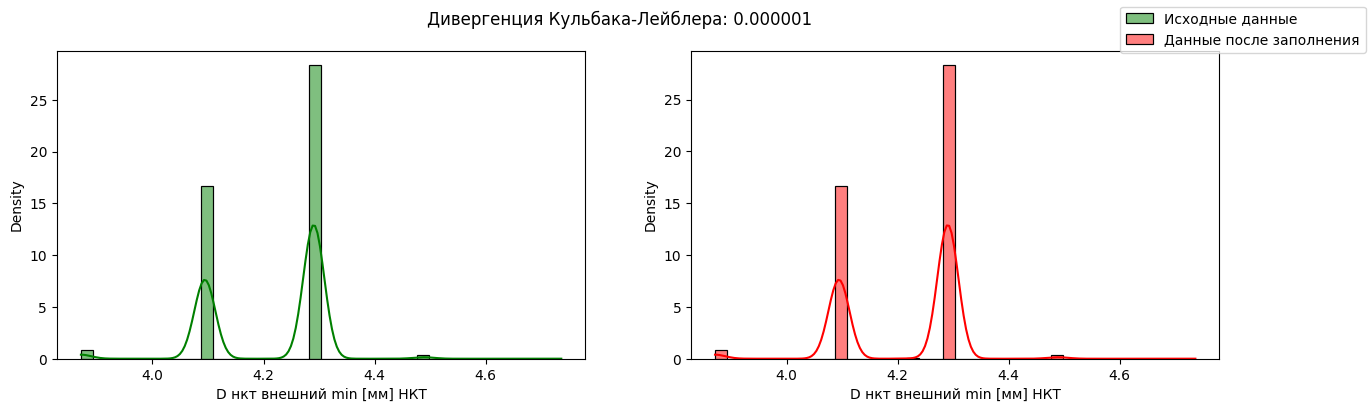

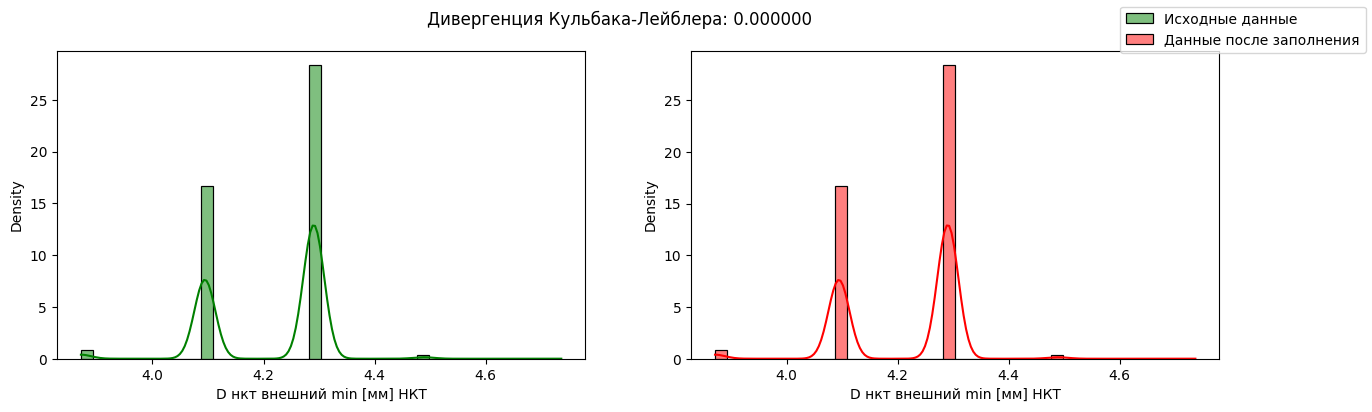

In [83]:
x_t = numeric_train[nan_columns[1]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [84]:
fillna_rule[nan_columns[1]] = x_t.median()

-----------

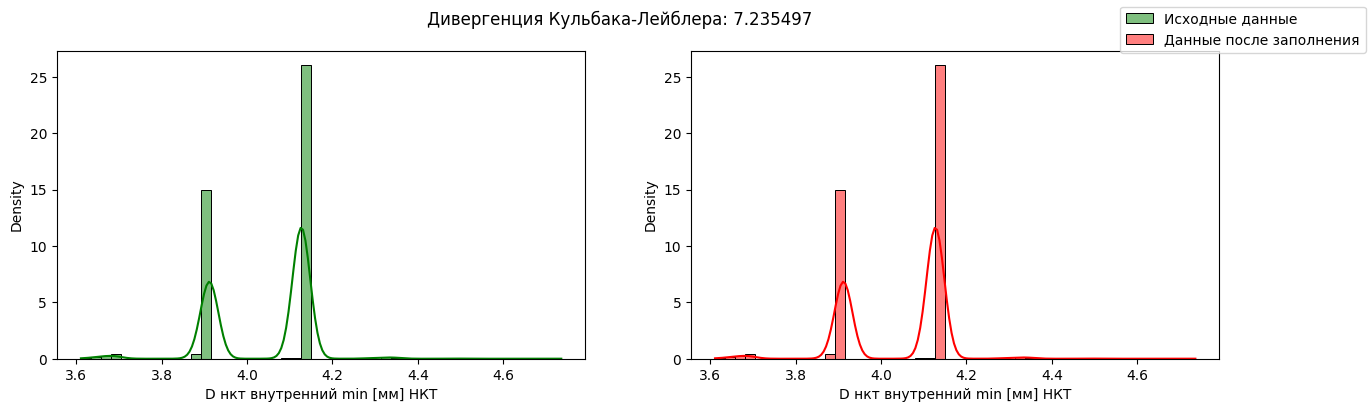

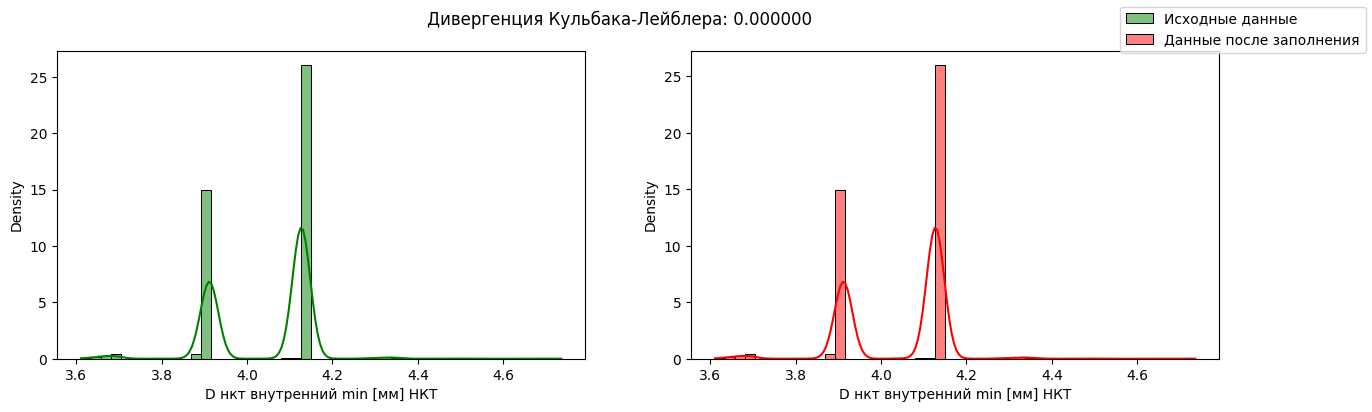

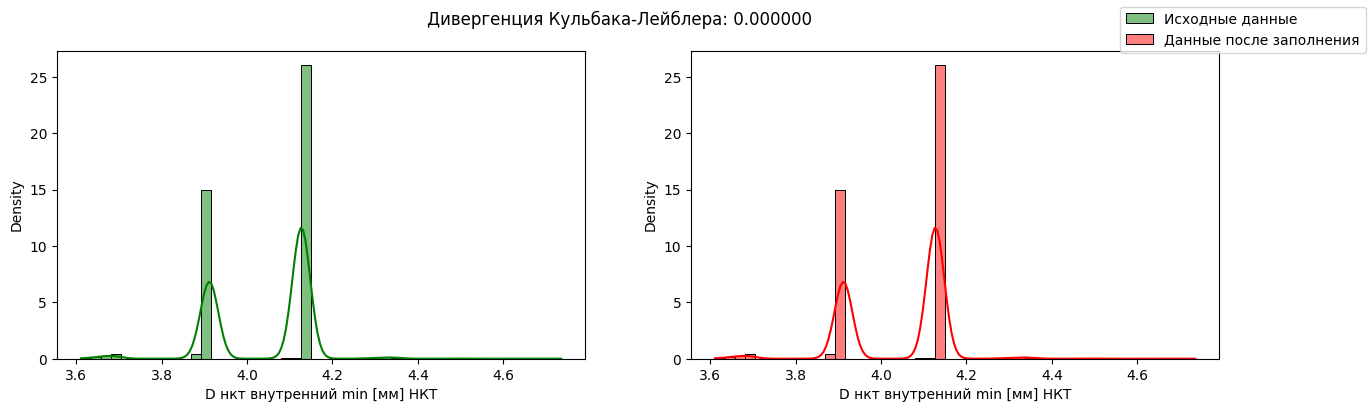

In [85]:
x_t = numeric_train[nan_columns[2]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [86]:
fillna_rule[nan_columns[2]] = x_t.mean()

-----------

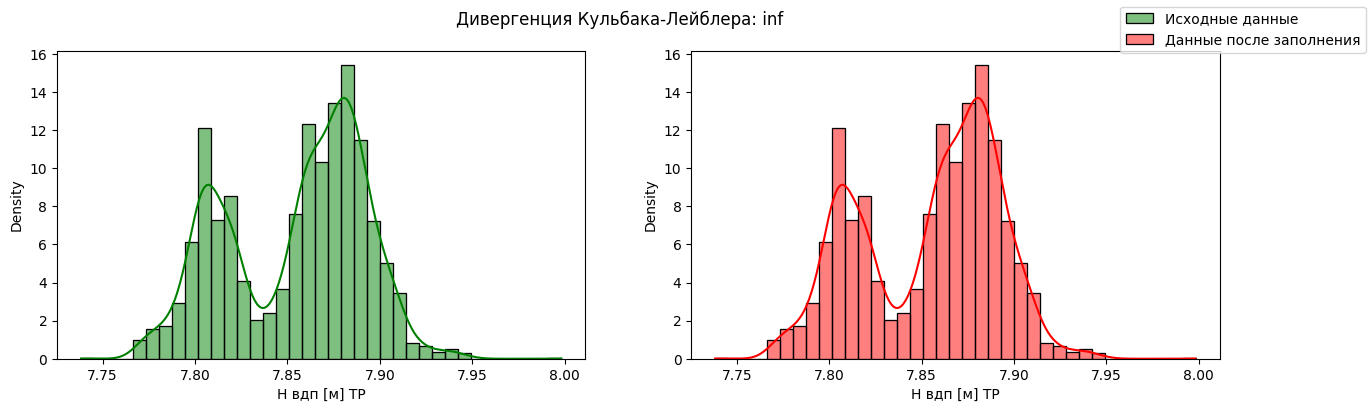

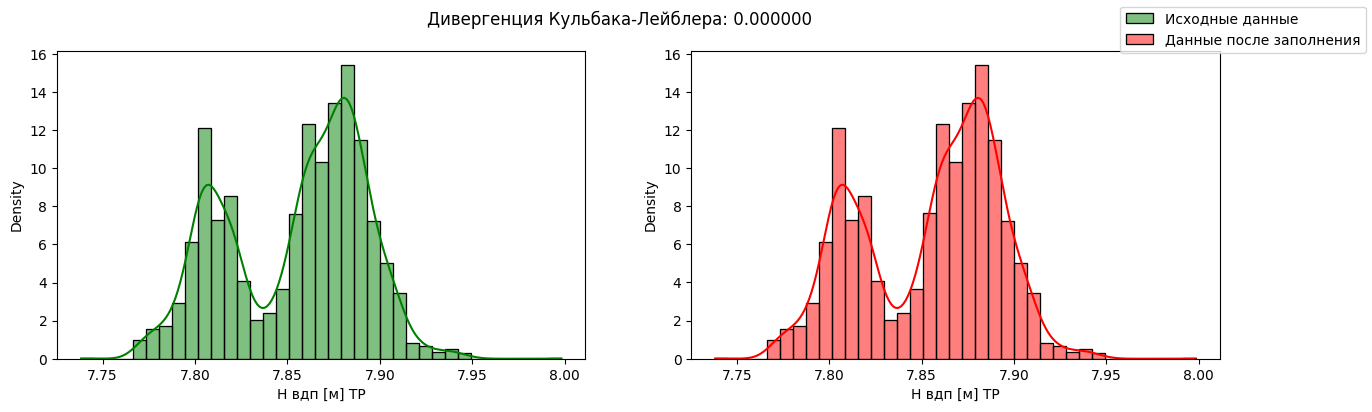

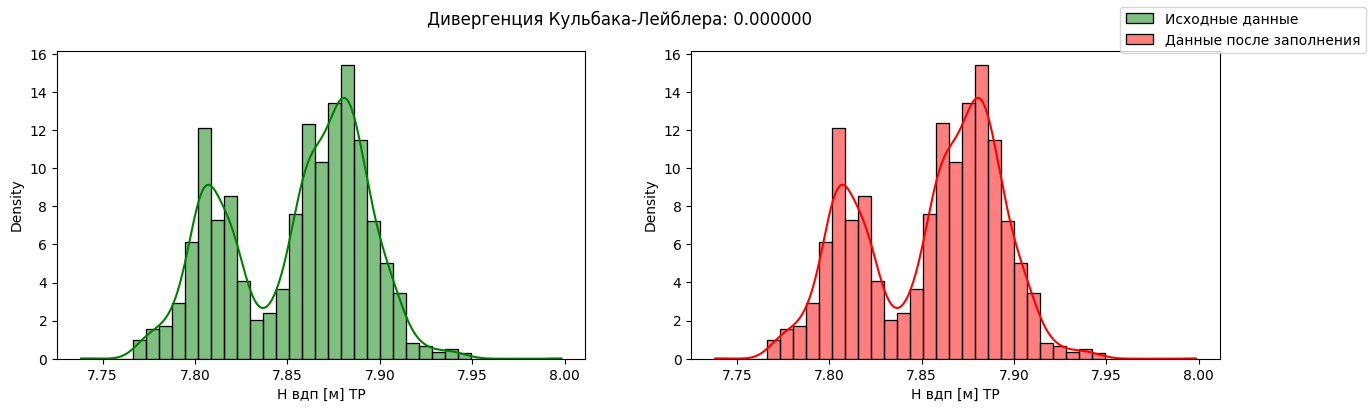

In [87]:
x_t = numeric_train[nan_columns[3]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [88]:
fillna_rule[nan_columns[3]] = x_t.mean()

-----------

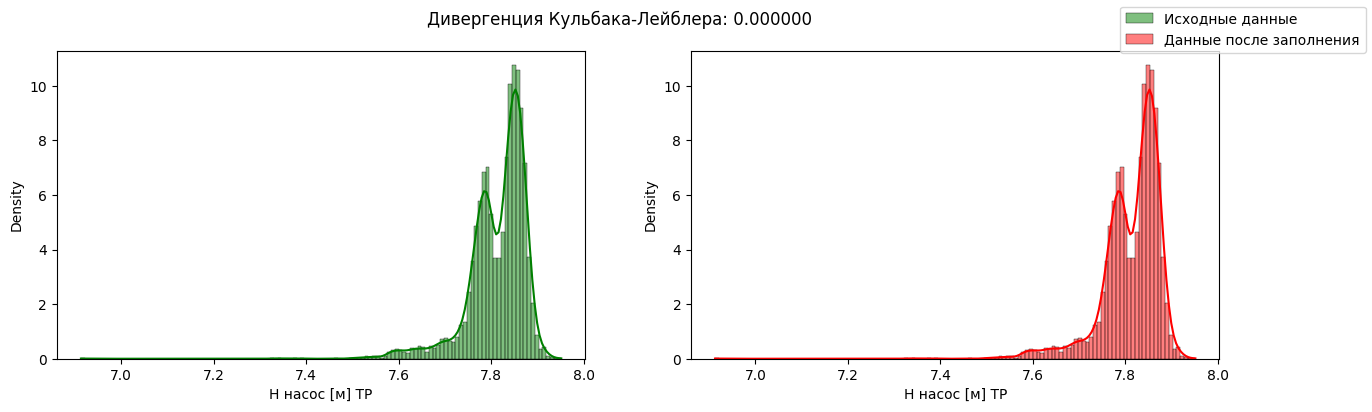

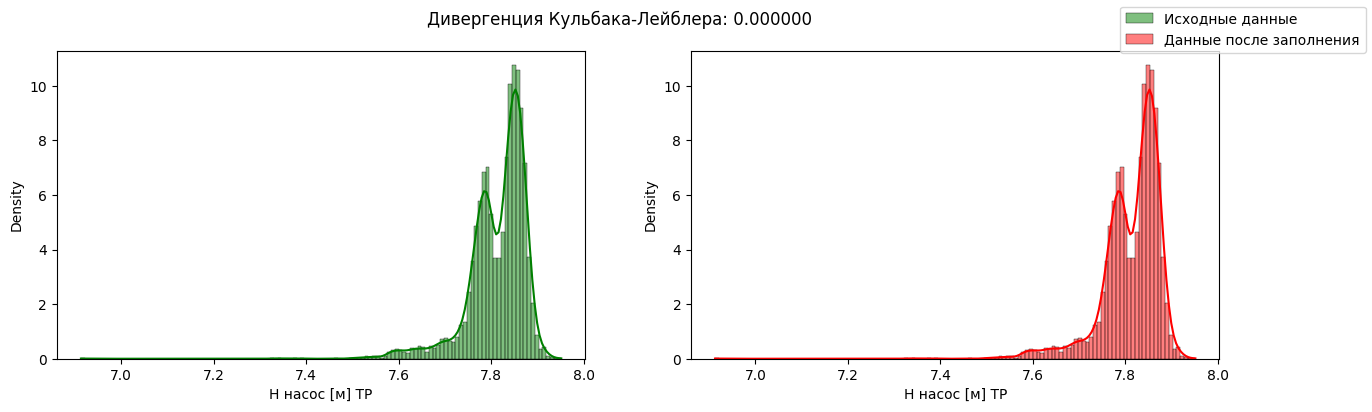

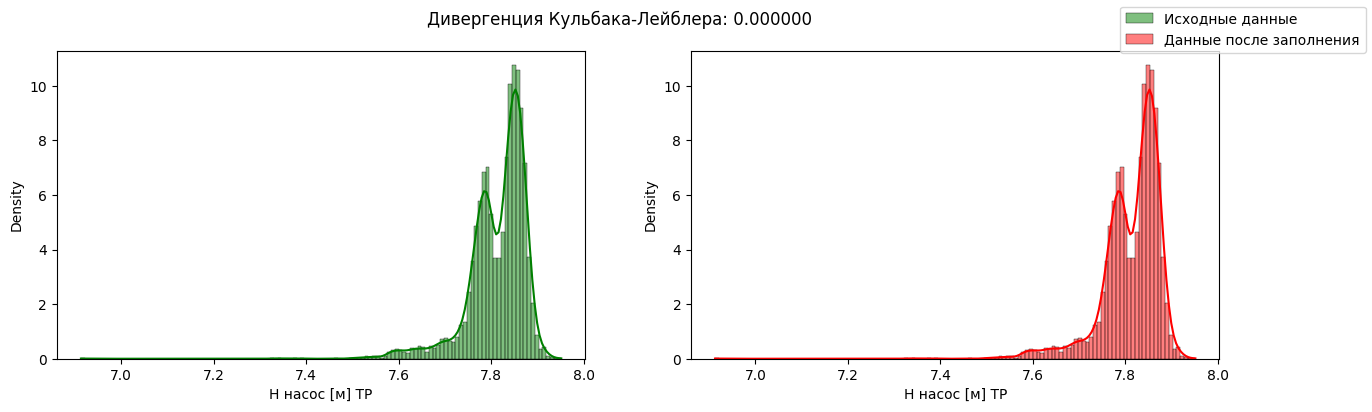

In [89]:
x_t = numeric_train[nan_columns[4]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [90]:
fillna_rule[nan_columns[4]] = x_t.median()

-----------

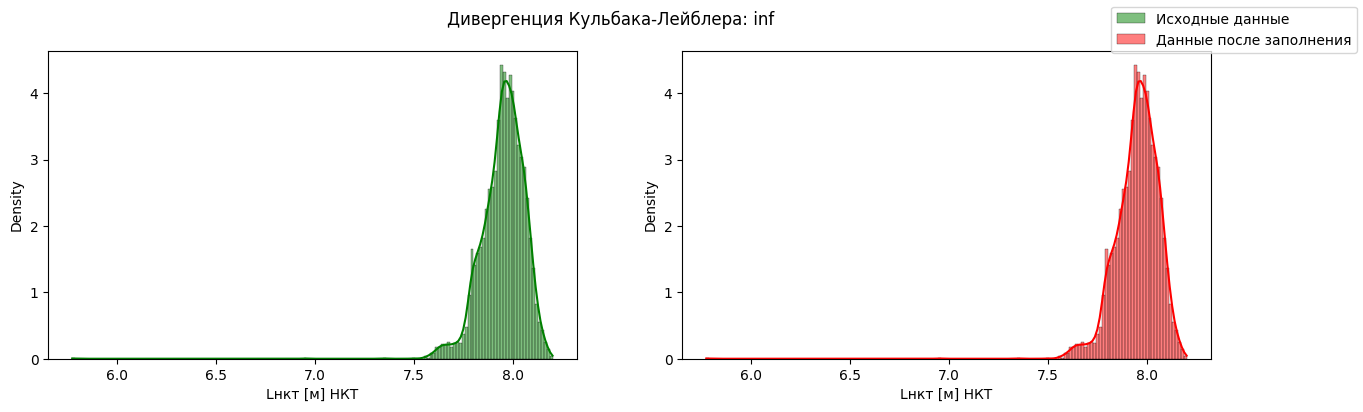

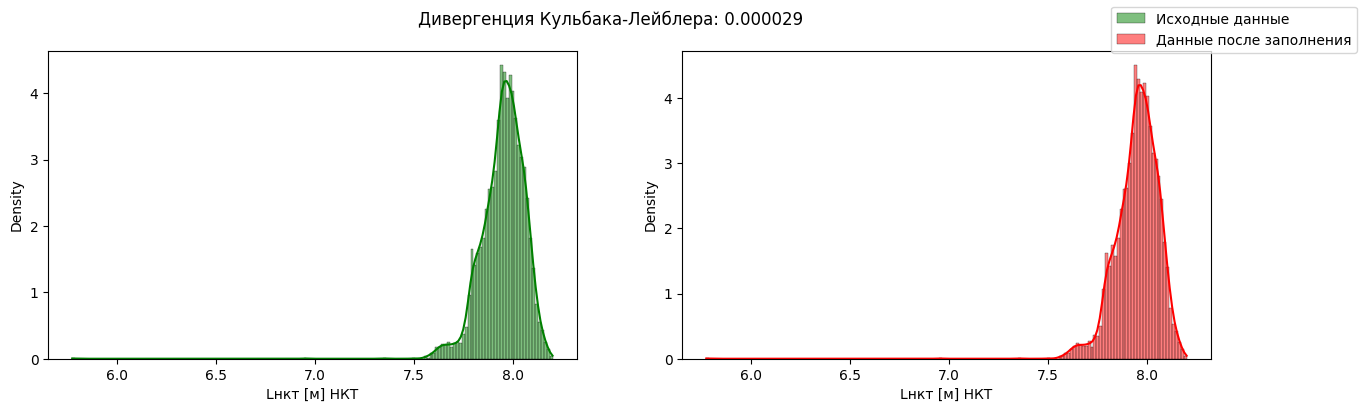

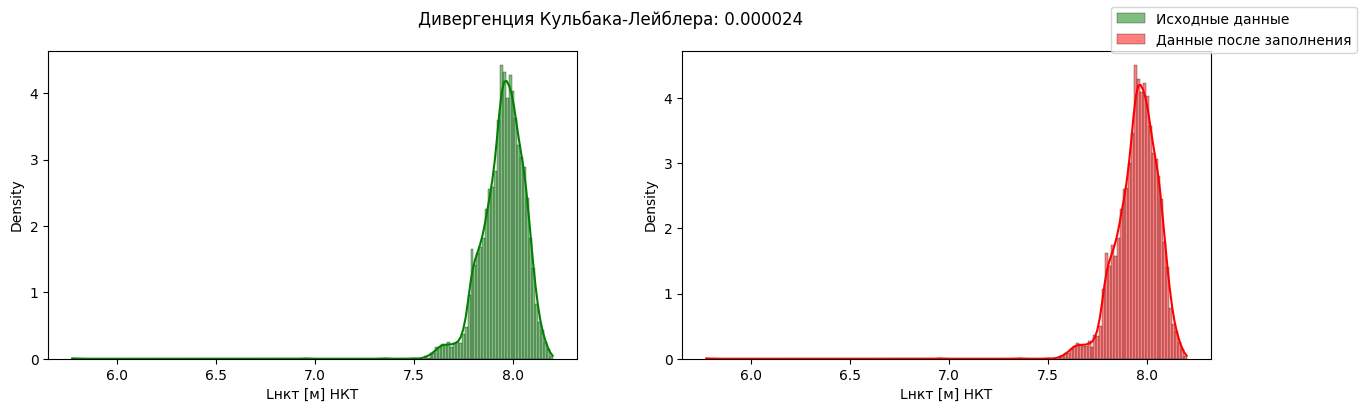

In [91]:
x_t = numeric_train[nan_columns[5]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [92]:
fillna_rule[nan_columns[5]] = x_t.median()

-----------

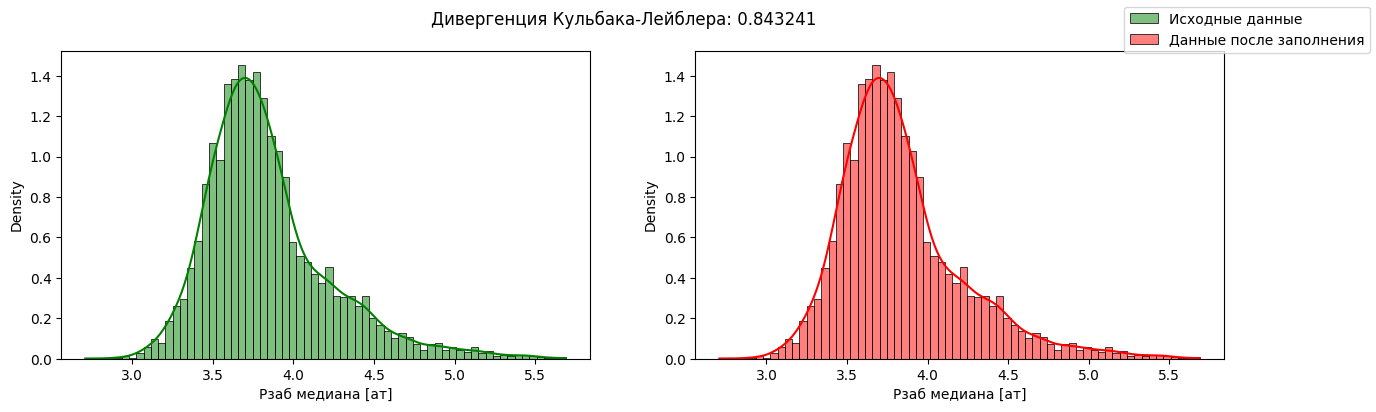

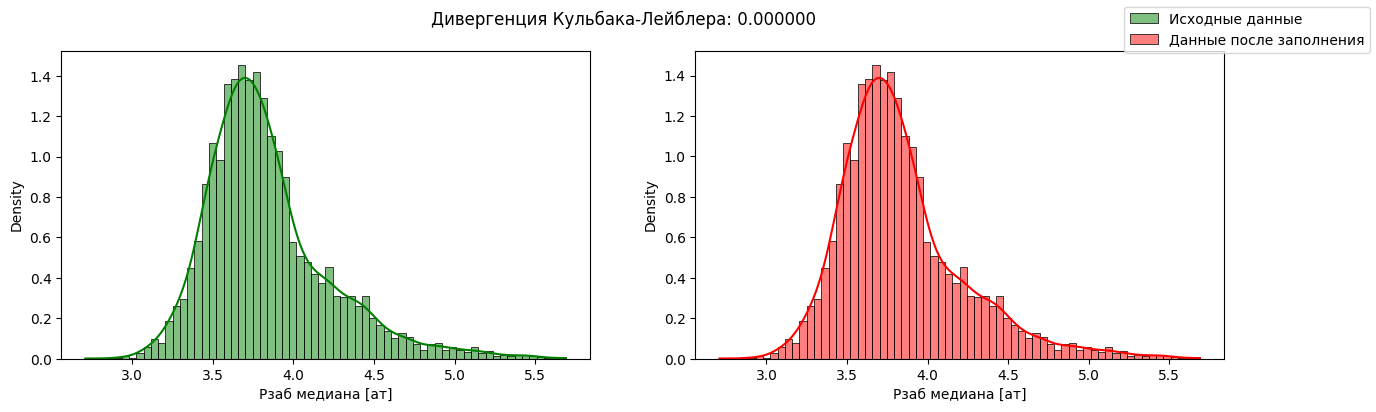

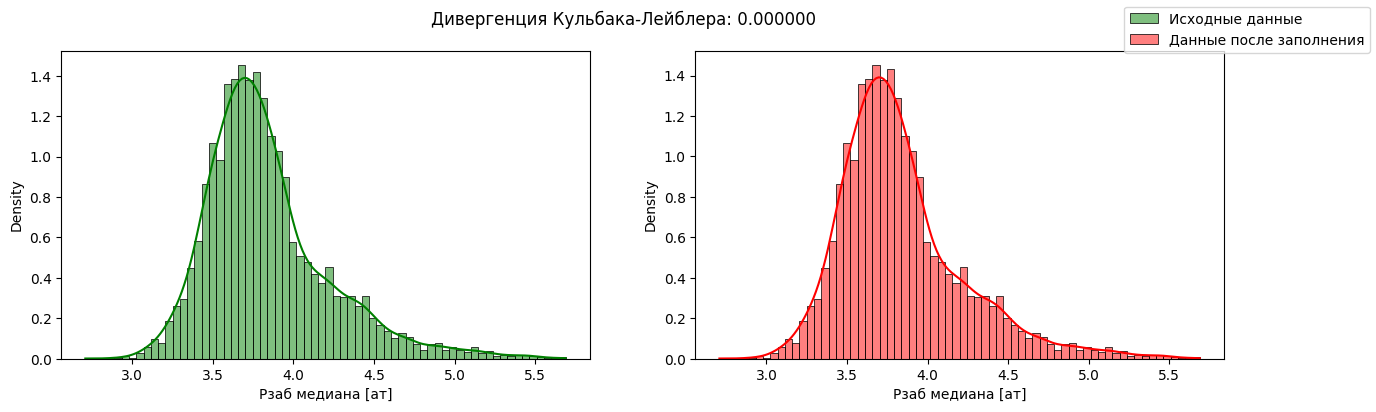

In [93]:
x_t = numeric_train[nan_columns[6]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [94]:
fillna_rule[nan_columns[6]] = x_t.mean()

-----------

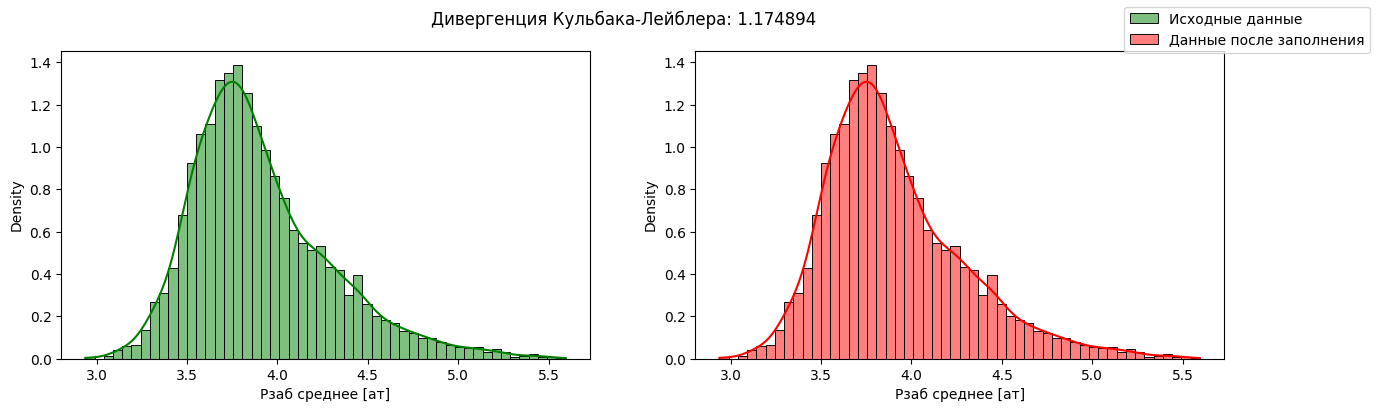

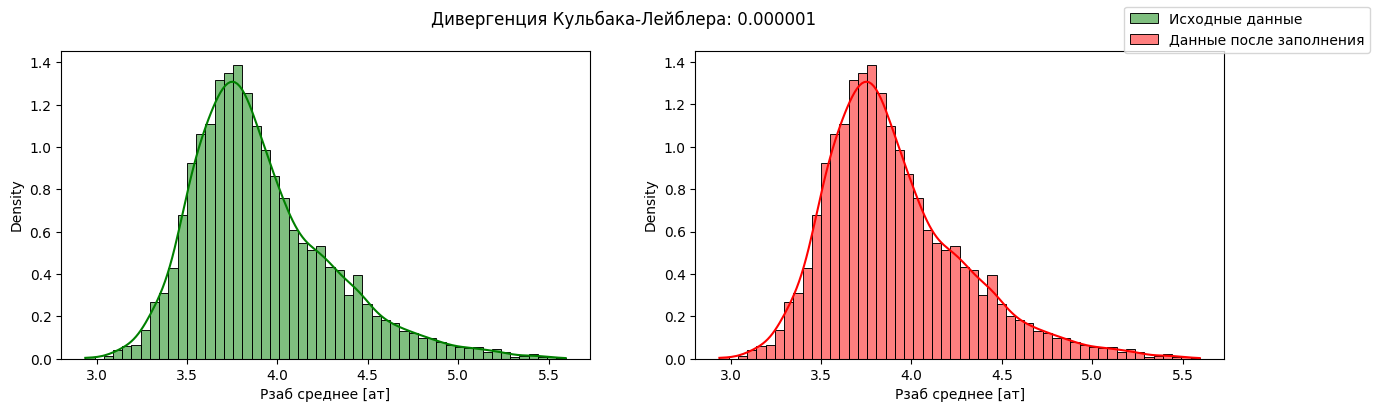

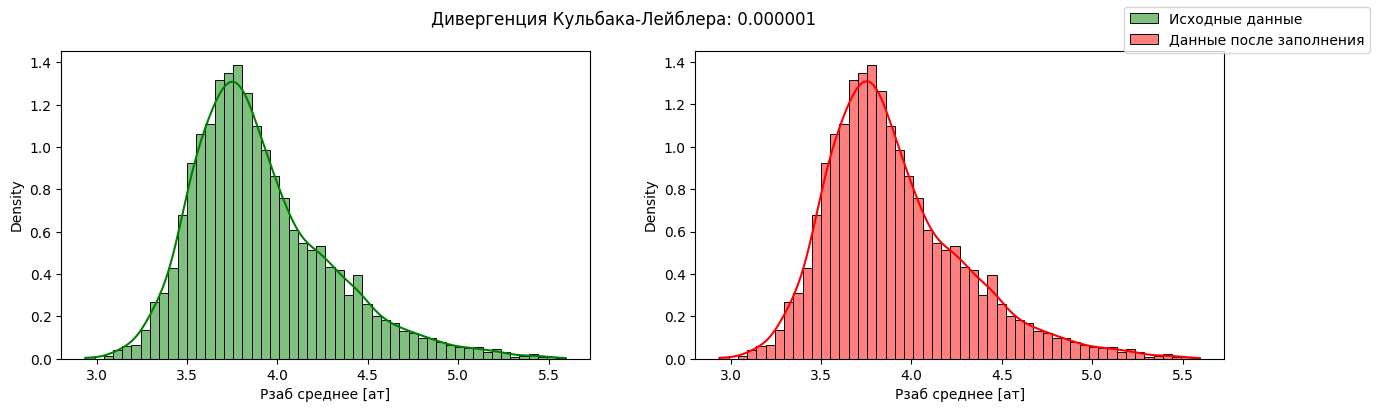

In [95]:
x_t = numeric_train[nan_columns[7]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [96]:
fillna_rule[nan_columns[7]] = x_t.median()

-----------

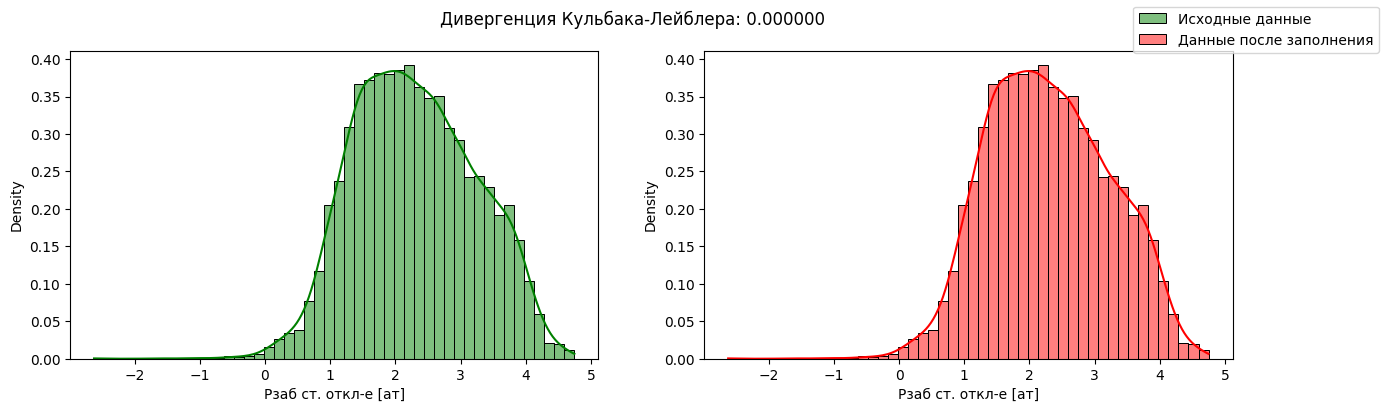

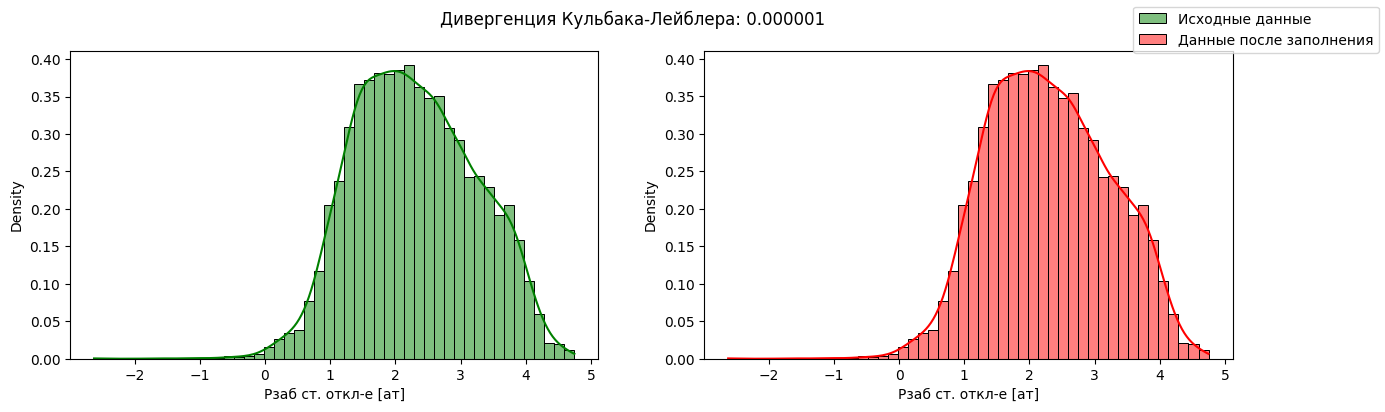

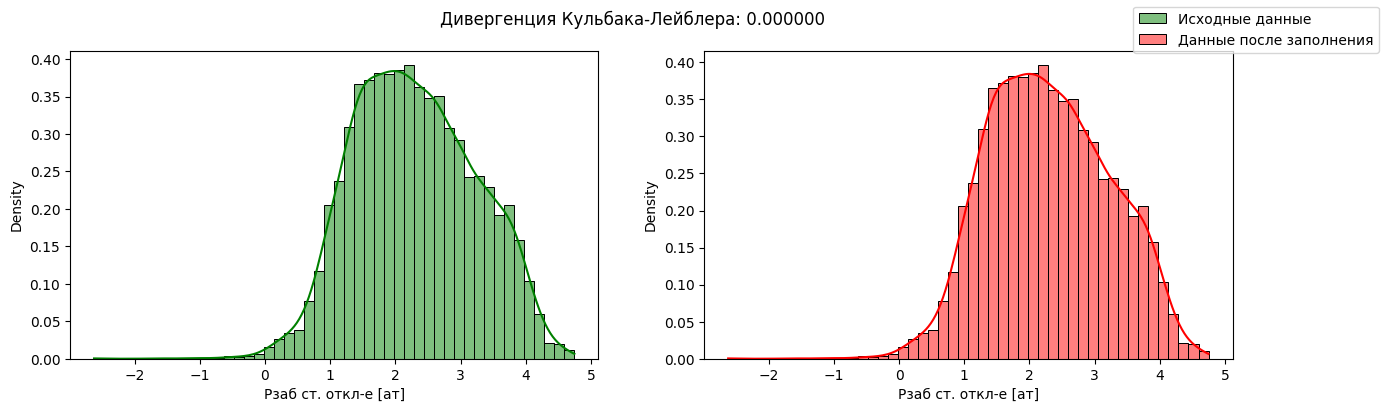

In [97]:
x_t = numeric_train[nan_columns[8]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [98]:
fillna_rule[nan_columns[8]] = x_t.median()

-----------

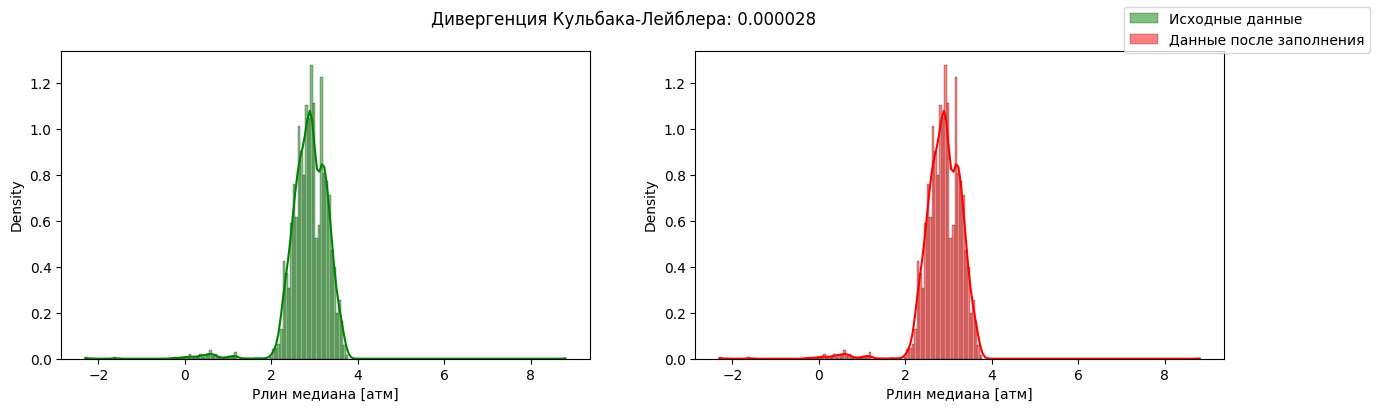

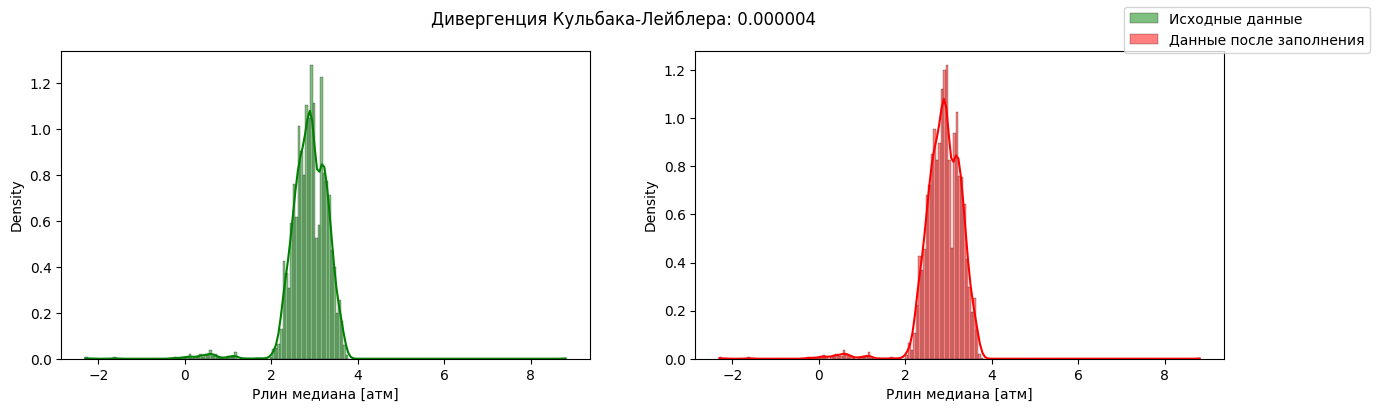

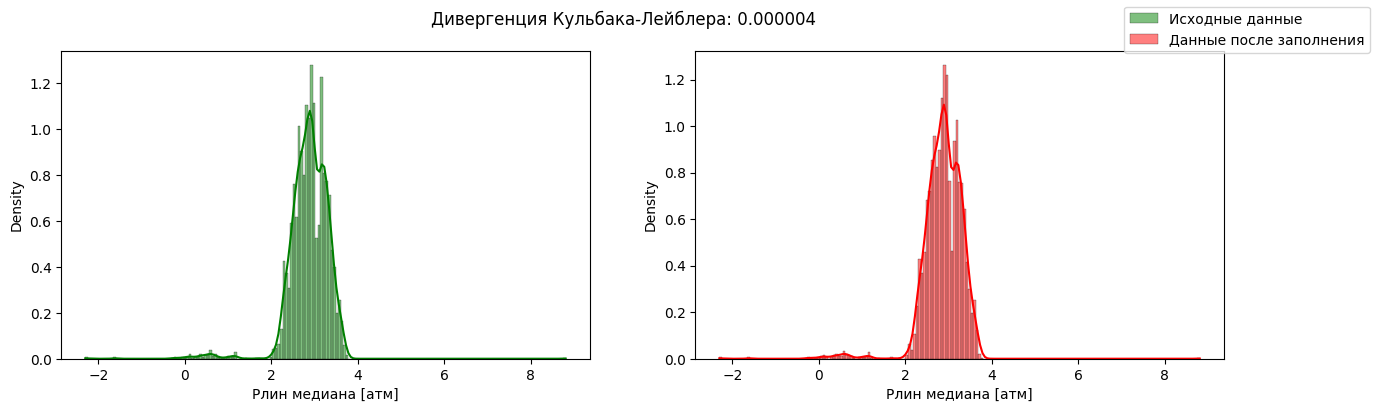

In [99]:
x_t = numeric_train[nan_columns[9]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [100]:
fillna_rule[nan_columns[9]] = x_t.median()

-----------

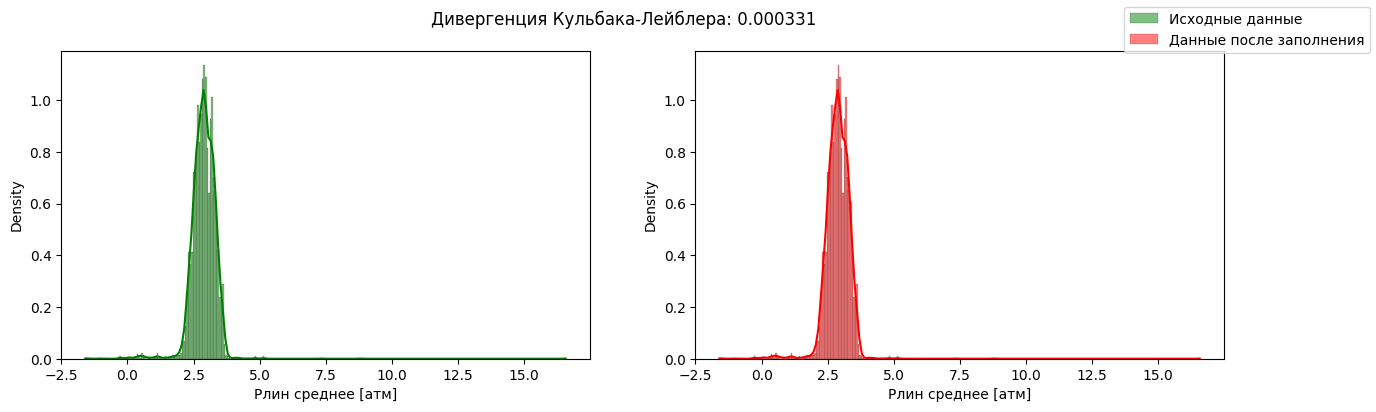

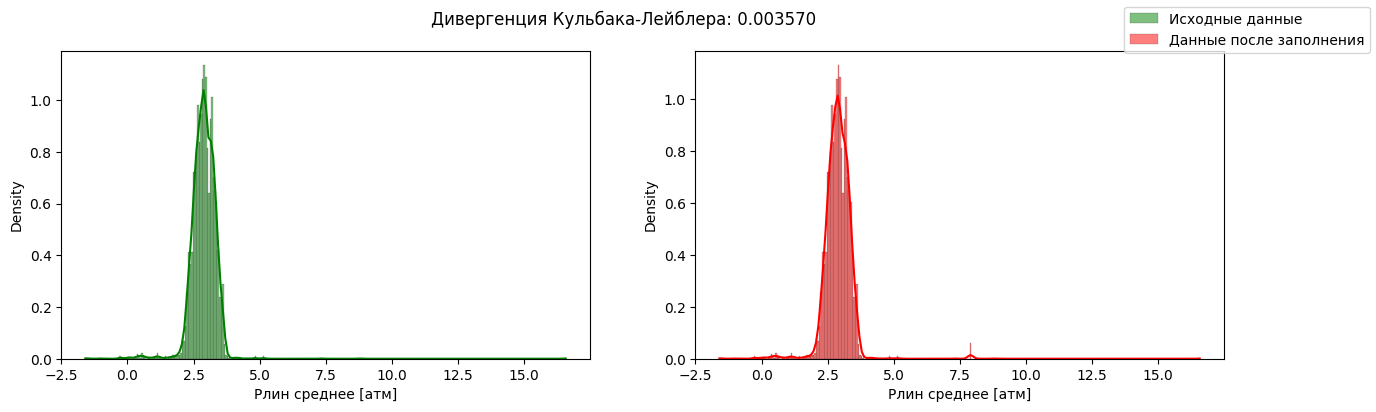

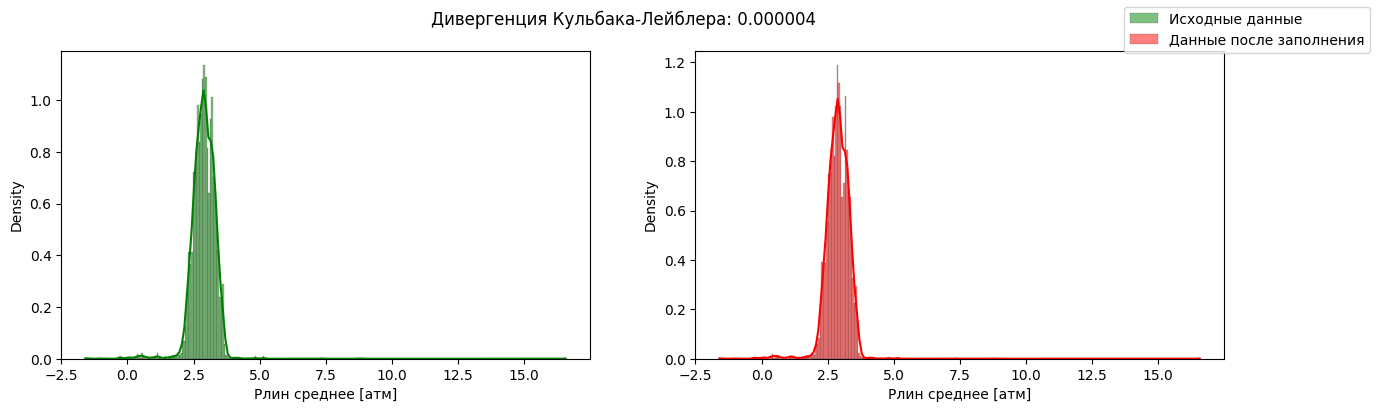

In [101]:
x_t = numeric_train[nan_columns[10]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [102]:
fillna_rule[nan_columns[10]] = x_t.median()

-----------

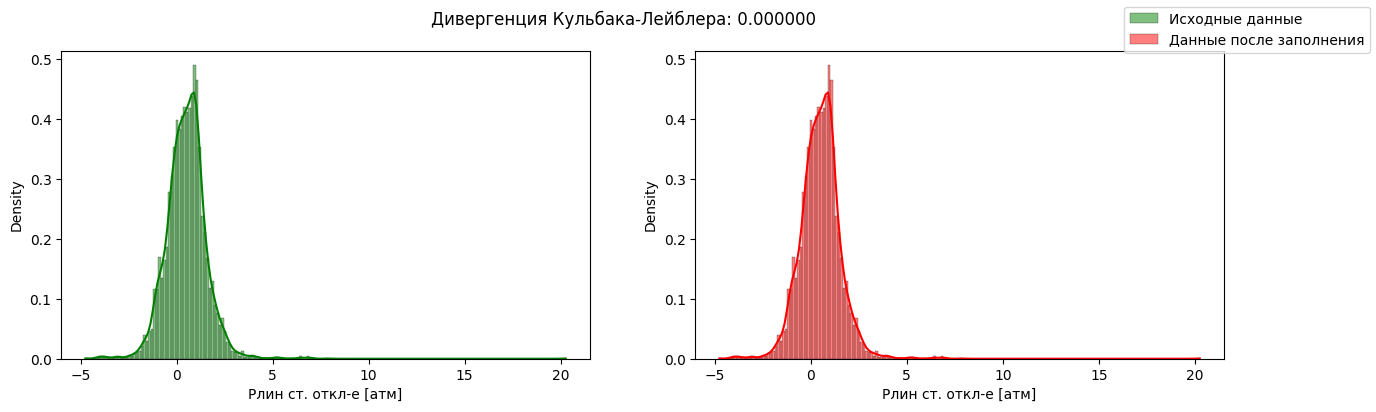

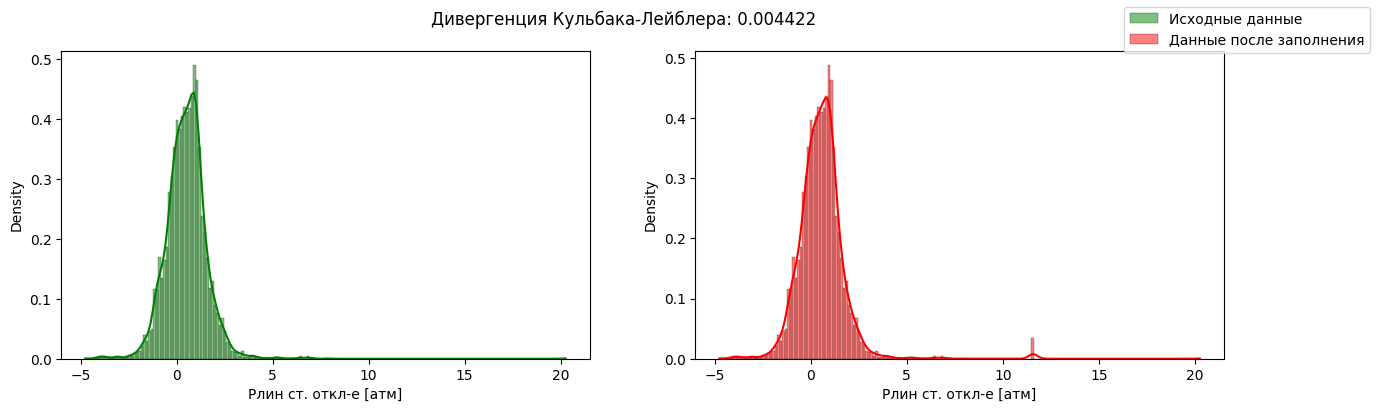

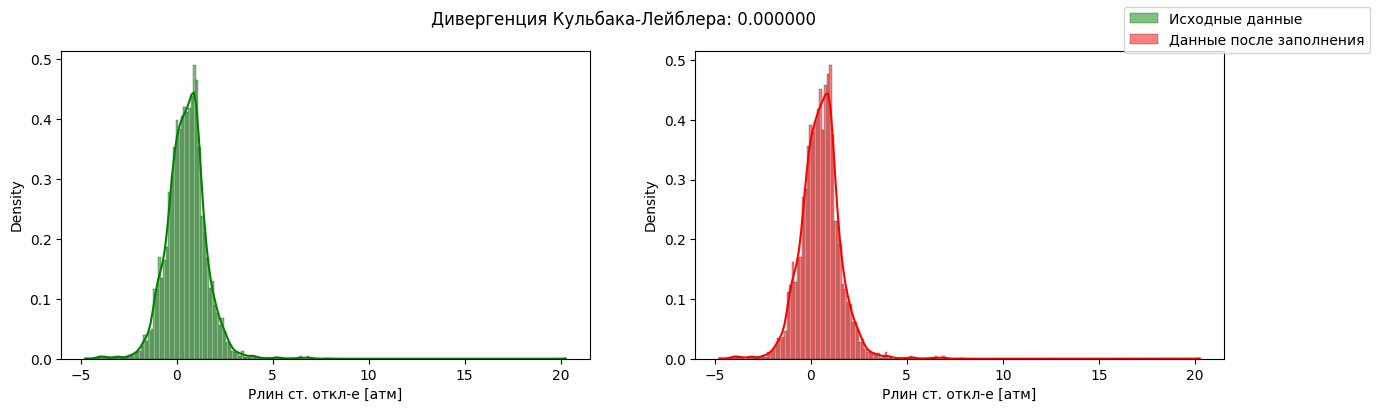

In [103]:
x_t = numeric_train[nan_columns[11]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [104]:
fillna_rule[nan_columns[11]] = x_t.median()

-----------

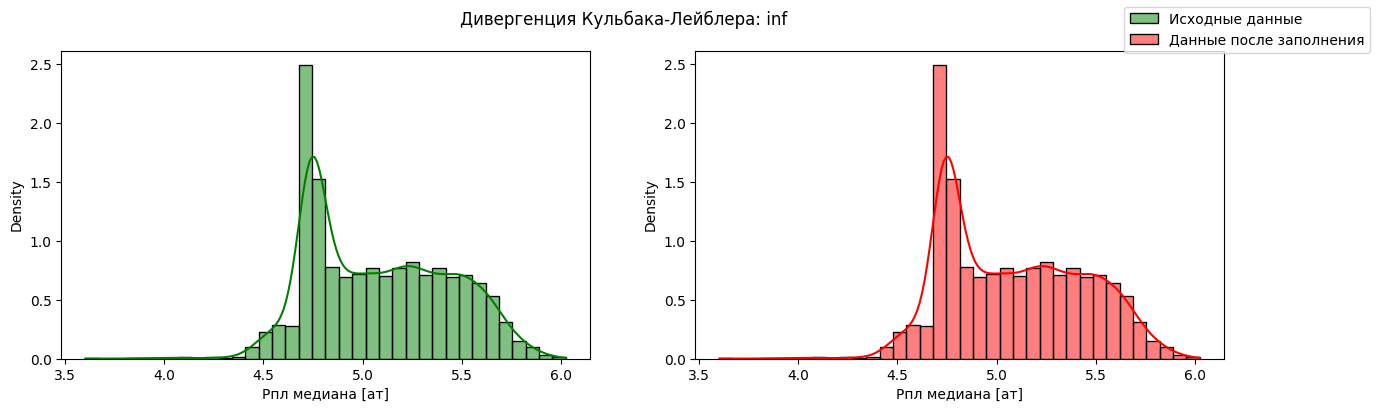

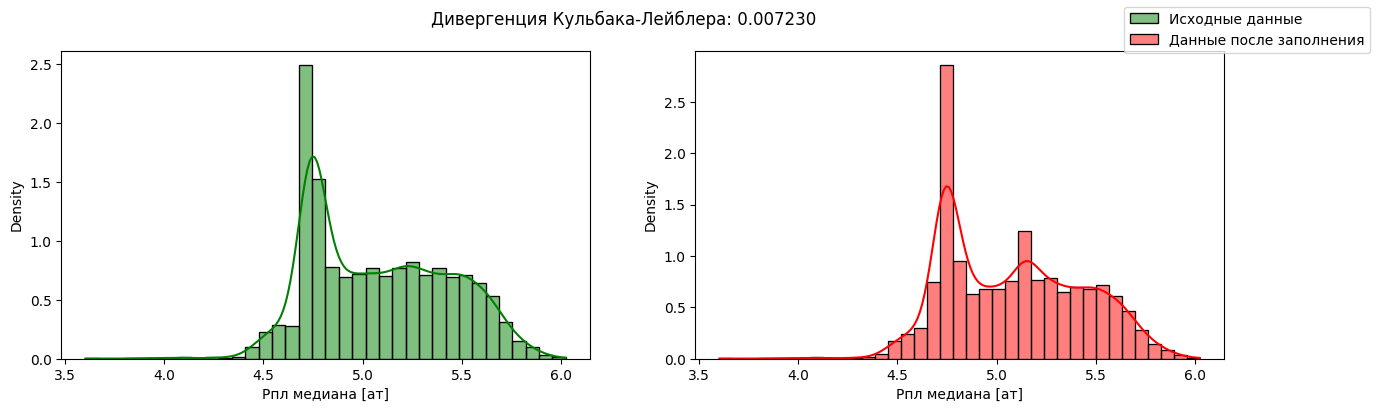

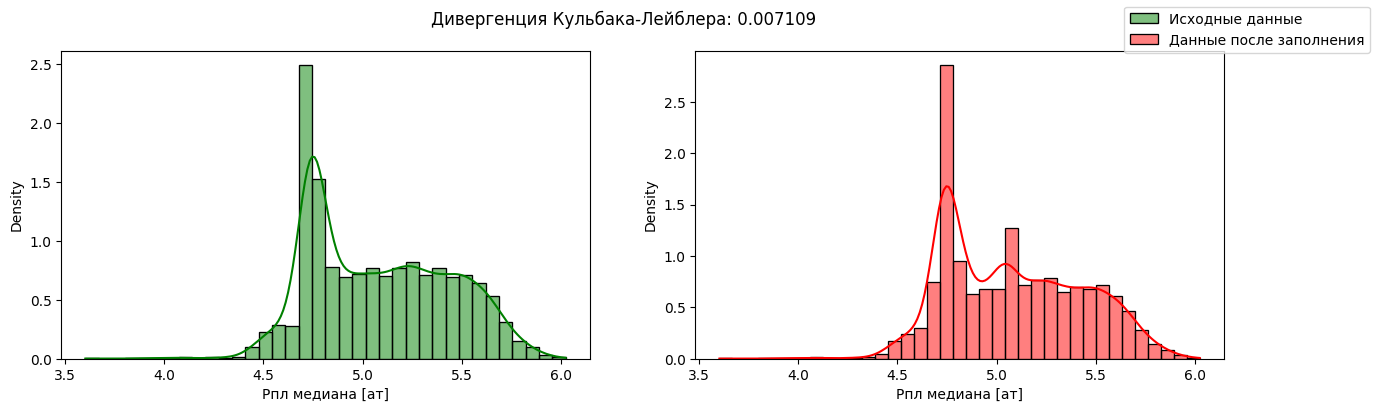

In [105]:
x_t = numeric_train[nan_columns[12]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [106]:
fillna_rule[nan_columns[12]] = x_t.median()

-----------

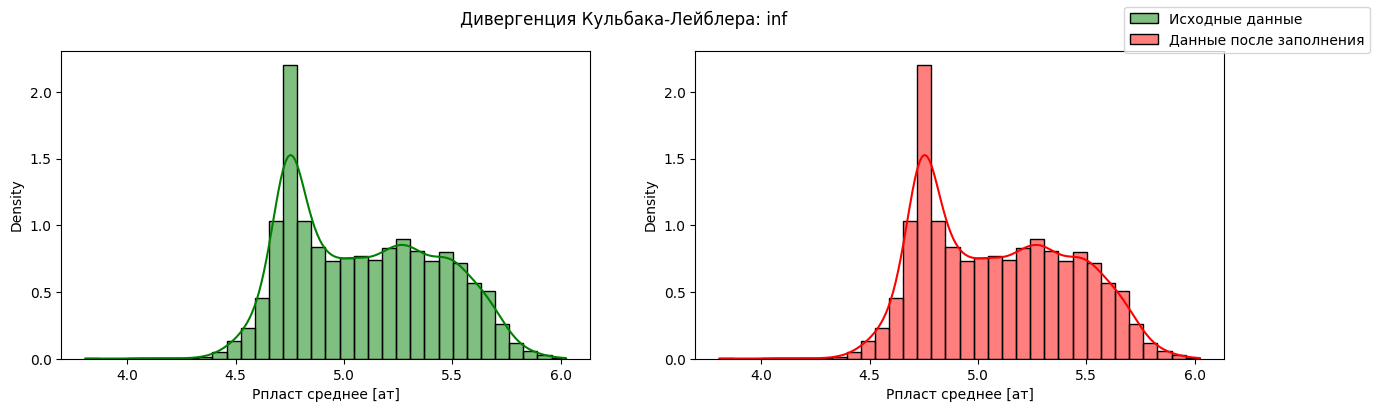

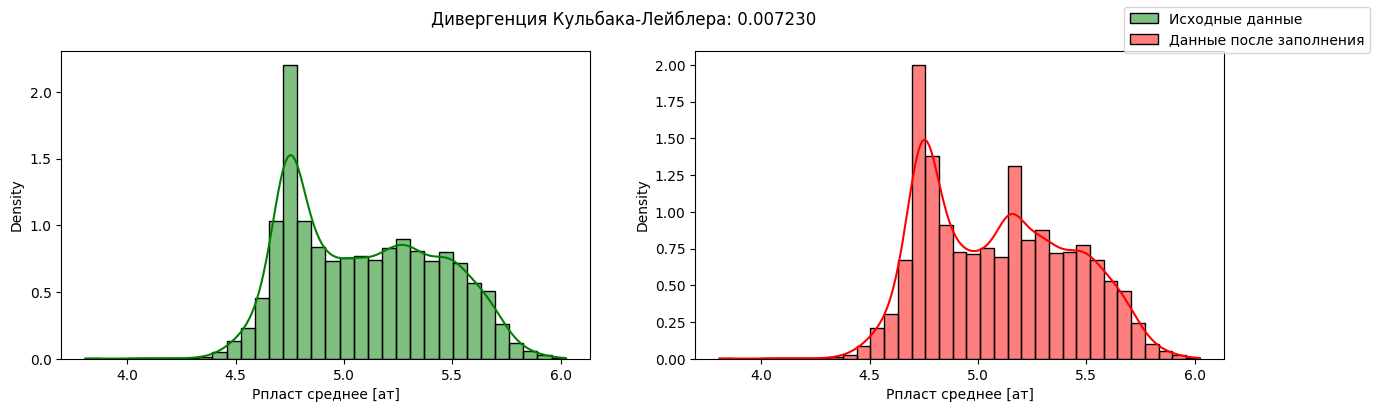

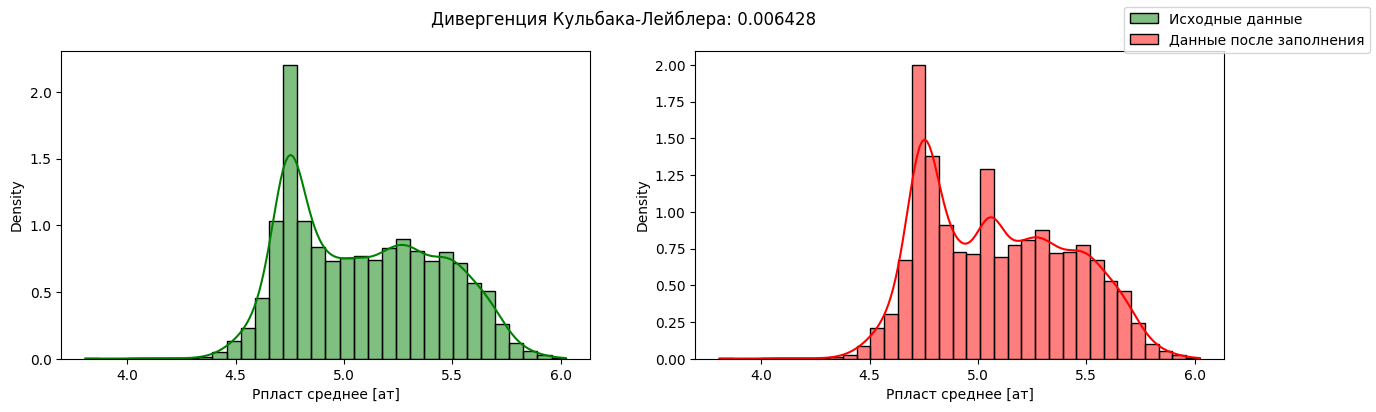

In [107]:
x_t = numeric_train[nan_columns[13]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [108]:
fillna_rule[nan_columns[13]] = x_t.median()

-----------

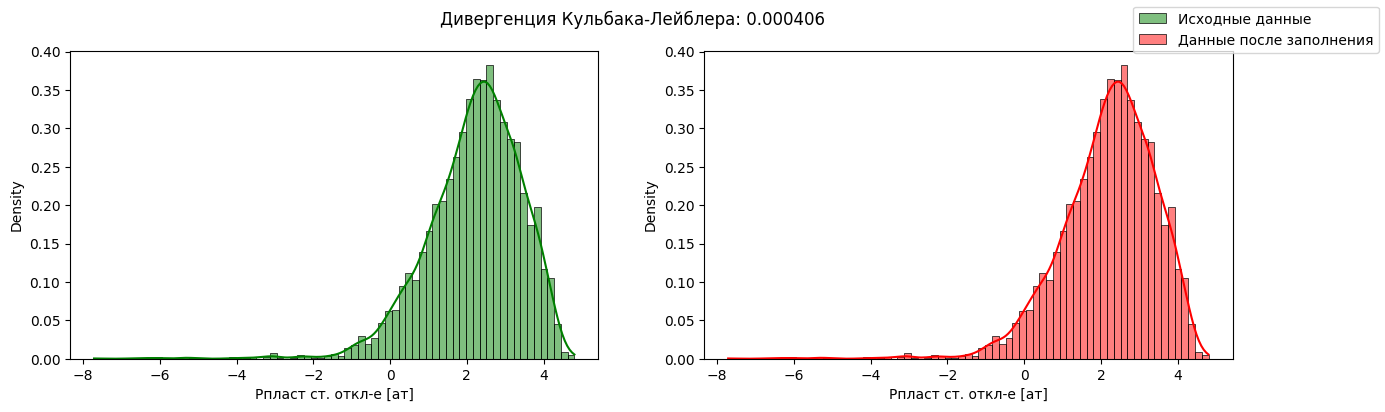

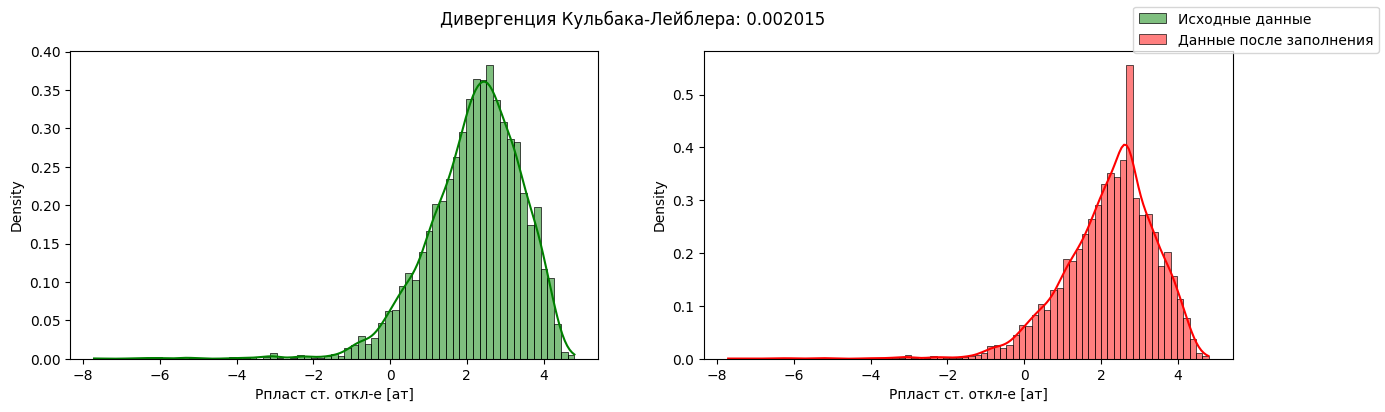

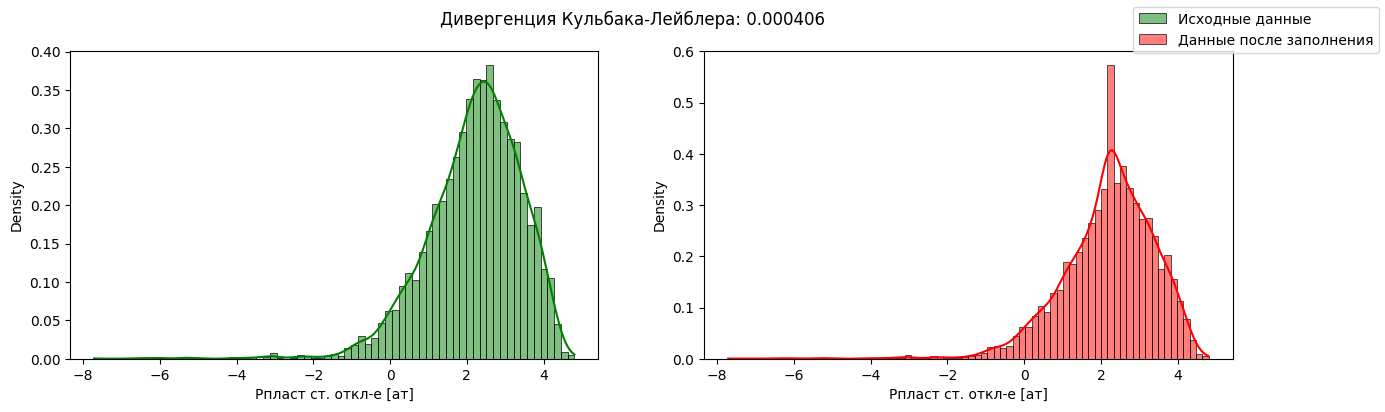

In [109]:
x_t = numeric_train[nan_columns[14]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [110]:
fillna_rule[nan_columns[14]] = x_t.median()

-----------

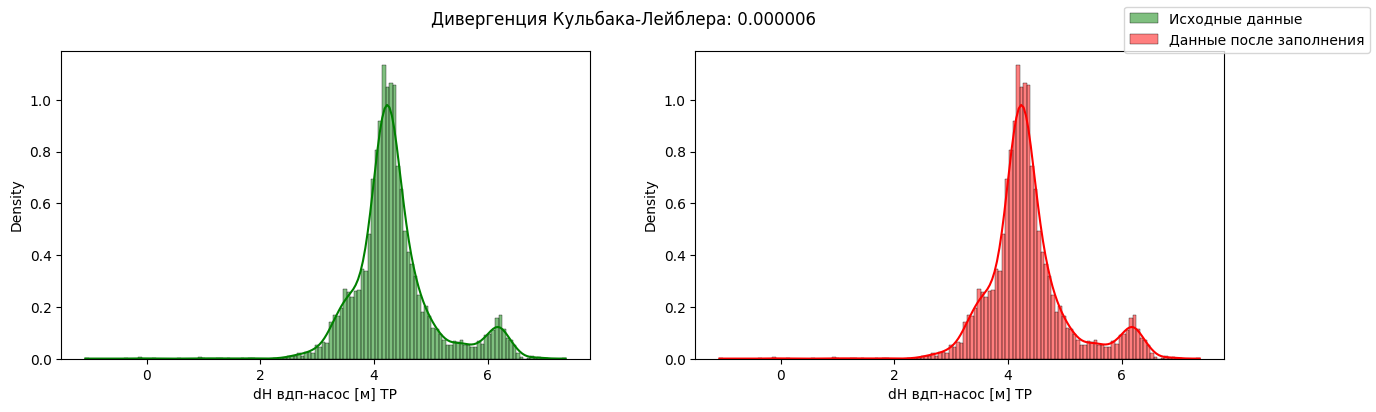

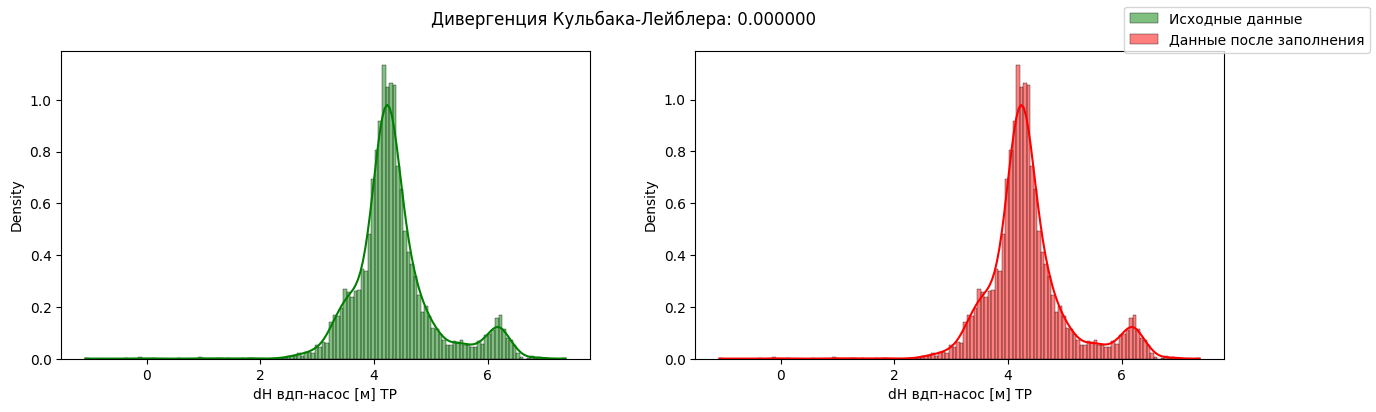

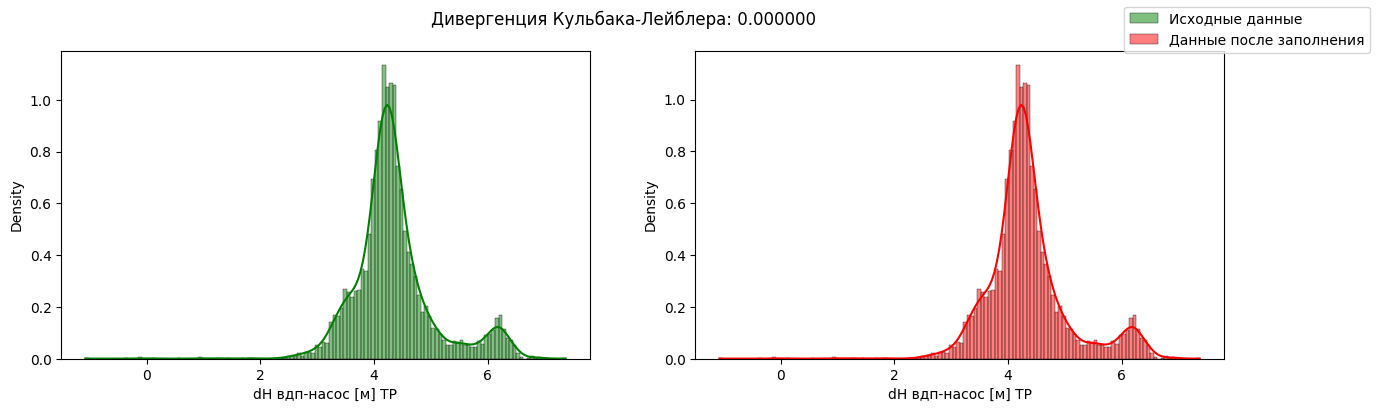

In [111]:
x_t = numeric_train[nan_columns[15]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [112]:
fillna_rule[nan_columns[15]] = x_t.median()

-----------

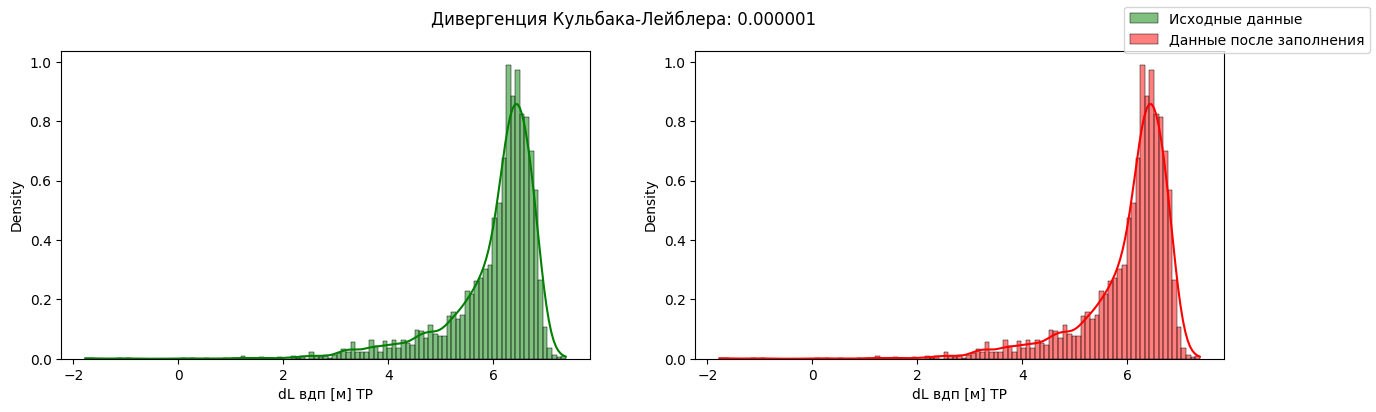

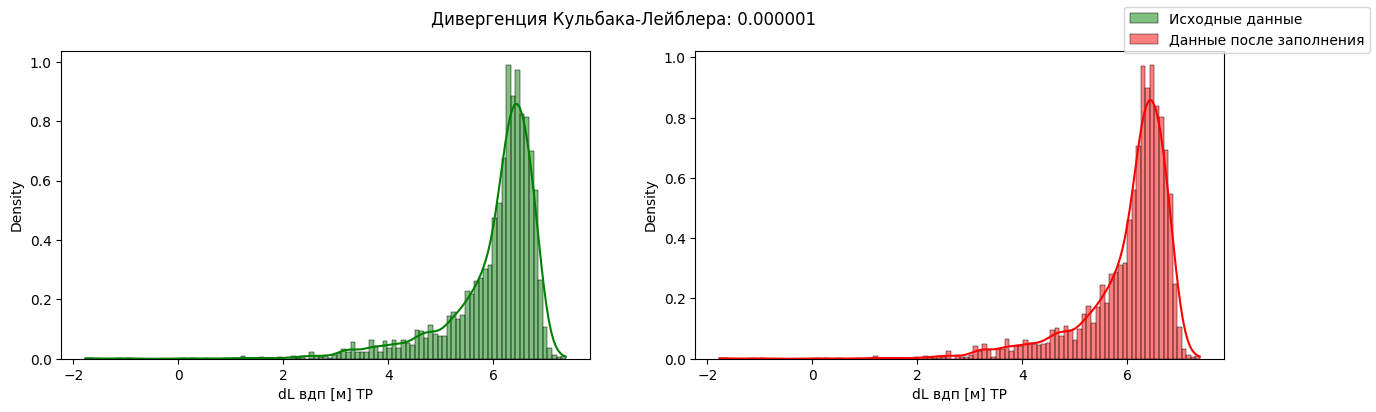

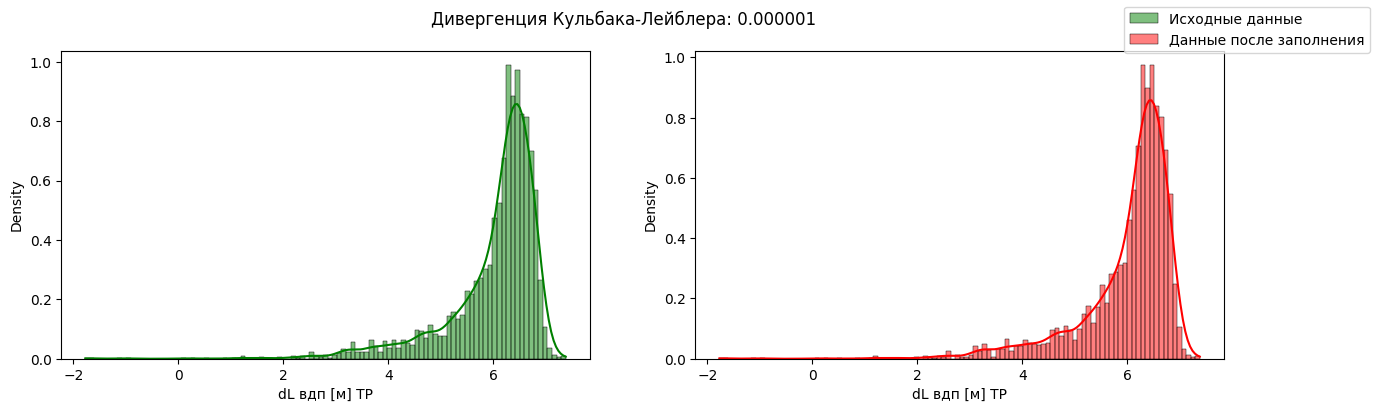

In [113]:
x_t = numeric_train[nan_columns[16]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [114]:
fillna_rule[nan_columns[16]] = x_t.median()

-----------

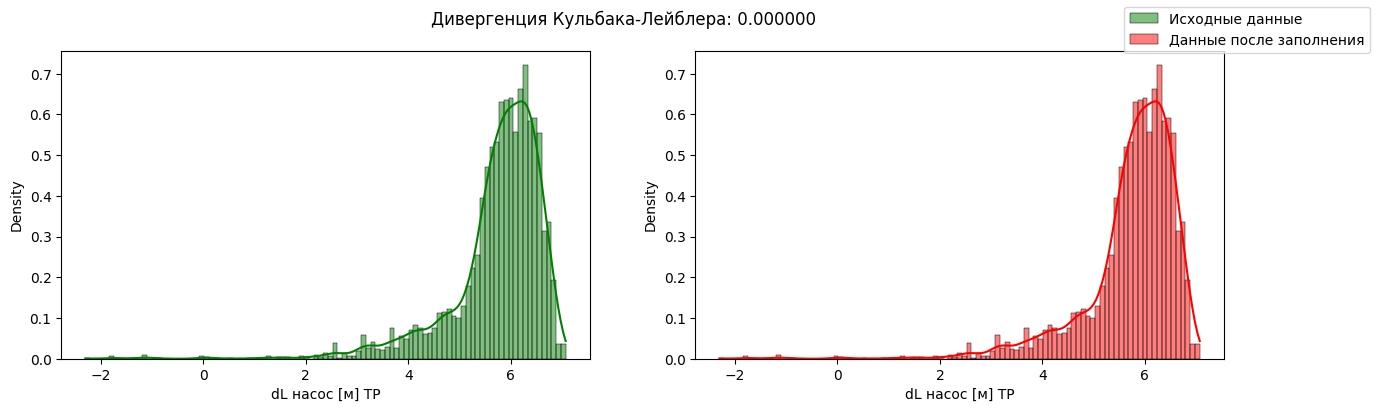

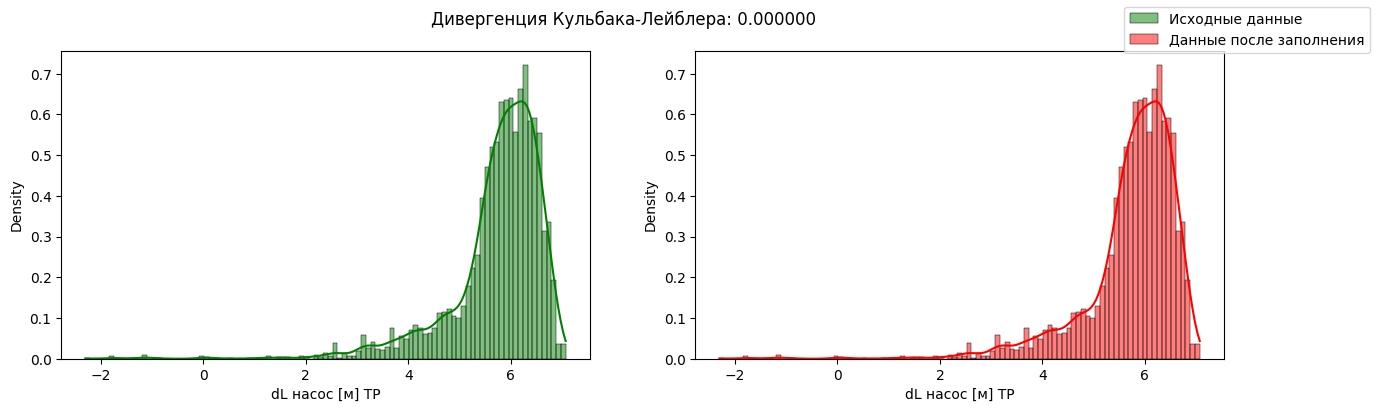

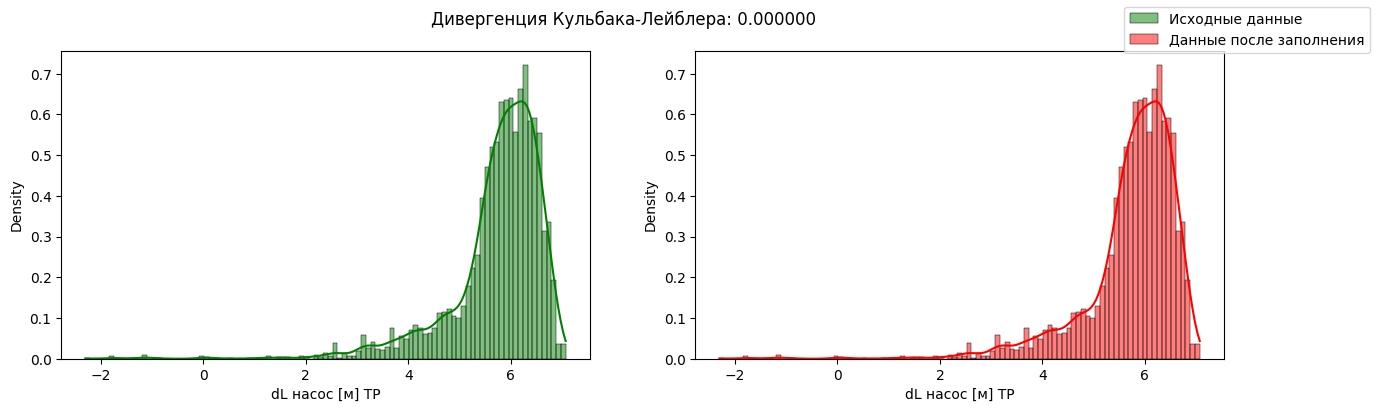

In [115]:
x_t = numeric_train[nan_columns[17]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [116]:
fillna_rule[nan_columns[17]] = x_t.median()

-----------

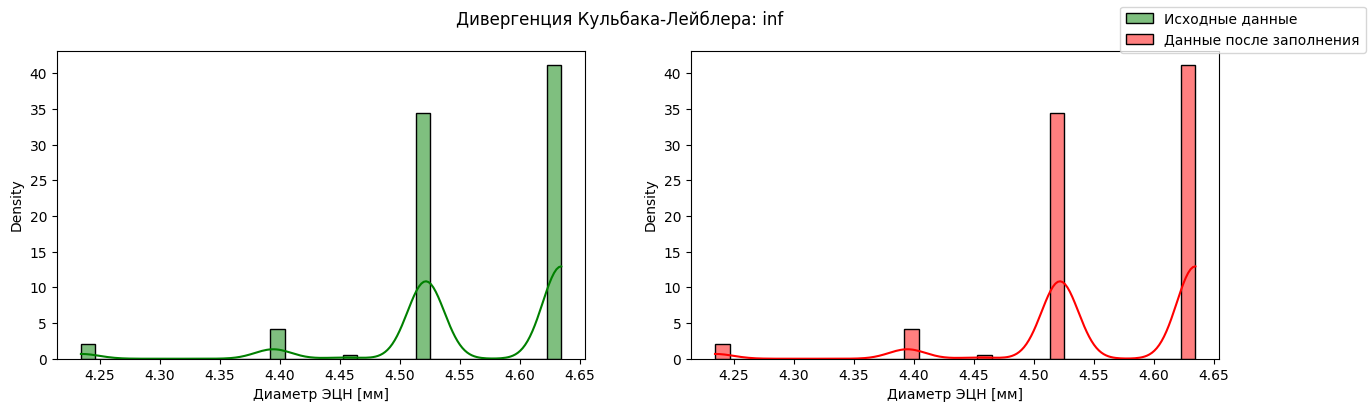

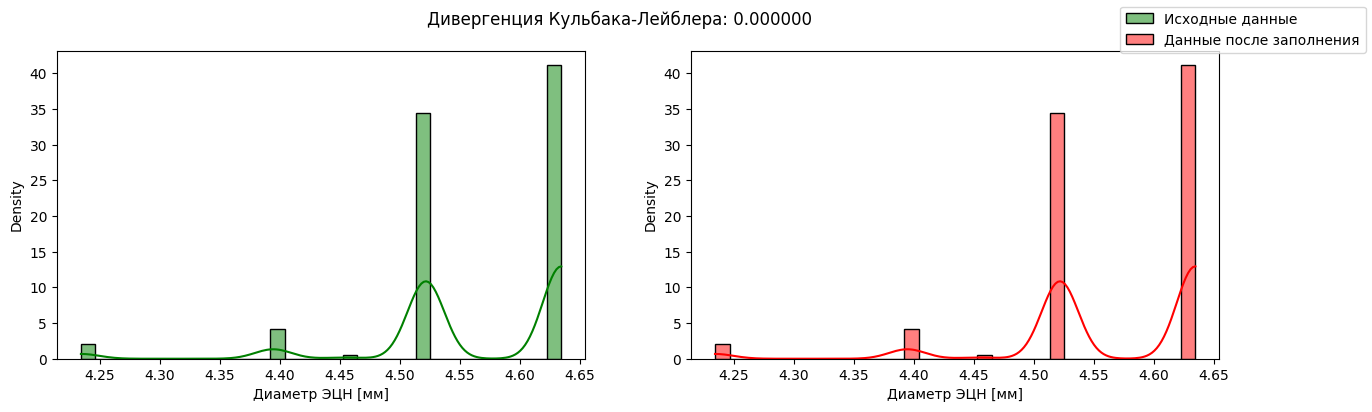

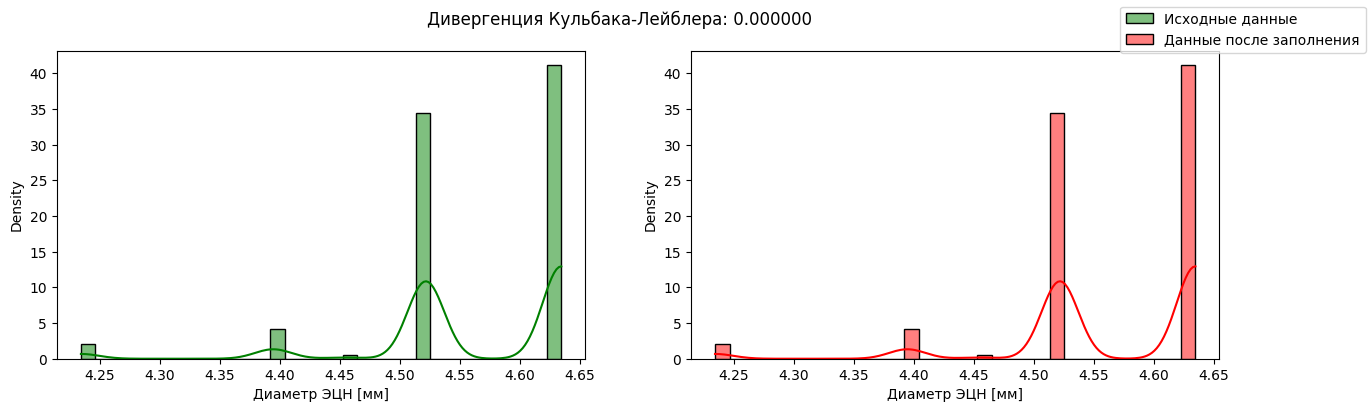

In [117]:
x_t = numeric_train[nan_columns[18]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [118]:
fillna_rule[nan_columns[18]] = x_t.median()

-----------

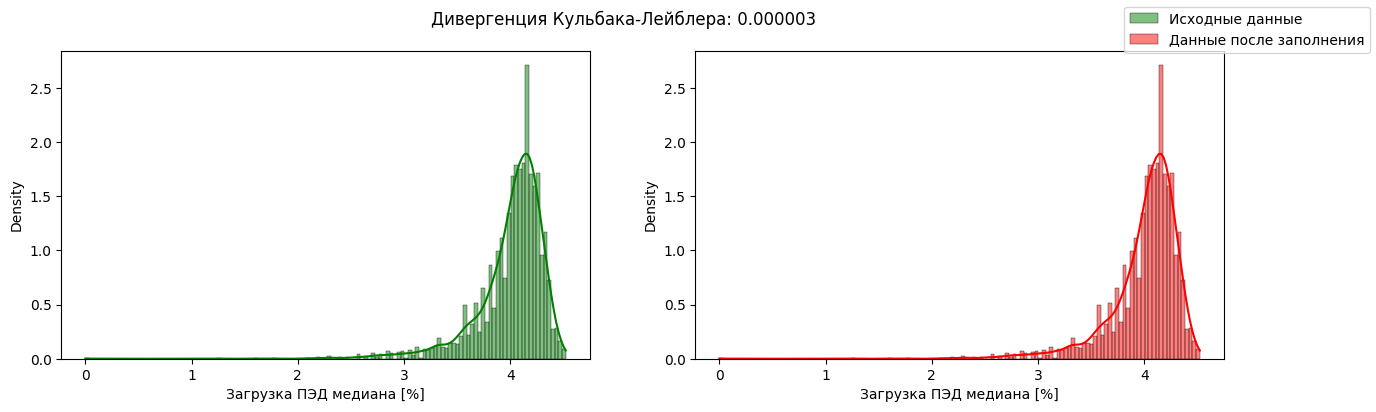

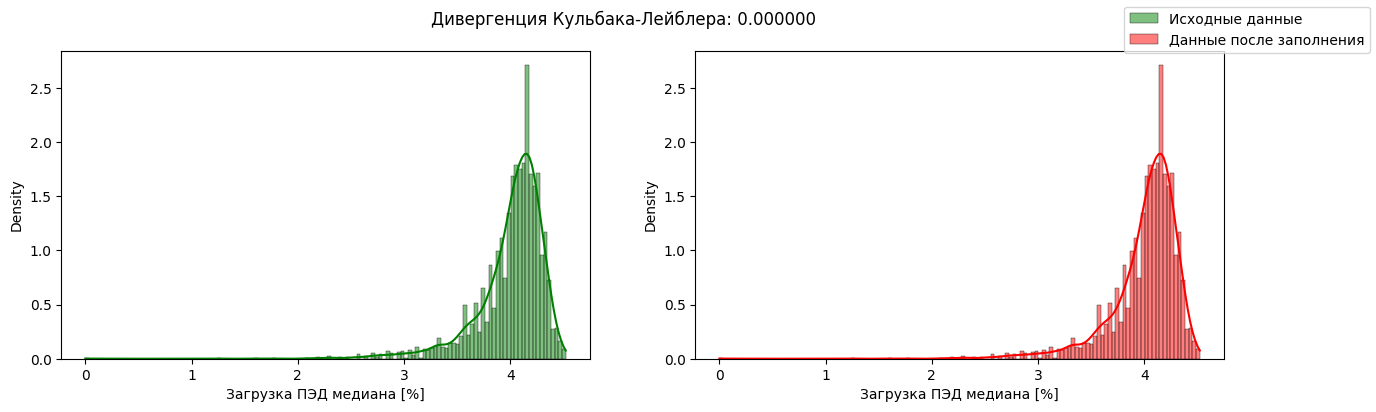

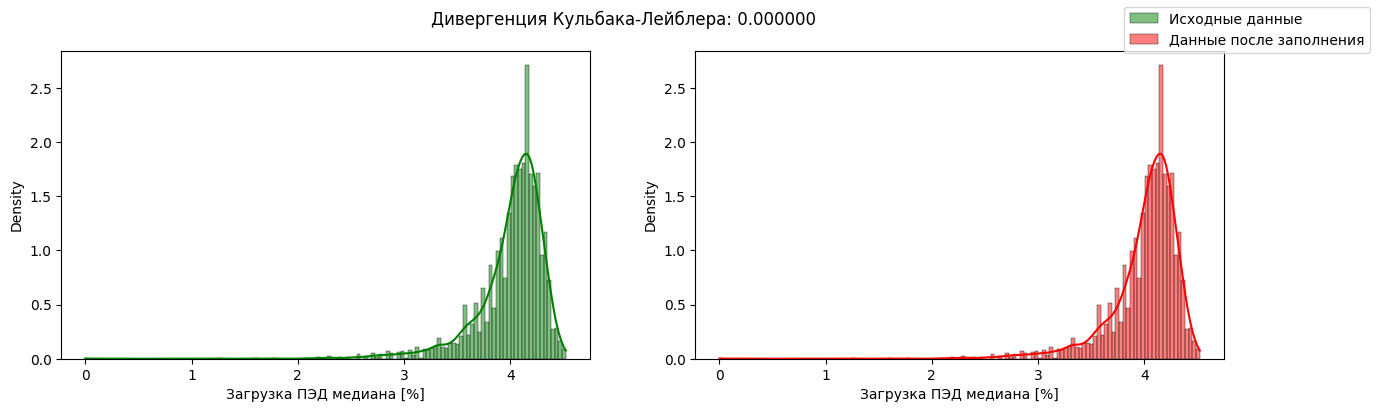

In [119]:
x_t = numeric_train[nan_columns[19]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [120]:
fillna_rule[nan_columns[19]] = x_t.median()

-----------

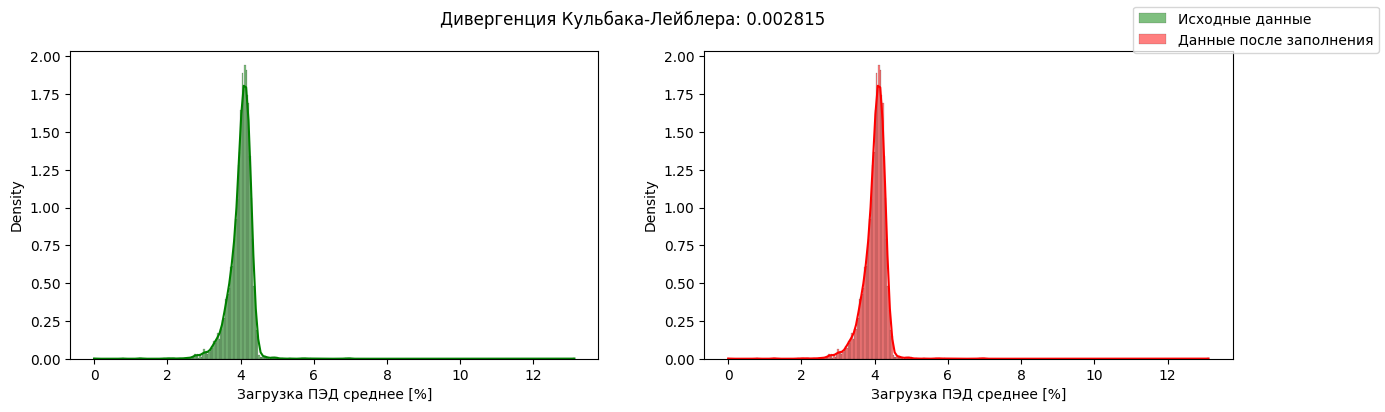

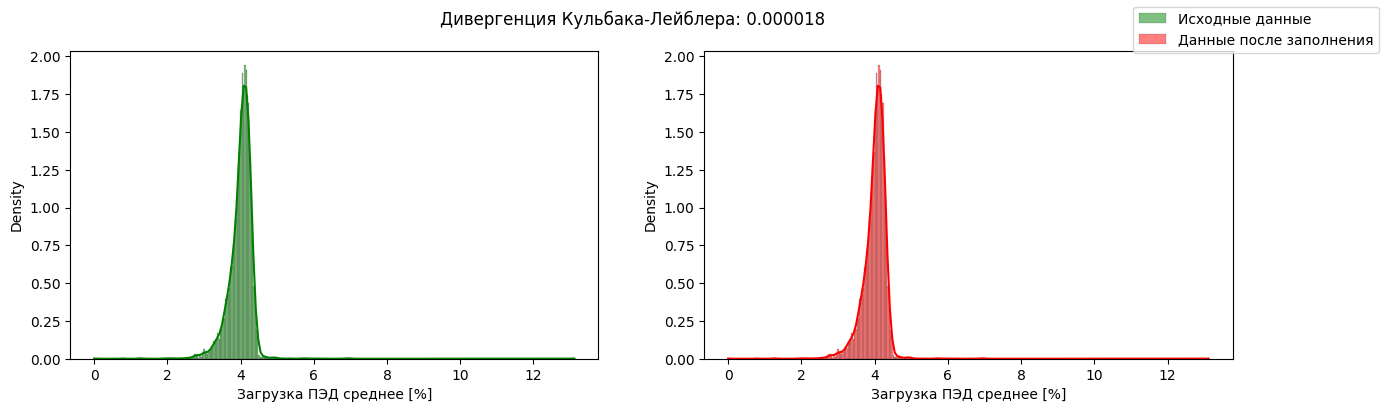

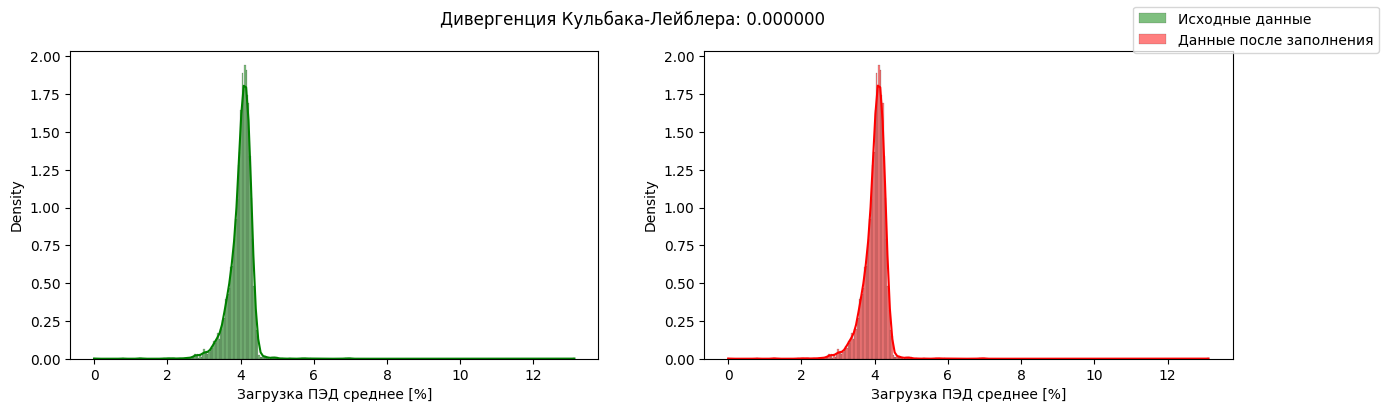

In [121]:
x_t = numeric_train[nan_columns[20]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [122]:
fillna_rule[nan_columns[20]] = x_t.median()

-----------

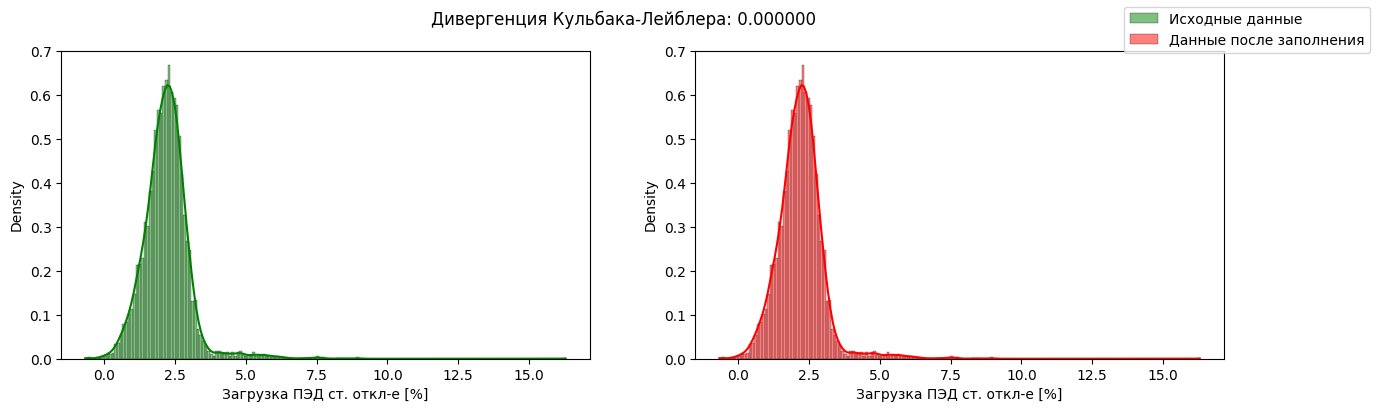

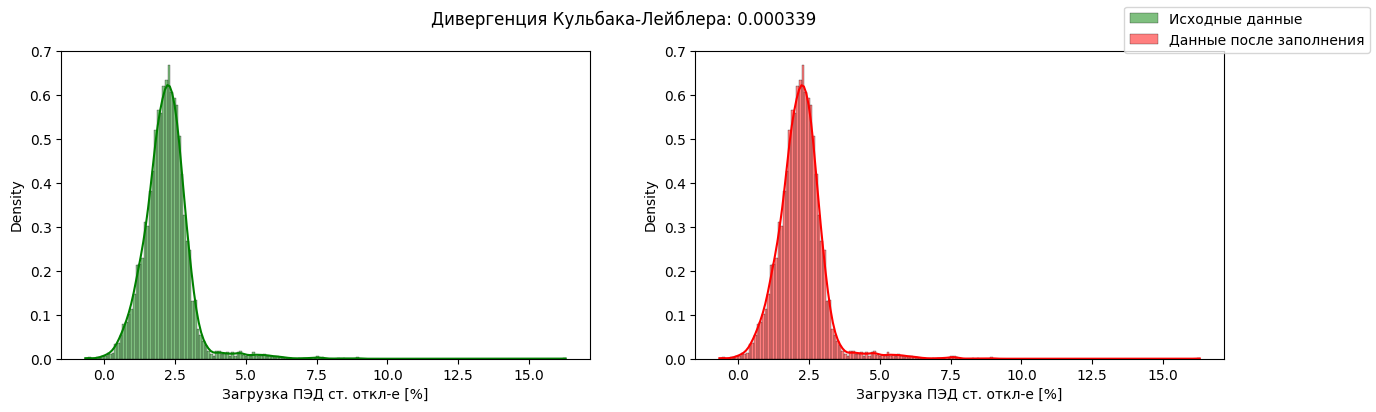

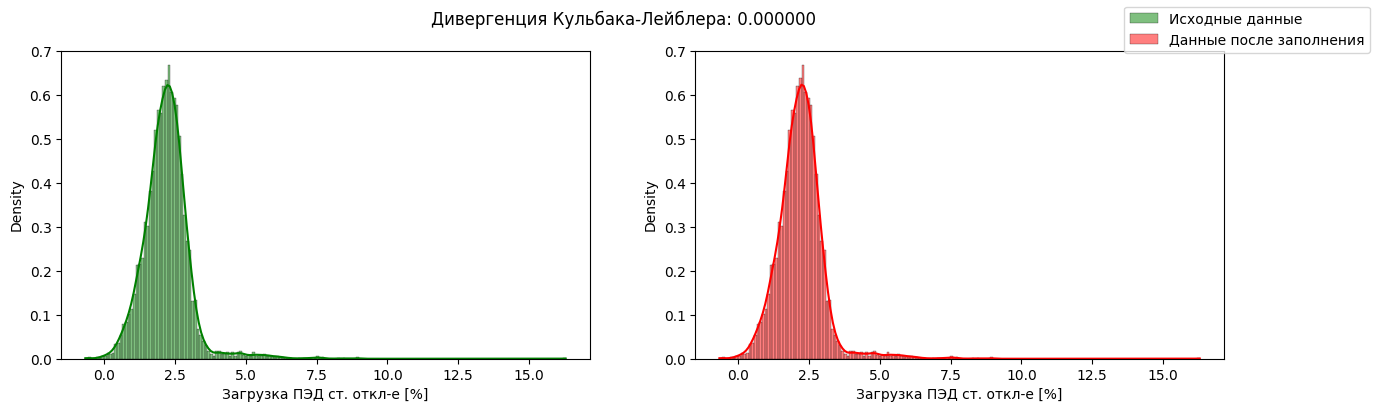

In [123]:
x_t = numeric_train[nan_columns[21]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [124]:
fillna_rule[nan_columns[21]] = x_t.median()

-----------

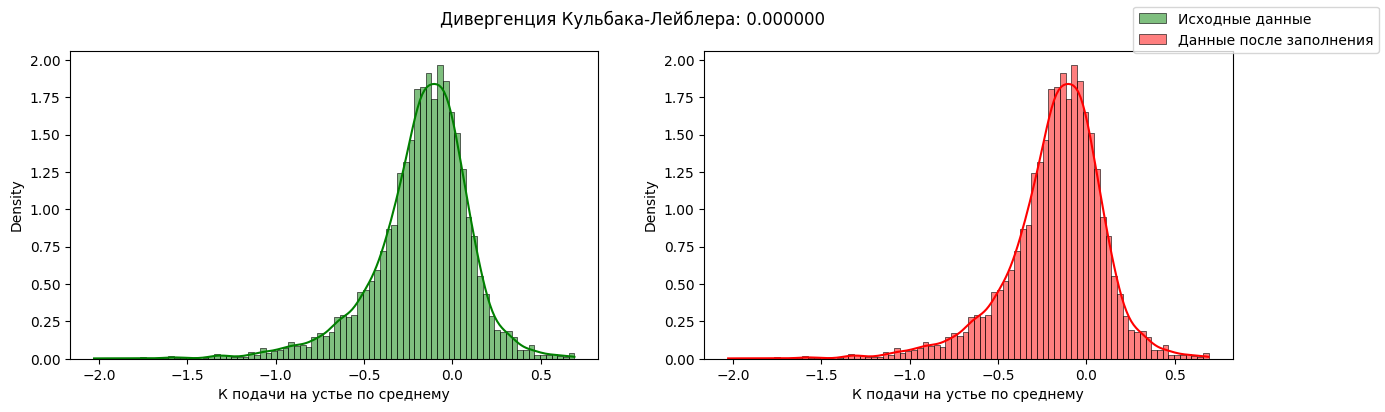

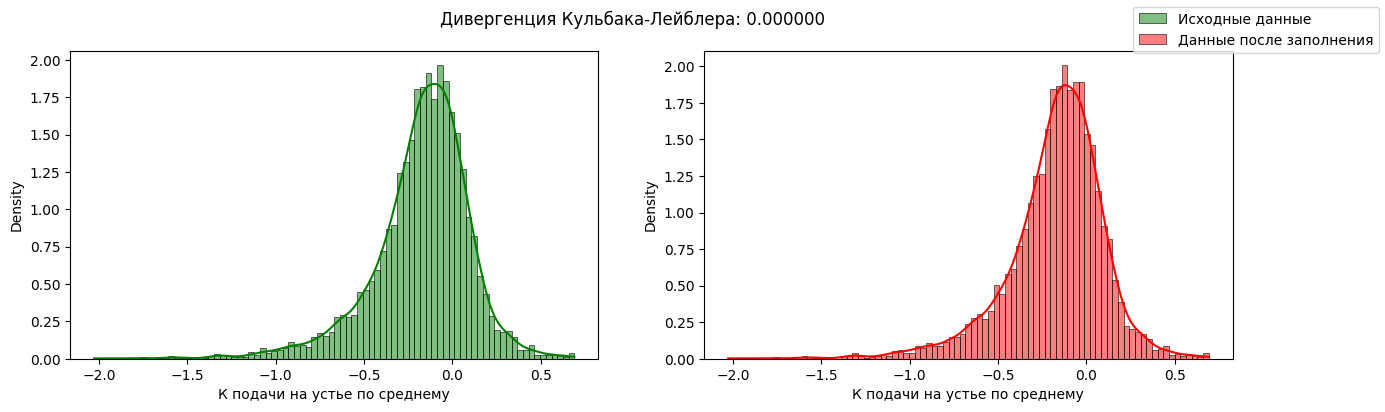

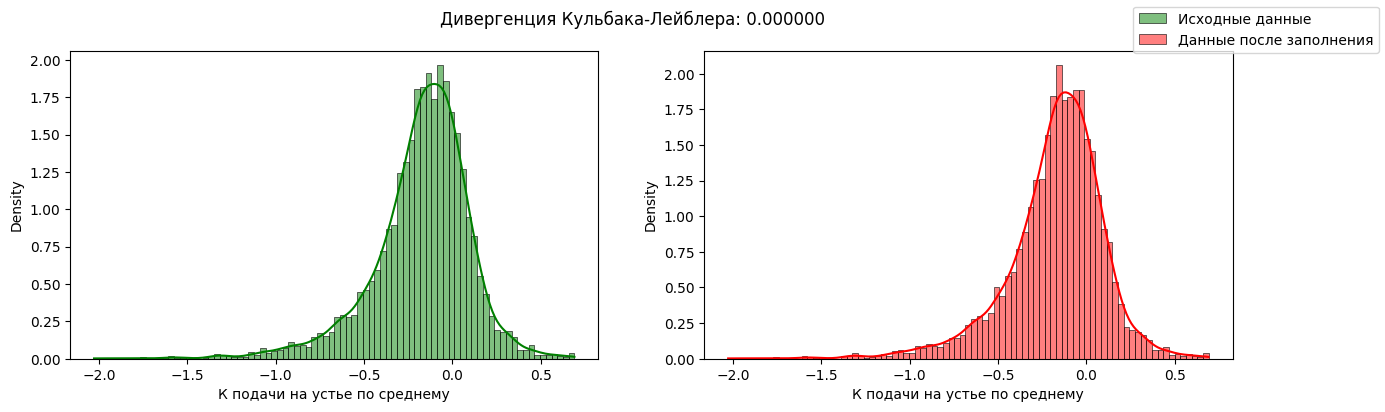

In [125]:
x_t = numeric_train[nan_columns[22]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [126]:
fillna_rule[nan_columns[22]] = x_t.median()

-----------

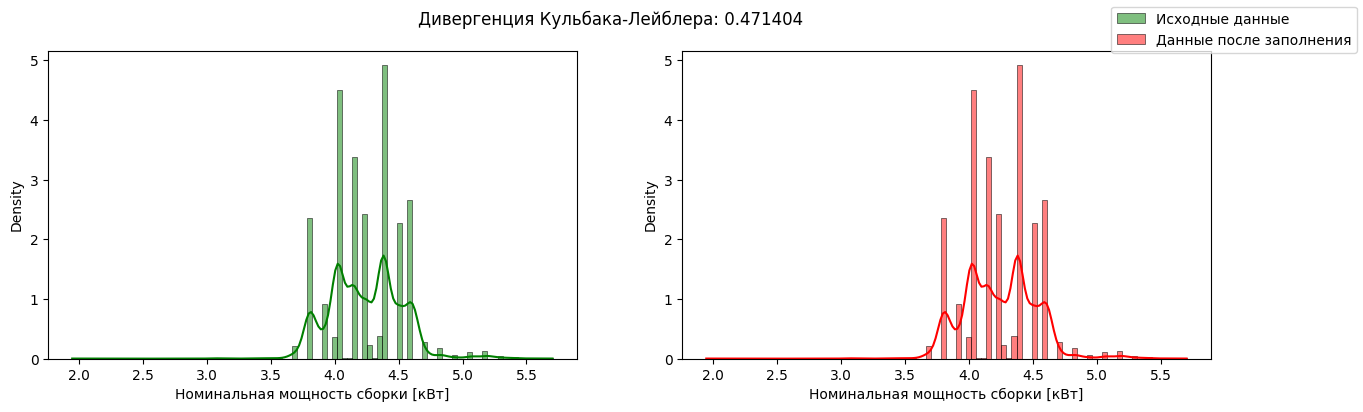

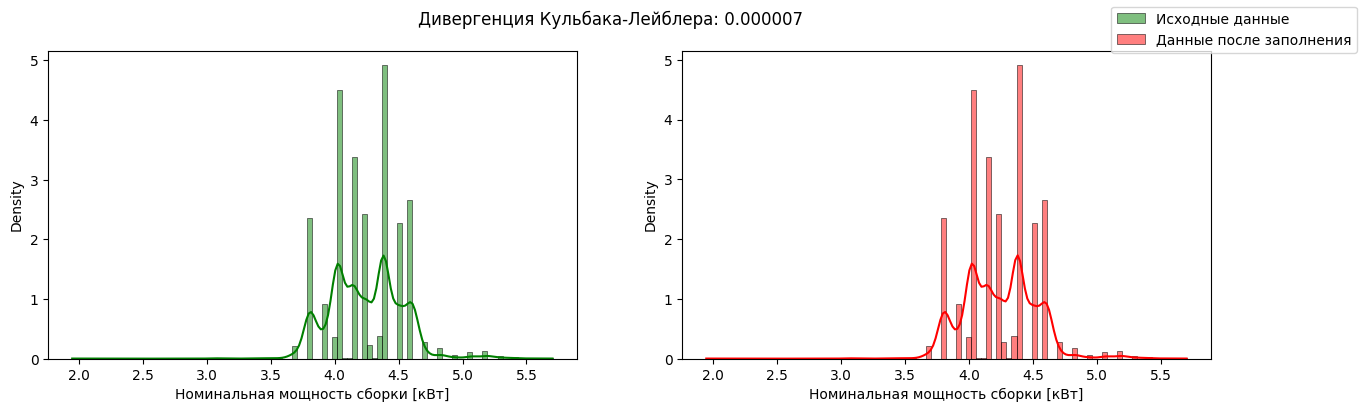

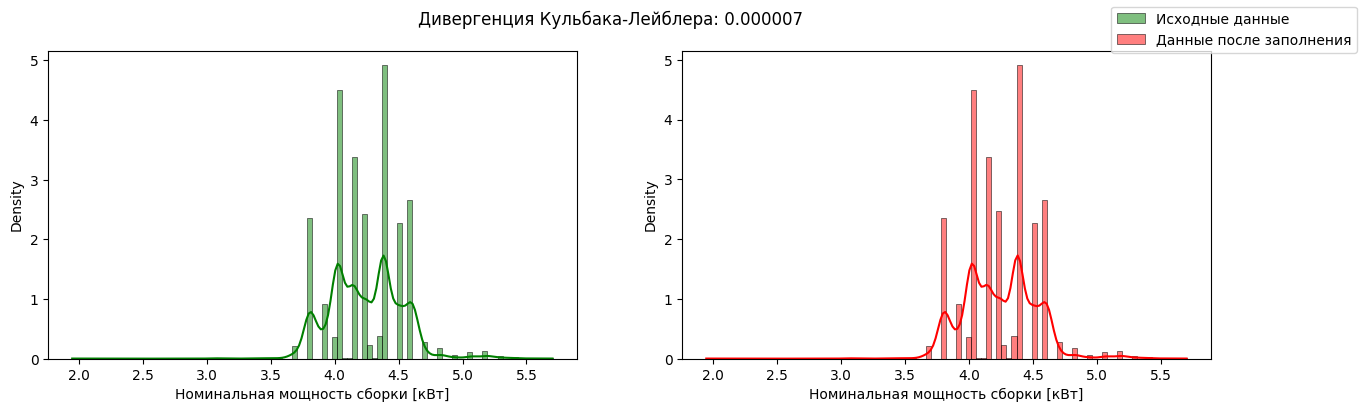

In [127]:
x_t = numeric_train[nan_columns[23]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [128]:
fillna_rule[nan_columns[23]] = x_t.median()

-----------

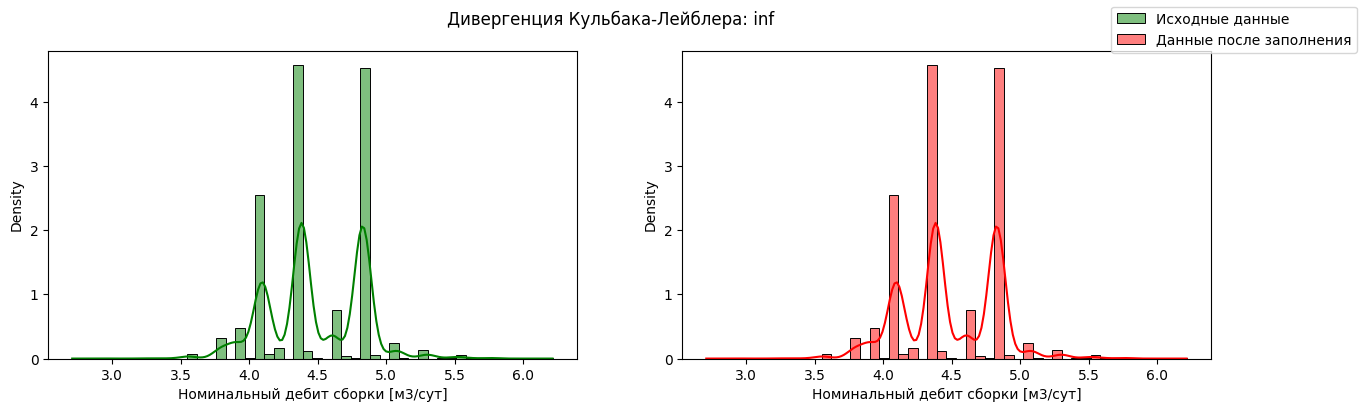

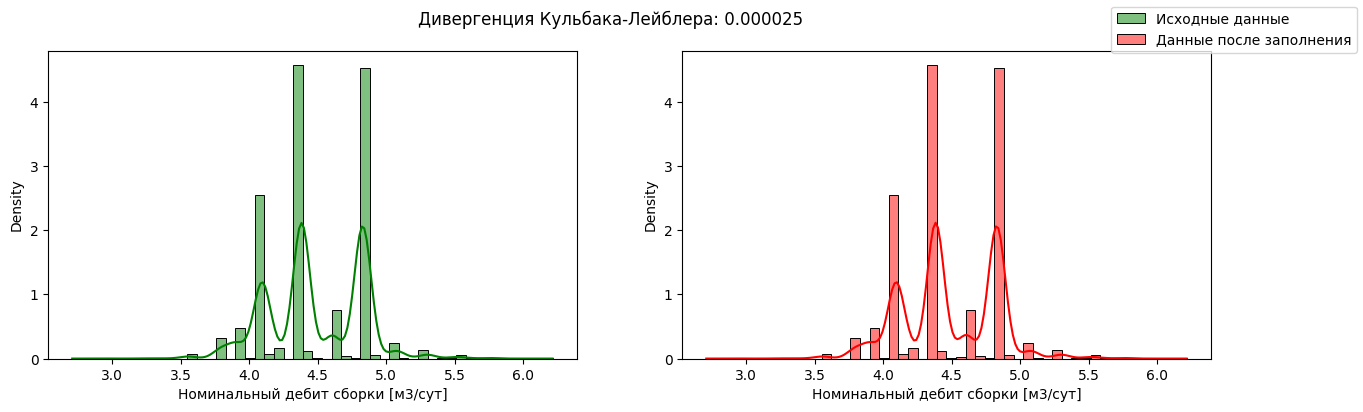

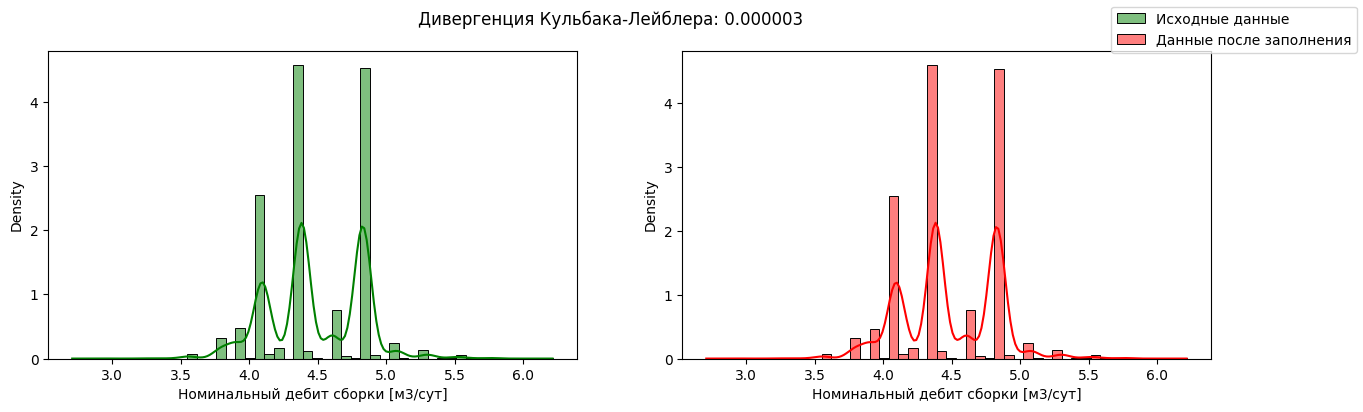

In [129]:
x_t = numeric_train[nan_columns[24]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [130]:
fillna_rule[nan_columns[24]] = x_t.median()

-----------

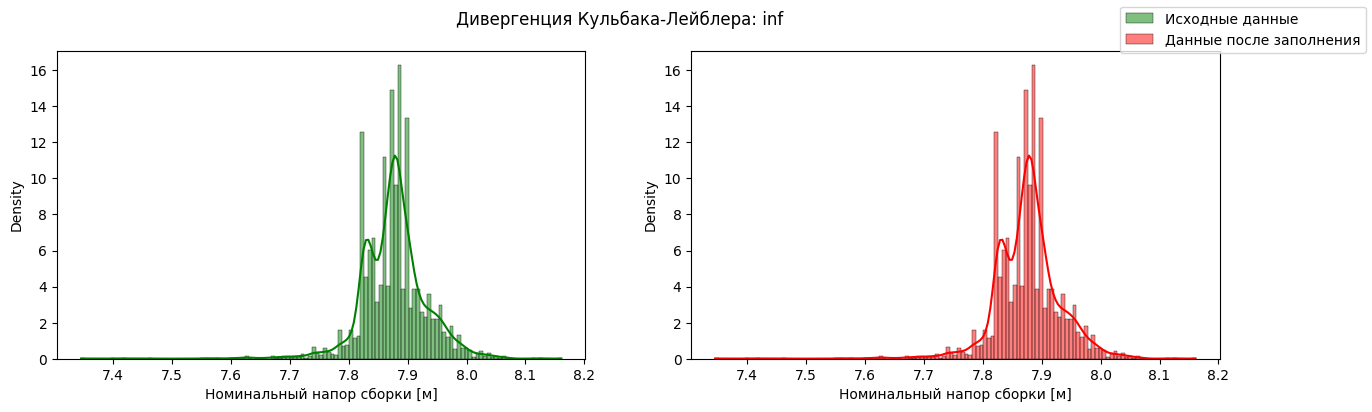

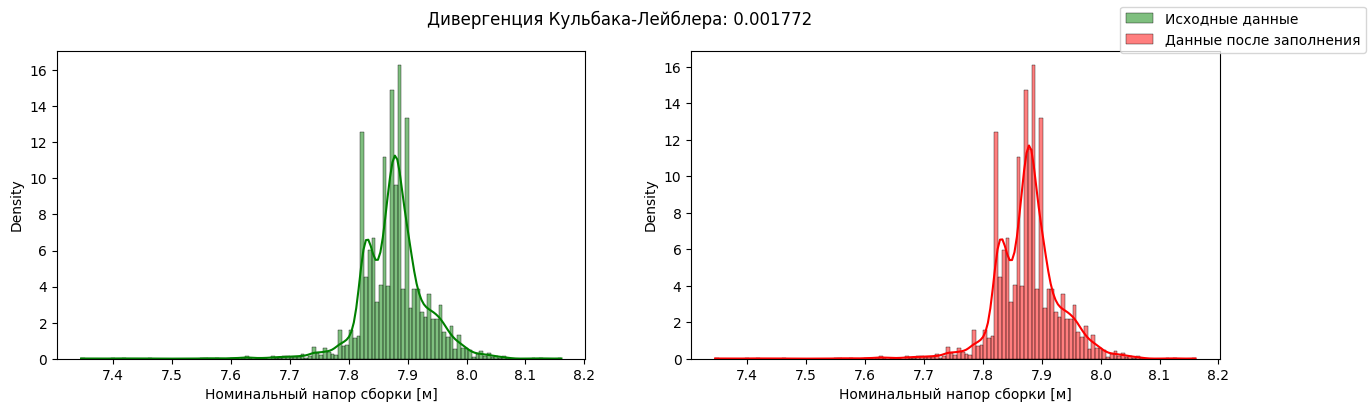

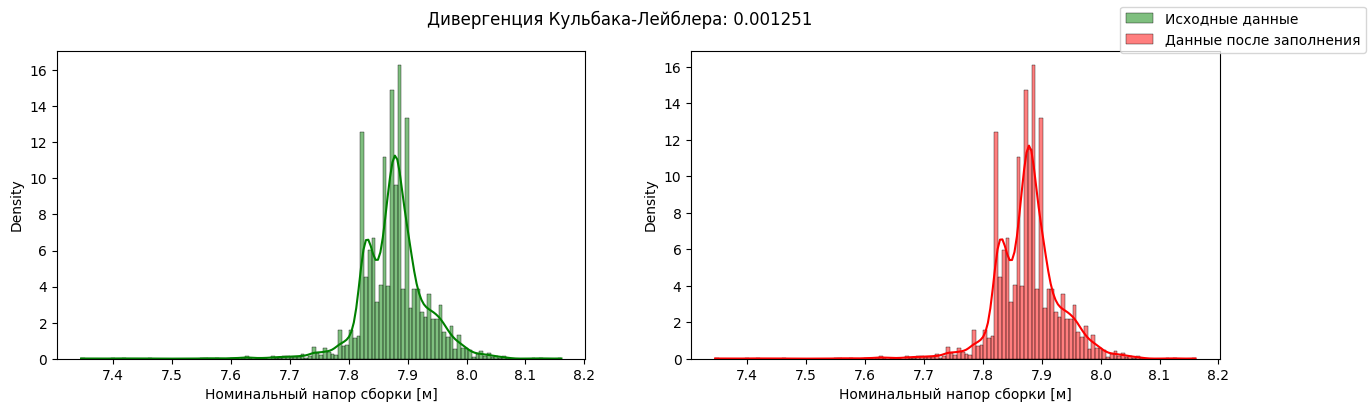

In [131]:
x_t = numeric_train[nan_columns[25]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [132]:
fillna_rule[nan_columns[25]] = x_t.median()

-----------

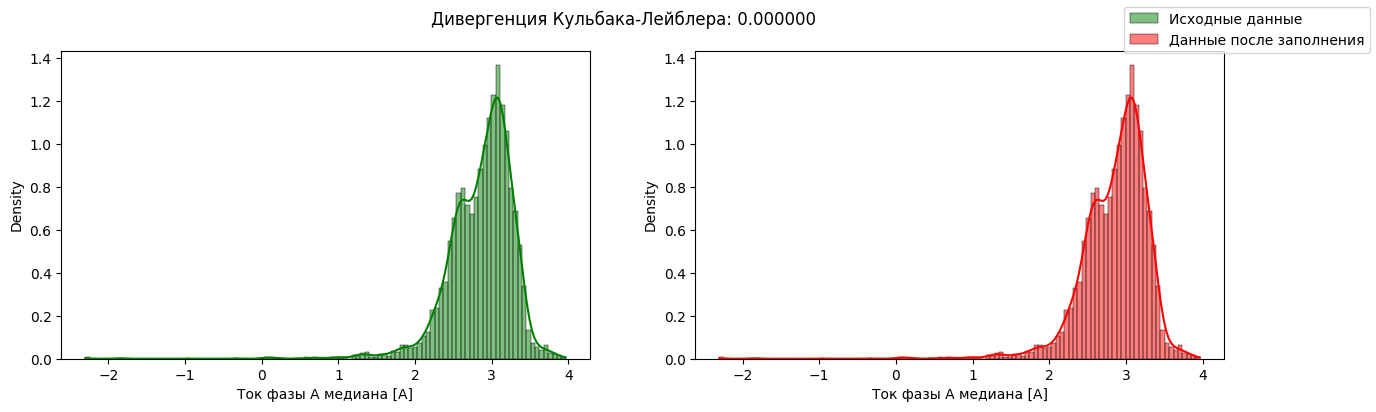

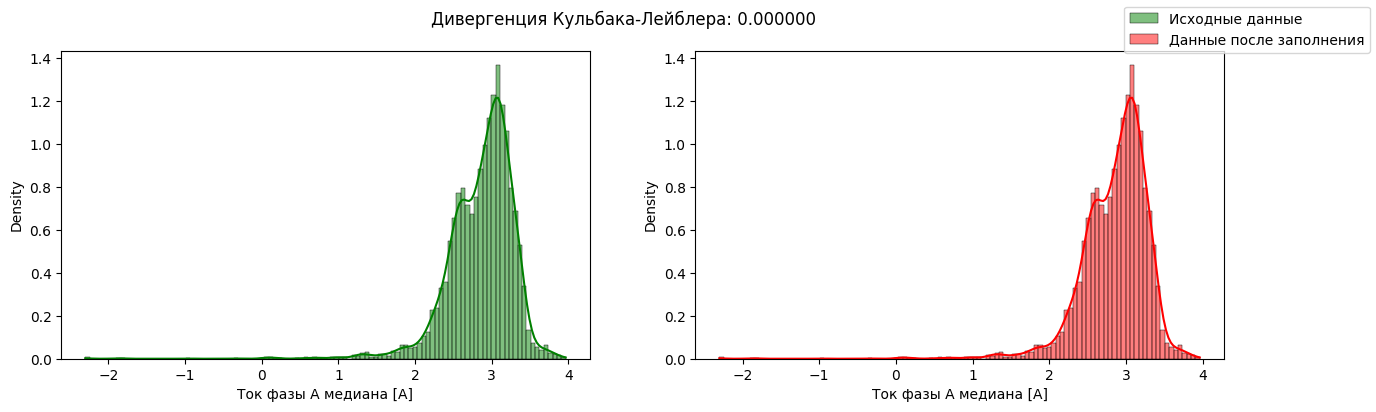

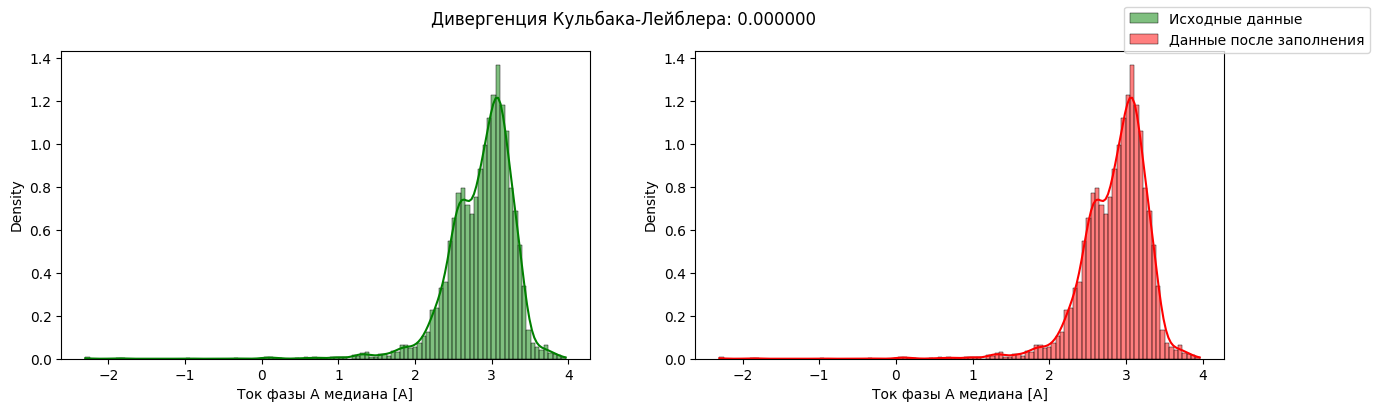

In [133]:
x_t = numeric_train[nan_columns[26]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [134]:
fillna_rule[nan_columns[26]] = x_t.median()

-----------

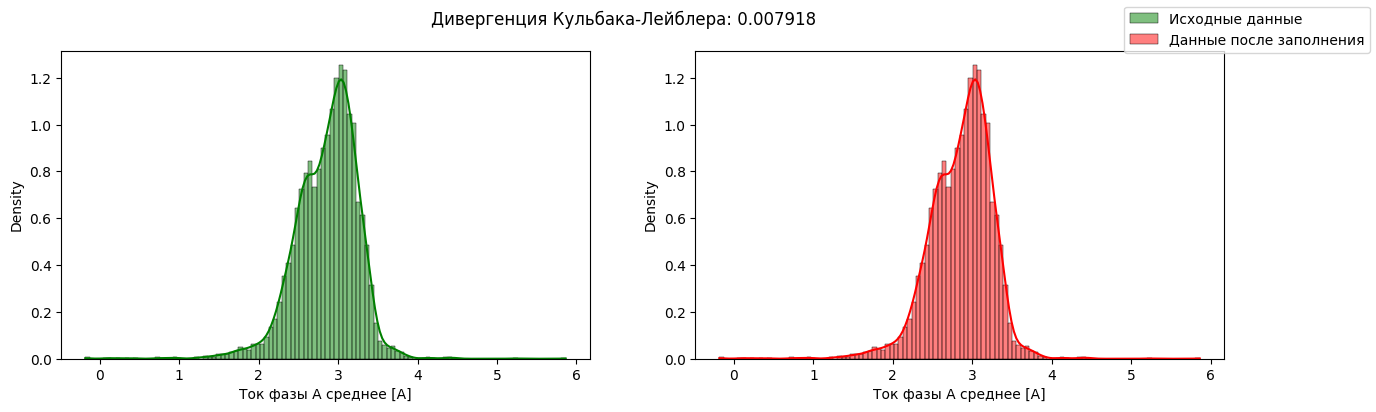

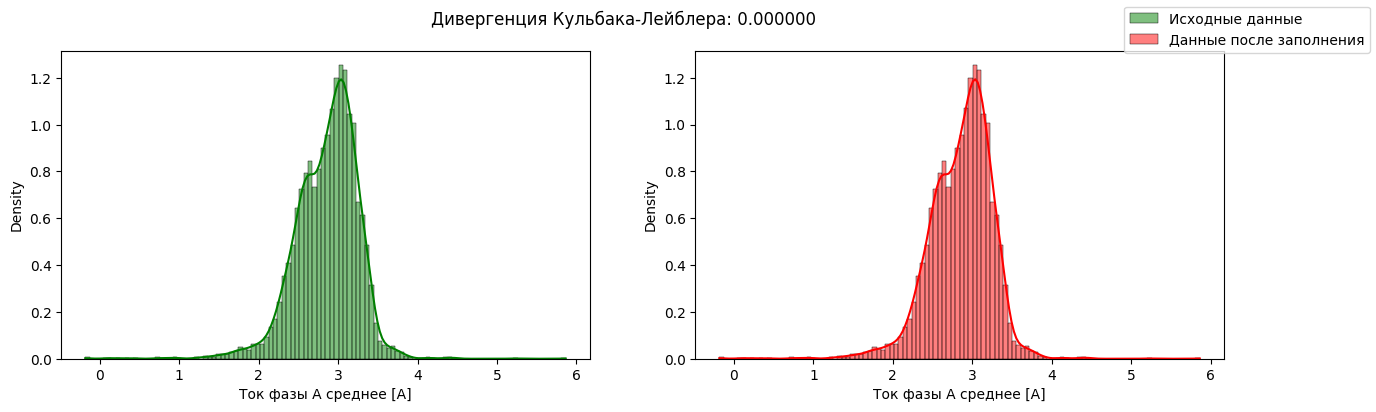

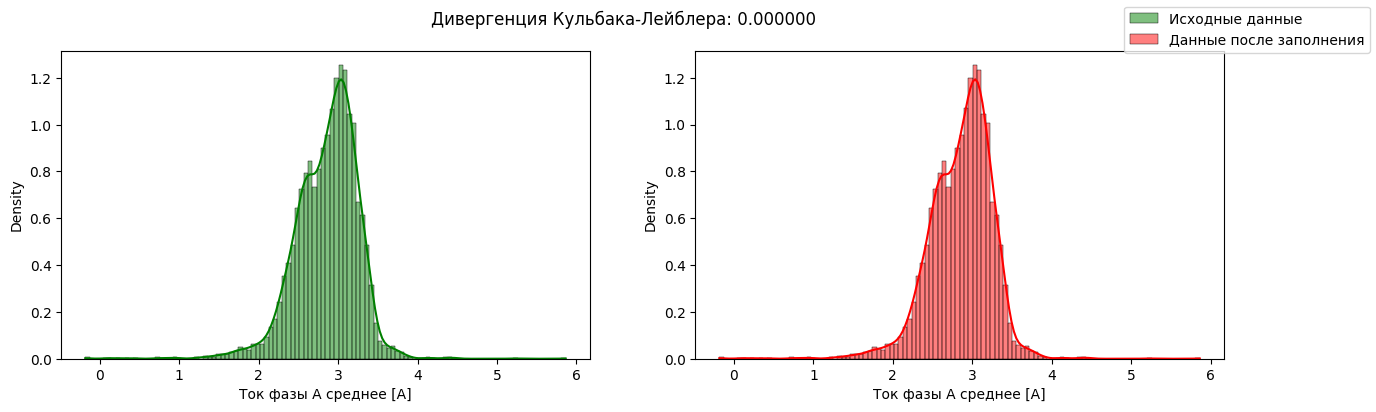

In [135]:
x_t = numeric_train[nan_columns[27]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [136]:
fillna_rule[nan_columns[27]] = x_t.median()

-----------

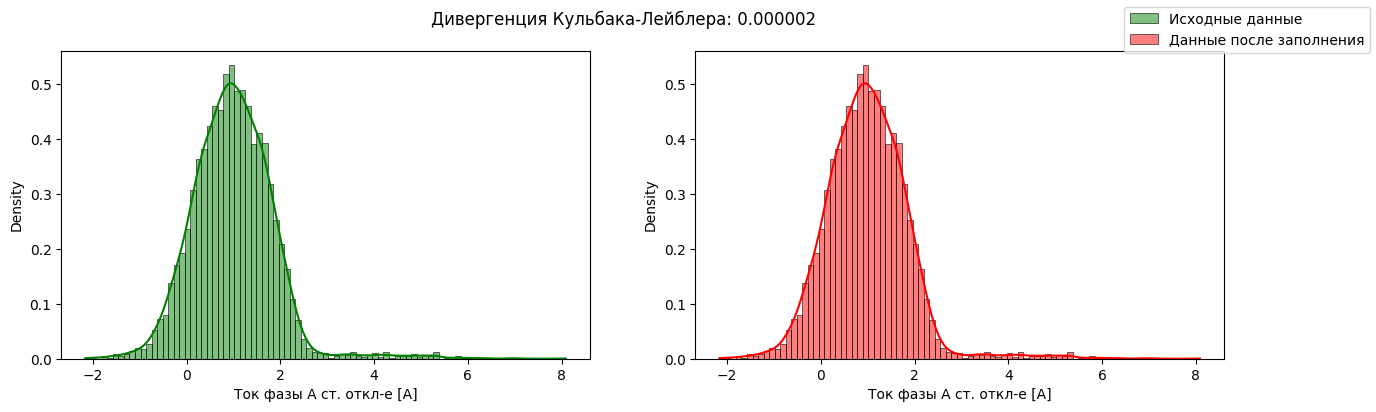

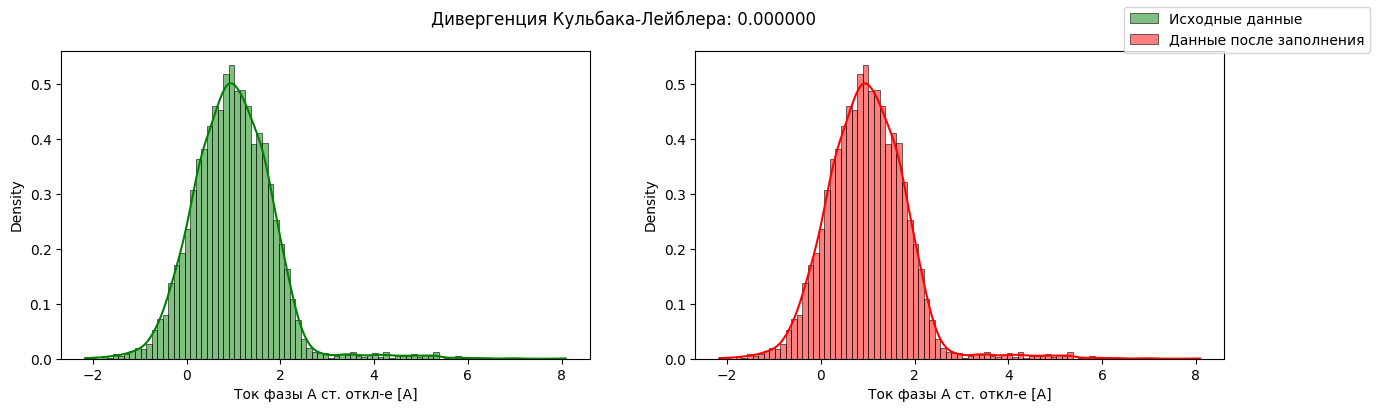

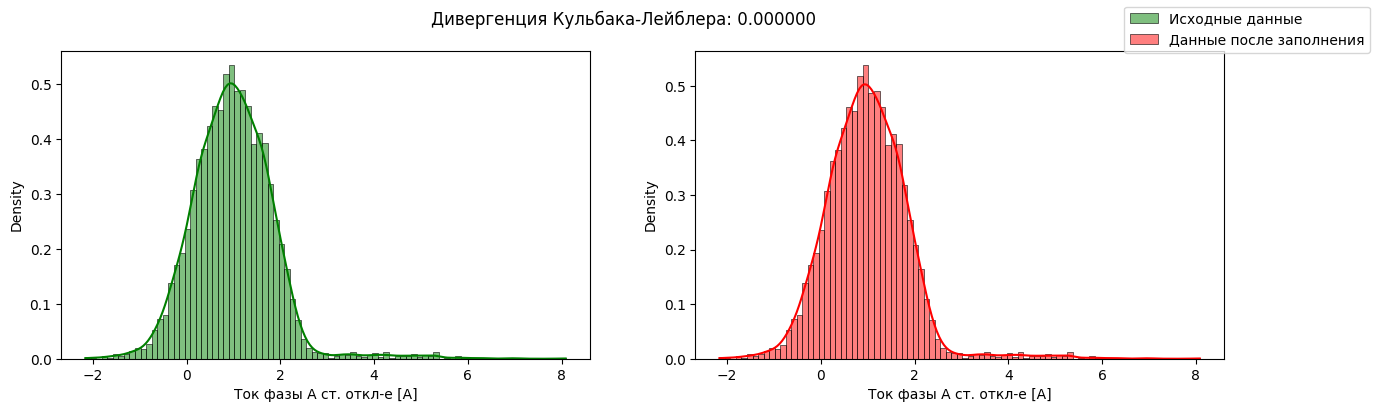

In [137]:
x_t = numeric_train[nan_columns[28]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [138]:
fillna_rule[nan_columns[28]] = x_t.median()

-----------

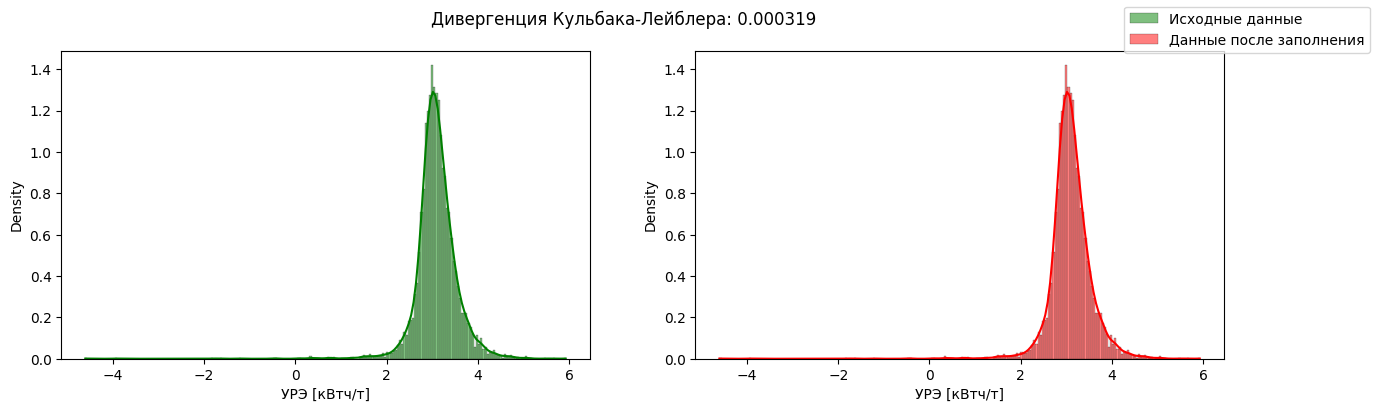

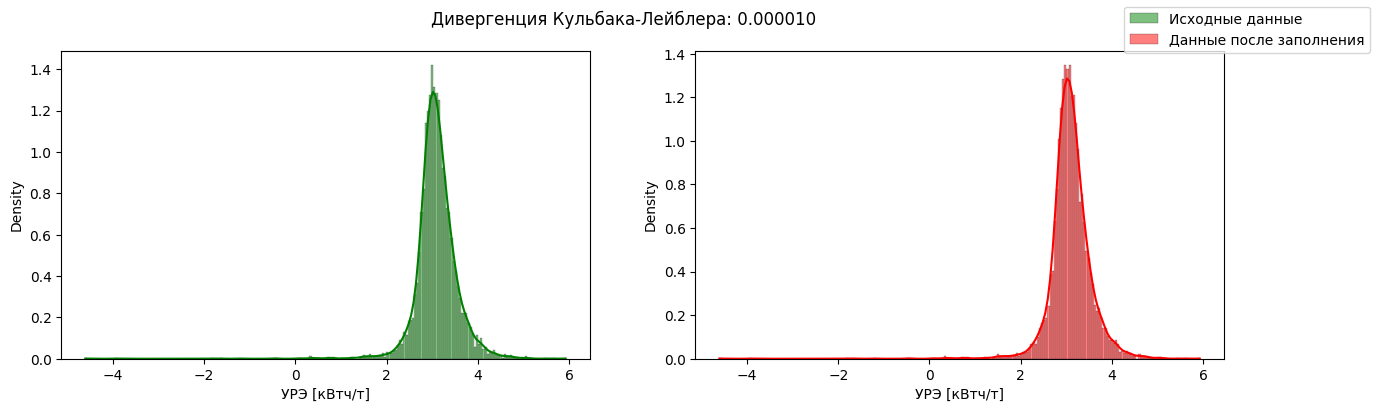

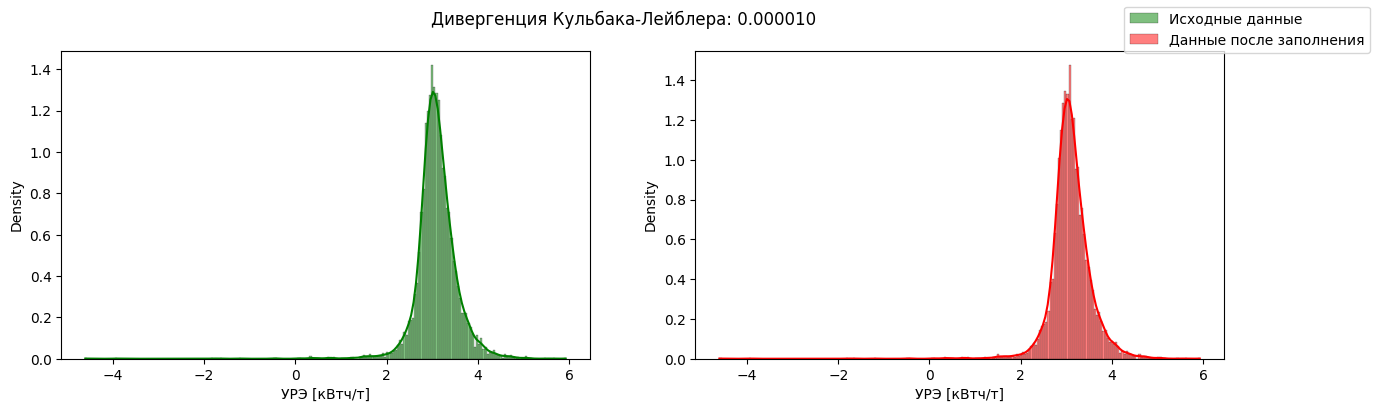

In [139]:
x_t = numeric_train[nan_columns[29]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [140]:
fillna_rule[nan_columns[29]] = x_t.median()

-----------

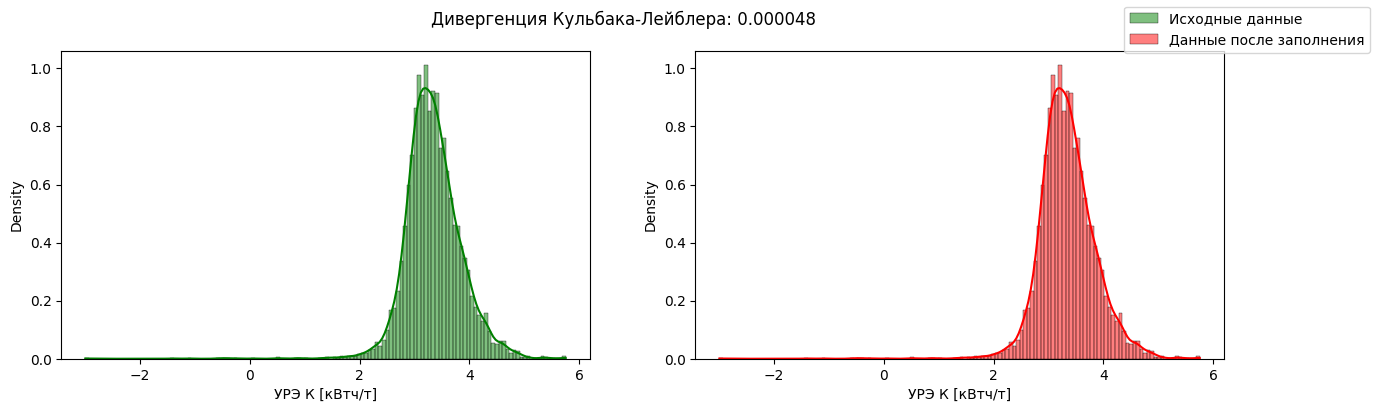

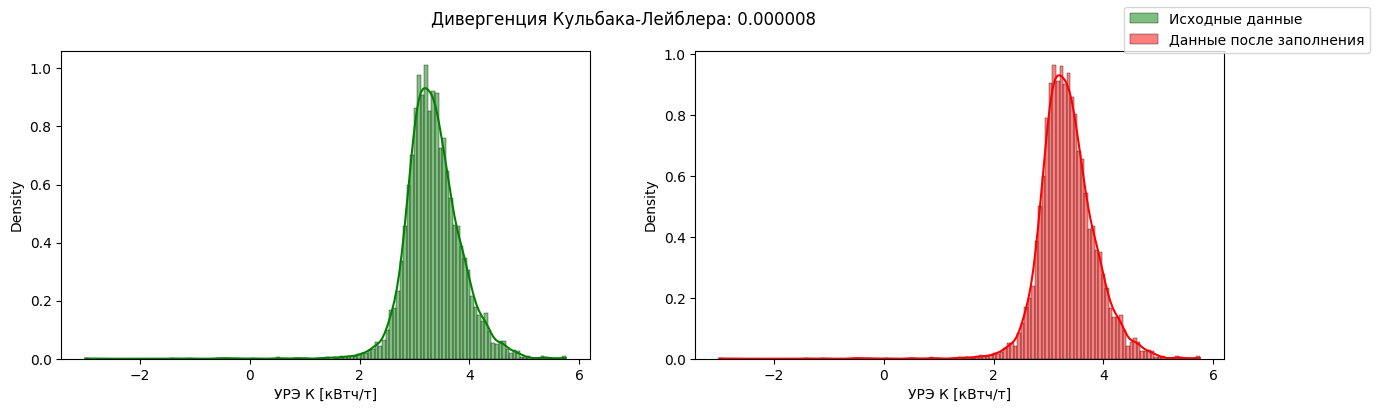

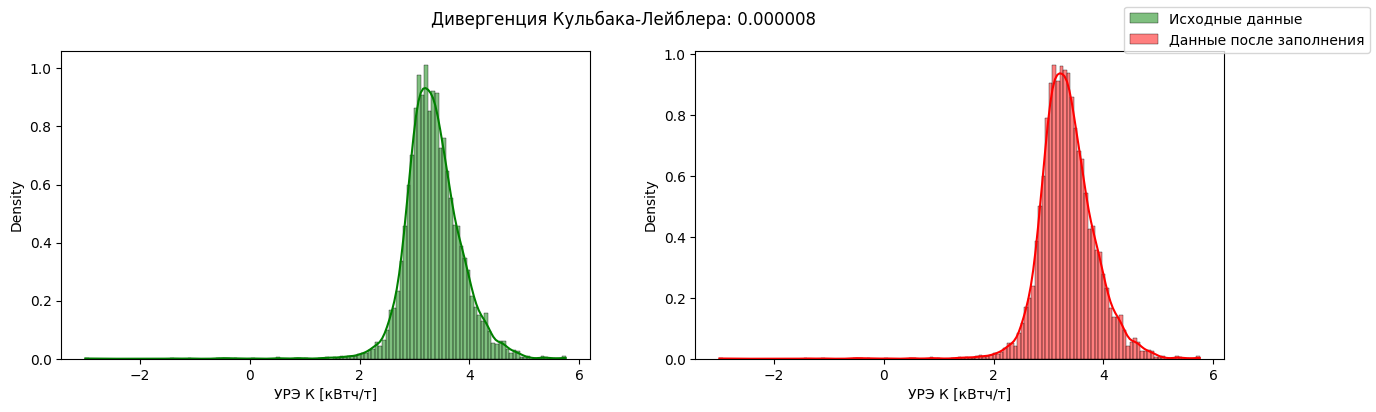

In [141]:
x_t = numeric_train[nan_columns[30]]

test_density_fillna(x_t, [
    lambda: 0,
    lambda: x_t.mean(),
    lambda: x_t.median()
])

In [142]:
fillna_rule[nan_columns[30]] = x_t.mean()

---------

Применим сформированное правило для заполнения пропусков как к элементам обучающей выборки, так и к элементам тестовой выборки.

In [143]:
numeric_train = numeric_train.fillna(value=fillna_rule)

Проверим, что по результатам работы не осталось столбцов с пропущенными значениями.

In [144]:
numeric_train.isna().sum().sum()

0

In [145]:
numeric_test = numeric_test.fillna(value=fillna_rule)

In [146]:
numeric_test.isna().sum().sum()

0

Все пропуски были заполнены.

Дополнительно сохраним столбцы с вещественными признаками.

In [147]:
numeric_columns = numeric_train.columns

### 1.1.6. <a id='toc1_1_6_'></a>[Формирование предобработанного датасета](#toc0_)

Объединим результаты предобработки вещественных и категориальных признаков в единый датасет, в котором отсутствуют пропуски и все значения являются численными.

Первоначально заменим в переменной X_train необработанные вещественные признаки на обработанные, которые были получены в результате заполнения пропусков. Необходимо также получить обучающую выборку, к которой не применялось кодирование категориальных признаков (для классических статистических моделей lifelines).

In [148]:
X_train[numeric_columns] = numeric_train[numeric_columns]

Сформируем выборку со всеми этапами кодирования признаков.

In [149]:
X_train_oh = pd.concat((
    one_hot_train.reset_index(),
    numeric_train.reset_index()
), axis=1).drop(columns=['index'])

X_train_oh

,Режим гр-ка_АПВ;ПКВ;ПДФ,Режим гр-ка_ПДФ,Режим гр-ка_ПДФ;АПВ,Режим гр-ка_ПДФ;АПВ;ПКВ,Режим гр-ка_ПДФ;ПКВ,Режим гр-ка_ПДФ;ПКВ;АПВ,Режим гр-ка_ПДФ;ПКВ;ЧЧ,Режим гр-ка_ПДФ;ПКВ;ЧЧ;АПВ,Режим гр-ка_ПДФ;ЧЧ;ПКВ,Режим гр-ка_ПКВ,...,Lнкт [м] НКТ,ЭРА.Дата монтажа_day,ЭРА.Дата монтажа_month,ЭРА.Дата монтажа_year,Дата первой работы сборки_day,Дата первой работы сборки_month,Дата первой работы сборки_year,Дата начала экспл-ии_day,Дата начала экспл-ии_month,Дата начала экспл-ии_year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3282.09,28,5,2020,29,5,2020,30,9,2019
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3125.94,2,6,2021,3,6,2021,10,4,2020
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2810.03,9,2,2022,10,2,2022,29,1,2021
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3063.19,27,11,2021,29,11,2021,27,1,2020
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2920.00,19,3,2020,20,3,2020,25,5,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2644.84,13,7,2022,14,7,2022,2,5,2022
5889,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2581.99,3,5,2022,4,5,2022,10,8,2010
5890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2869.26,27,6,2020,30,6,2020,10,3,2016
5891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3238.00,3,9,2020,4,9,2020,20,4,2019


Аналогичную работу проделаем с тестовыми данными.

In [150]:
X_test[numeric_columns] = numeric_test[numeric_columns]

In [151]:
X_test_oh = pd.concat((
    one_hot_test.reset_index(),
    numeric_test.reset_index()
), axis=1).drop(columns=['index'])

X_test_oh

,Режим гр-ка_АПВ;ПКВ;ПДФ,Режим гр-ка_ПДФ,Режим гр-ка_ПДФ;АПВ,Режим гр-ка_ПДФ;АПВ;ПКВ,Режим гр-ка_ПДФ;ПКВ,Режим гр-ка_ПДФ;ПКВ;АПВ,Режим гр-ка_ПДФ;ПКВ;ЧЧ,Режим гр-ка_ПДФ;ПКВ;ЧЧ;АПВ,Режим гр-ка_ПДФ;ЧЧ;ПКВ,Режим гр-ка_ПКВ,...,Lнкт [м] НКТ,ЭРА.Дата монтажа_day,ЭРА.Дата монтажа_month,ЭРА.Дата монтажа_year,Дата первой работы сборки_day,Дата первой работы сборки_month,Дата первой работы сборки_year,Дата начала экспл-ии_day,Дата начала экспл-ии_month,Дата начала экспл-ии_year
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3180.00,24,10,2024,26,10,2024,31,12,2023
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2862.71,27,6,2021,30,6,2021,4,4,2020
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2459.60,2,1,2023,5,1,2023,16,2,2007
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2746.81,28,7,2021,30,7,2021,3,7,2020
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2629.84,3,1,2023,4,1,2023,19,11,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3030.00,23,8,2023,25,8,2023,25,8,2023
1036,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2847.77,21,10,2020,22,10,2020,28,5,2020
1037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2940.00,9,12,2021,10,12,2021,28,5,2010
1038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2940.42,17,10,2023,18,10,2023,26,8,2019


## 1.2. <a id='toc1_2_'></a>[Production](#toc0_)

In [5]:
df_dead = pd.read_excel('./output_ds_3_dead.xlsx', parse_dates=[
    'ЭРА.Дата монтажа', 'ЭРА.Дата демонтажа', 'Дата первой работы сборки', 'Дата начала экспл-ии'])
df_live = pd.read_excel('./fixed_live_dataset.xlsx', parse_dates=[
    'ЭРА.Дата монтажа', 'ЭРА.Дата демонтажа', 'Дата первой работы сборки', 'Дата начала экспл-ии'])

In [6]:
df = pd.concat((df_dead, df_live), ignore_index=True)

In [7]:
df.drop(columns=['key_well_sborka', 'well_id', 'sborka_id', 'Скважина',
        'Сборка', 'Причины остановок новые', 'ЭРА.Дата демонтажа', 'Дней между монтажом и демонтажем'], inplace=True)
df.drop(columns=['Минуты вращения насоса', 'Кол-во циклов ПКВ/Дней в работе'], inplace=True)

col = 'ЭРА.Дата монтажа'
df[f'{col}_day'] = df[col].dt.day
df[f'{col}_month'] = df[col].dt.month
df[f'{col}_year'] = df[col].dt.year
df.drop(columns=[col], inplace=True)

col = 'Дата первой работы сборки'
df[f'{col}_day'] = df[col].dt.day
df[f'{col}_month'] = df[col].dt.month
df[f'{col}_year'] = df[col].dt.year
df.drop(columns=[col], inplace=True)

col = 'Дата начала экспл-ии'
df[f'{col}_day'] = df[col].dt.day
df[f'{col}_month'] = df[col].dt.month
df[f'{col}_year'] = df[col].dt.year
df.drop(columns=[col], inplace=True)

In [8]:
object_columns = df.select_dtypes('object').columns
df[object_columns] = df[object_columns].astype(str)

In [9]:
temp = df.isna().sum()
df_nan_pivot = temp[temp != 0]
df_nan_columns = df_nan_pivot.index

_, n_numeric_features = df.select_dtypes('number').shape
nan_distribution = df[df.isna().values.any(axis=1)][df_nan_columns].isna().sum(axis=1) / n_numeric_features
nan_row_ids = nan_distribution[nan_distribution > 0.05].index
df.drop(nan_row_ids, inplace=True)

In [10]:
from sklearn.model_selection import train_test_split


y_columns = ['Дней в работе', 'Признак отказа']

train_df, test_df = train_test_split(df, shuffle=True, stratify=df['Признак отказа'], random_state=seed, test_size=0.15)

X_train, X_test = train_df.drop(columns=y_columns), test_df.drop(columns=y_columns)
y_train, y_test = train_df[y_columns], test_df[y_columns]

In [11]:
object_columns = X_train.select_dtypes('object').columns
object_train = X_train.select_dtypes('object')
object_test = X_test.select_dtypes('object')

In [12]:
from sklearn.preprocessing import OneHotEncoder


one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

encoded_data = one_hot_encoder.fit_transform(object_train)
one_hot_train = pd.DataFrame(
    encoded_data,
    columns=one_hot_encoder.get_feature_names_out(object_columns)
)

encoded_data = one_hot_encoder.transform(object_test)
one_hot_test = pd.DataFrame(
    encoded_data,
    columns=one_hot_encoder.get_feature_names_out(object_columns)
)

In [13]:
numeric_train = X_train.select_dtypes(exclude='object')
numeric_test = X_test.select_dtypes(exclude='object')

In [14]:
temp = numeric_train.isna().sum()
nan_pivot_train = temp[temp != 0]

temp = numeric_test.isna().sum()
nan_pivot_test = temp[temp != 0]

nan_columns = np.union1d(nan_pivot_test.index, nan_pivot_train.index)

In [15]:
fillna_rule = {}

fillna_rule[nan_columns[0]] = numeric_train[nan_columns[0]].mean()
fillna_rule[nan_columns[1]] = numeric_train[nan_columns[1]].median()
fillna_rule[nan_columns[2]] = numeric_train[nan_columns[2]].mean()
fillna_rule[nan_columns[3]] = numeric_train[nan_columns[3]].mean()
fillna_rule[nan_columns[4]] = numeric_train[nan_columns[4]].median()
fillna_rule[nan_columns[5]] = numeric_train[nan_columns[5]].median()
fillna_rule[nan_columns[6]] = numeric_train[nan_columns[6]].mean()
fillna_rule[nan_columns[7]] = numeric_train[nan_columns[7]].median()
fillna_rule[nan_columns[8]] = numeric_train[nan_columns[8]].median()
fillna_rule[nan_columns[9]] = numeric_train[nan_columns[9]].median()
fillna_rule[nan_columns[10]] = numeric_train[nan_columns[10]].median()
fillna_rule[nan_columns[11]] = numeric_train[nan_columns[11]].median()
fillna_rule[nan_columns[12]] = numeric_train[nan_columns[12]].median()
fillna_rule[nan_columns[13]] = numeric_train[nan_columns[13]].median()
fillna_rule[nan_columns[14]] = numeric_train[nan_columns[14]].median()
fillna_rule[nan_columns[15]] = numeric_train[nan_columns[15]].median()
fillna_rule[nan_columns[16]] = numeric_train[nan_columns[16]].median()
fillna_rule[nan_columns[17]] = numeric_train[nan_columns[17]].median()
fillna_rule[nan_columns[18]] = numeric_train[nan_columns[18]].median()
fillna_rule[nan_columns[19]] = numeric_train[nan_columns[19]].median()
fillna_rule[nan_columns[20]] = numeric_train[nan_columns[20]].median()
fillna_rule[nan_columns[21]] = numeric_train[nan_columns[21]].median()
fillna_rule[nan_columns[22]] = numeric_train[nan_columns[22]].median()
fillna_rule[nan_columns[23]] = numeric_train[nan_columns[23]].median()
fillna_rule[nan_columns[24]] = numeric_train[nan_columns[24]].median()
fillna_rule[nan_columns[25]] = numeric_train[nan_columns[25]].median()
fillna_rule[nan_columns[26]] = numeric_train[nan_columns[26]].median()
fillna_rule[nan_columns[27]] = numeric_train[nan_columns[27]].median()
fillna_rule[nan_columns[28]] = numeric_train[nan_columns[28]].median()
fillna_rule[nan_columns[29]] = numeric_train[nan_columns[29]].median()

numeric_train = numeric_train.fillna(value=fillna_rule)
numeric_test = numeric_test.fillna(value=fillna_rule)

In [16]:
numeric_columns = numeric_train.columns

X_train[numeric_columns] = numeric_train[numeric_columns]

X_train_oh = pd.concat((
    one_hot_train.reset_index(),
    numeric_train.reset_index()
), axis=1).drop(columns=['index'])

X_test[numeric_columns] = numeric_test[numeric_columns]

X_test_oh = pd.concat((
    one_hot_test.reset_index(),
    numeric_test.reset_index()
), axis=1).drop(columns=['index'])